# Các thành viên trong nhóm:
| # | Họ và tên | MSHV | Phân công |
| --- | --- | --- | --- |
| 1 | Viên Huy Lương | CH11023004 | Mục 1, 2, 4 , 5|
| 2 | Nguyễn Phước Lợi | CH11023003 | Mục 3, 5, 6 |

## 0. Môi trường Google Colab



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cài thư viện cần cho toàn notebook
%pip install -q \
    pandas numpy scipy scikit-learn scikit-image \
    matplotlib seaborn pillow tqdm \
    torchsummary


In [3]:
from pathlib import Path

import torch

try:
    from google.colab import drive
except ImportError:
    drive = None

# === Chỉnh đúng folder bạn đã upload trên Drive ===
DRIVE_PROJECT = Path("/content/drive/MyDrive/TL_OvarianTumor_Ultrasound")

if drive is not None:
    drive.mount("/content/drive", force_remount=False)
else:
    print("Không phải runtime Colab — coi DRIVE_PROJECT là thư mục hiện tại.")
    DRIVE_PROJECT = Path(".").resolve()

DATA_ROOT = DRIVE_PROJECT / "dataset" / "MMOTU"
OUTPUT_DIR = DRIVE_PROJECT / "outputs"
CACHE_DIR = DRIVE_PROJECT / "cache"
RUNS_DIR = DRIVE_PROJECT / "runs"

for _d in (OUTPUT_DIR, CACHE_DIR, RUNS_DIR):
    _d.mkdir(parents=True, exist_ok=True)

_otu = DATA_ROOT / "OTU_2d" / "images"
if not _otu.exists():
    raise FileNotFoundError(
        f"Không thấy {_otu}.\n"
        f"Hãy upload MMOTU lên Drive: {DRIVE_PROJECT}/dataset/MMOTU/OTU_2d/ ..."
    )

print("PyTorch:", torch.__version__)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: chưa bật — Runtime → Change runtime type → T4")

print("DRIVE_PROJECT:", DRIVE_PROJECT)
print("DATA_ROOT:", DATA_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("OTU_2d:", sorted(p.name for p in (DATA_ROOT / "OTU_2d").iterdir()))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch: 2.11.0+cu128
GPU: Tesla T4
DRIVE_PROJECT: /content/drive/MyDrive/TL_OvarianTumor_Ultrasound
DATA_ROOT: /content/drive/MyDrive/TL_OvarianTumor_Ultrasound/dataset/MMOTU
OUTPUT_DIR: /content/drive/MyDrive/TL_OvarianTumor_Ultrasound/outputs
OTU_2d: ['annotations', 'images', 'train.txt', 'train_cls.txt', 'val.txt', 'val_cls.txt']


# 1. Giới thiệu

## Bài toán

U buồng trứng là bệnh lý phụ khoa thường gặp. Siêu âm là phương tiện sàng lọc đầu tay, nhưng việc phân loại loại u (nang sô-cô-la, teratoma, cystadenoma, u ác tính, …) phụ thuộc nhiều vào kinh nghiệm người đọc và dễ nhầm giữa các lớp có hình thái gần nhau.

Bài toán đặt ra trên tập **MMOTU** (Multi-Modality Ovarian Tumor Ultrasound): hỗ trợ nhận diện loại u trên ảnh siêu âm 2D, cụ thể là phân loại 8 loại bệnh lý u buồng trứng.

## Tài liệu tham khảo
Zhao et al. - 2023 - MMOTU A Multi-Modality Ovarian Tumor Ultrasound Image Dataset for Unsupervised Cross-Domain Semanti

## Phạm vi

Đồ án **chỉ phân tích và huấn luyện trên tập OTU_2d** (siêu âm 2D, 1469 ảnh, 8 lớp). Tập OTU_3d (CEUS) **không** đưa vào EDA, tiền xử lý, huấn luyện và đánh giá

## Mục tiêu

- Hiểu cấu trúc, chất lượng và mất cân bằng của dữ liệu **OTU_2d** trước khi huấn luyện.
- **Huấn luyện ResNet-50 theo giao thức Task 3 (Single-Modality Recognition) của MMOTU.**
- Đánh giá bằng đúng bộ độ đo của bài báo (top-1, top-2 accuracy, ROC, confusion matrix), thêm macro-F1 để nhìn các lớp hiếm.
- Chỉ ra lớp nào dễ nhầm, hạn chế của mô hình và hướng cải thiện.
- Tái tạo thực nghiệm mô hình Resnet-50 của bài báo tham khảo

## Giao thức huấn luyện

| Hạng mục | Giá trị | Áp dụng ở mục |
| --- | --- | --- |
| Chia tập | 1000 ảnh train (171 BN) / 469 ảnh test (76 BN), patient-disjoint, không có tập val | 3.1 |
| Tiền xử lý | Ảnh raw, random resize + crop 384×384, RandomFlip. Không can thiệp làm lệch phân bố dữ liệu | 3.3, 5.1 |
| Mask ROI | Không dùng — Task 3 chỉ dùng nhãn global-wise | 2.4, 3.5 |
| Tối ưu | SGD, momentum 0.9, weight decay 0.0005, LR 0.01, poly decay power 0.9, khởi tạo ImageNet | 4.4, 5.2 |
| Mô hình | ResNet-50 | 4.3 |
| Metric | top-1 và top-2 accuracy, ROC, confusion matrix | 5.4 |

## Bộ dữ liệu đã chọn

**MMOTU** — Zhao et al., gồm hai subset:

| Subset | Mô tả | Số ảnh | Số lớp |
| --- | --- | --- | --- |
| OTU_2d | Siêu âm 2D | 1469 | 8 |
| OTU_3d | Contrast-enhanced ultrasound | 170 | 7 (không có Normal ovary) |

Tuy nhiên trong đồ án này thì nhóm em chỉ chọn subset OTU_2d để huấn luyện mô hình

Tám lớp trên OTU_2d:

| ID | Tên lớp | Tên bệnh lý | Phân loại | 
| --- | --- | --- | --- |
| 0 | Chocolate cyst | U nang lạc nội mạc tử cung | Lành tính |
| 1 | Serous cystadenoma | U nang tuyến thanh dịch | Lành tính |
| 2 | Teratoma | U quái (U bì) trưởng thành | Lành tính |
| 3 | Theca cell tumor | U tế bào vỏ buồng trứng | Lành tính |
| 4 | Simple cyst | Nang đơn giản (Nang cơ năng) | Lành tính |
| 5 | Normal ovary | Buồng trứng bình thường | Không phải bệnh lý |
| 6 | Mucinous cystadenoma | U nang tuyến nhầy | Lành tính |
| 7 | High grade serous | Ung thư biểu mô thanh dịch độ cao | Ác tính |

Mỗi mẫu có ảnh `*.JPG`, nhãn lớp trong `train_cls.txt` / `val_cls.txt`, và mask pixel-wise (`*.PNG`, `*_binary.PNG`). Split train/val có sẵn.


# 2. Phân tích dữ liệu (EDA) tập OTU_2d (MMOTU)

+ Việc phân tích dữ liệu để phát hiện và xử lý dữ liệu bị thiếu, phát hiện dữ liệu outlier, định dạng dữ liệu, rút trích và lựa chọn đặc trưng tốt để huấn luyện mô hình, ngoài ra việc phân tích dữ liệu giúp hiểu được phân phối dữ liệu, phát hiện việc mất cân bằng các lớp, chuẩn hóa dữ liệu. Toàn bộ EDA dưới đây chỉ thực hiện trên **OTU_2d**.

**2. Phân tích dữ liệu**
- 2.1 Kiểm tra folder và định dạng dữ liệu
- 2.2 Đọc nhãn và thống kê class
- 2.3 Kiểm tra kích thước ảnh và xem mẫu
- 2.4 Metadata: tên lớp và đường dẫn mask
- 2.5 Phân tích chất lượng ảnh
- 2.6 Phân tích annotation
- 2.7 Phân tích intensity distribution
- 2.8 Phân tích texture features
- 2.9 Phân tích tương quan giữa các lớp
- 2.10 Phân tích outlier
- 2.11 Phân tích missing data
- 2.12 Lưu CSV

> **Lưu ý về mask.** Mục 2.6–2.8 phân tích GT mask chỉ để EDA. Mô hình ResNet-50 ở mục 5 không dùng mask.


## 2.1 Kiểm tra folder và định dạng dữ liệu


In [4]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

if "DATA_ROOT" not in globals():
    raise RuntimeError("Chạy mục 0 (mount Drive) trước khi vào mục 2.")
SUBSET_NAME = "OTU_2d"
subset = DATA_ROOT / SUBSET_NAME
print("DATA_ROOT:", DATA_ROOT)
print("Subset dùng để phân tích và huấn luyện:", SUBSET_NAME)

print(f"\n=== {subset.name} ===")
for fname in ["train.txt", "val.txt", "train_cls.txt", "val_cls.txt", "trainval.txt"]:
    f = subset / fname
    if f.exists():
        with open(f, "r", encoding="utf-8") as fh:
            lines = [line.strip() for line in fh if line.strip()]
        print(f"{fname}: {len(lines)} dòng")
        print("Ví dụ:", lines[:3])
img_dir = subset / "images"
if img_dir.exists():
    imgs = sorted(img_dir.iterdir())
    print(f"images folder: {len(imgs)} file")
    print("Mẫu ảnh:", [img.name for img in imgs[:5]])


DATA_ROOT: /content/drive/MyDrive/TL_OvarianTumor_Ultrasound/dataset/MMOTU
Subset dùng để phân tích và huấn luyện: OTU_2d

=== OTU_2d ===
train.txt: 1000 dòng
Ví dụ: ['658', '384', '367']
val.txt: 469 dòng
Ví dụ: ['1269', '1458', '700']
train_cls.txt: 1000 dòng
Ví dụ: ['658.JPG  5', '384.JPG  3', '367.JPG  3']
val_cls.txt: 469 dòng
Ví dụ: ['1269.JPG  5', '1458.JPG  7', '700.JPG  6']
images folder: 1469 file
Mẫu ảnh: ['1.JPG', '10.JPG', '100.JPG', '1000.JPG', '1001.JPG']


## 2.2 Đọc file nhãn và xây dựng DataFrame

Cấu trúc nhãn có dạng:
`<tên_ảnh.jpg> <class_id>`

Ví dụ:
`658.JPG  5`


In [5]:
def read_label_file(label_path: Path):
    rows = []
    if not label_path.exists():
        return pd.DataFrame(rows)

    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) >= 2:
                img_name = parts[0]
                label = int(parts[1])
                rows.append({
                    "image_name": img_name,
                    "label": label
                })
    return pd.DataFrame(rows)

sample_df = read_label_file(DATA_ROOT / SUBSET_NAME / "train_cls.txt")
print(f"{SUBSET_NAME} - train_cls.txt:", len(sample_df), "dòng")
print(sample_df.head())


OTU_2d - train_cls.txt: 1000 dòng
  image_name  label
0    658.JPG      5
1    384.JPG      3
2    367.JPG      3
3    730.JPG      1
4   1426.JPG      7


In [6]:
all_rows = []
subset = DATA_ROOT / SUBSET_NAME
img_dir = subset / "images"

for split in ["train", "val"]:
    label_file = subset / f"{split}_cls.txt"
    if not label_file.exists():
        continue

    df_split = read_label_file(label_file).copy()
    df_split["subset"] = SUBSET_NAME
    df_split["split"] = split
    df_split["image_path"] = df_split["image_name"].apply(lambda x: str(img_dir / x))
    all_rows.append(df_split)

df = pd.concat(all_rows, ignore_index=True)
print("Tổng số sample (OTU_2d):", len(df))
print(df.head())


Tổng số sample (OTU_2d): 1469
  image_name  label  subset  split  \
0    658.JPG      5  OTU_2d  train   
1    384.JPG      3  OTU_2d  train   
2    367.JPG      3  OTU_2d  train   
3    730.JPG      1  OTU_2d  train   
4   1426.JPG      7  OTU_2d  train   

                                          image_path  
0  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...  
1  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...  
2  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...  
3  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...  
4  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...  


    split  label  count
0   train      0    226
1   train      1    153
2   train      2    228
3   train      3     57
4   train      4     47
5   train      5    180
6   train      6     71
7   train      7     38
8     val      0    110
9     val      1     66
10    val      2    108
11    val      3     31
12    val      4     19
13    val      5     87
14    val      6     33
15    val      7     15

Tổng số sample theo split:
split
train    1000
val       469
dtype: int64


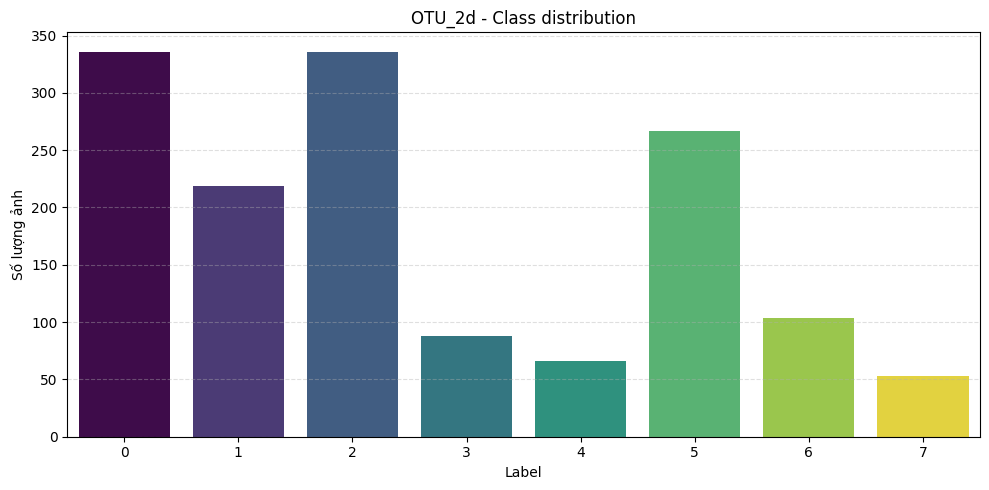

In [7]:
df["label_name"] = df["label"].map(lambda x: f"Class {x}")

summary = (
    df.groupby(["split", "label"])
      .size()
      .reset_index(name="count")
      .sort_values(["split", "label"])
)

print(summary)
print("\nTổng số sample theo split:")
print(df.groupby("split").size())

plt.figure(figsize=(10, 5))
counts = df.groupby("label").size().sort_index()
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="viridis", legend=False)
plt.title("OTU_2d - Class distribution")
plt.xlabel("Label")
plt.ylabel("Số lượng ảnh")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


### Nhận xét

- Phân bố nhãn OTU_2d lệch rõ: lớp 0, 1, 2, 5 chiếm phần lớn; lớp 3, 4, 6, 7 ít hơn hẳn.
- Đây cũng là nhóm lớp có accuracy thấp hơn.
- Bài báo **không** cân bằng lớp, coi đây là đặc tính của dataset.

**Kết luận:** Giữ nguyên phân bố lớp khi huấn luyện (không sampler, không class weight); mức lệch đã ghi ở mục 2.2 và dùng để giải thích kết quả theo lớp ở mục 5.4.


In [8]:
print("=== OTU_2d ===")
print(df["label"].value_counts().sort_index())
print("Total:", len(df))


=== OTU_2d ===
label
0    336
1    219
2    336
3     88
4     66
5    267
6    104
7     53
Name: count, dtype: int64
Total: 1469


## 2.3 Kiểm tra kích thước ảnh và xem mẫu

Bước này giúp biết ảnh có đồng nhất kích thước hay không, và quan sát trực quan dữ liệu trước khi train.


In [9]:
def get_image_size(path: str):
    try:
        with Image.open(path) as img:
            return img.size[0], img.size[1]
    except Exception:
        return None, None

size_rows = []
for _, row in df.iterrows():
    w, h = get_image_size(row["image_path"])
    if w is not None and h is not None:
        size_rows.append({
            "subset": row["subset"],
            "split": row["split"],
            "label": row["label"],
            "image_name": row["image_name"],
            "width": w,
            "height": h
        })

size_df = pd.DataFrame(size_rows)
print(size_df.head())
print("\nThông tin kích thước ảnh:")
print(size_df.groupby("split").agg({
    "width": ["min", "max", "mean"],
    "height": ["min", "max", "mean"]
}))


   subset  split  label image_name  width  height
0  OTU_2d  train      5    658.JPG    480     559
1  OTU_2d  train      3    384.JPG    554     589
2  OTU_2d  train      3    367.JPG    958     534
3  OTU_2d  train      1    730.JPG    973     547
4  OTU_2d  train      7   1426.JPG    958     535

Thông tin kích thước ảnh:
      width                   height                 
        min   max        mean    min  max        mean
split                                                
train   302  1135  760.574000    270  794  551.899000
val     407  1135  765.179104    266  794  548.586354


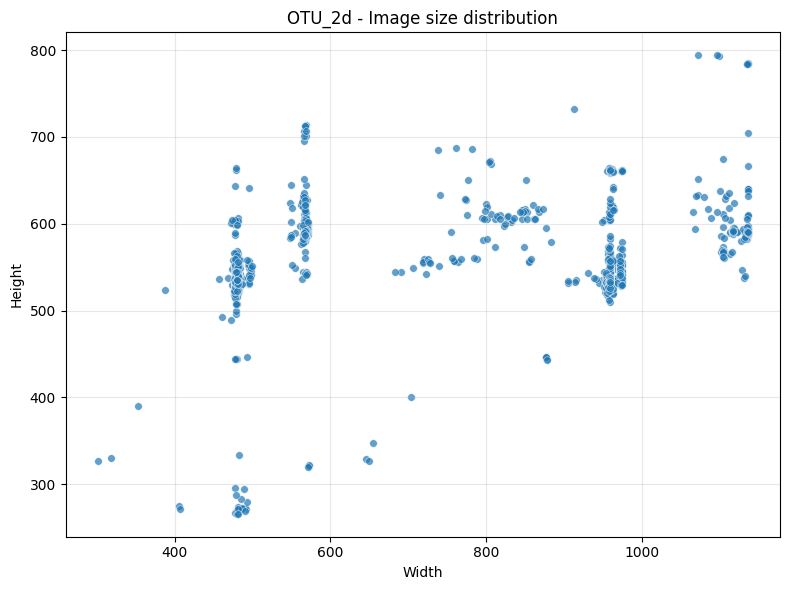

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=size_df, x="width", y="height", s=30, alpha=0.7)
plt.title("OTU_2d - Image size distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Nhận xét

- Kích thước ảnh không đồng nhất, tập trung ở hai cụm: khoảng 400–600 × 500–700 và 900–1000 × 500–700.
- Hai cụm phản ánh hai loại máy siêu âm khác nhau, nên `img_h` / `img_w` là tín hiệu thiết bị chứ không phải tín hiệu bệnh lý.
- Ảnh gốc giữ nguyên kích thước; lúc train mới random resize (giữ tỉ lệ) rồi crop 384×384.

**Kết luận:** Mục 3.2–5.1 làm **random resize giữ tỉ lệ + crop 384×384** (không resize cứng 448, không pad vuông), và loại `img_h`, `img_w`, `n_pixels` khỏi tập đặc trưng ở mục 3.4 để mô hình không học tắt theo thiết bị.


Index(['image_name', 'label', 'subset', 'split', 'image_path', 'label_name'], dtype='object')
  image_name  label  subset  split  \
0    454.JPG      0  OTU_2d  train   
1   1178.JPG      5  OTU_2d  train   
2    272.JPG      2  OTU_2d  train   
3    131.JPG      1  OTU_2d  train   
4      6.JPG      0  OTU_2d  train   

                                          image_path label_name  
0  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...    Class 0  
1  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...    Class 5  
2  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...    Class 2  
3  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...    Class 1  
4  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...    Class 0  


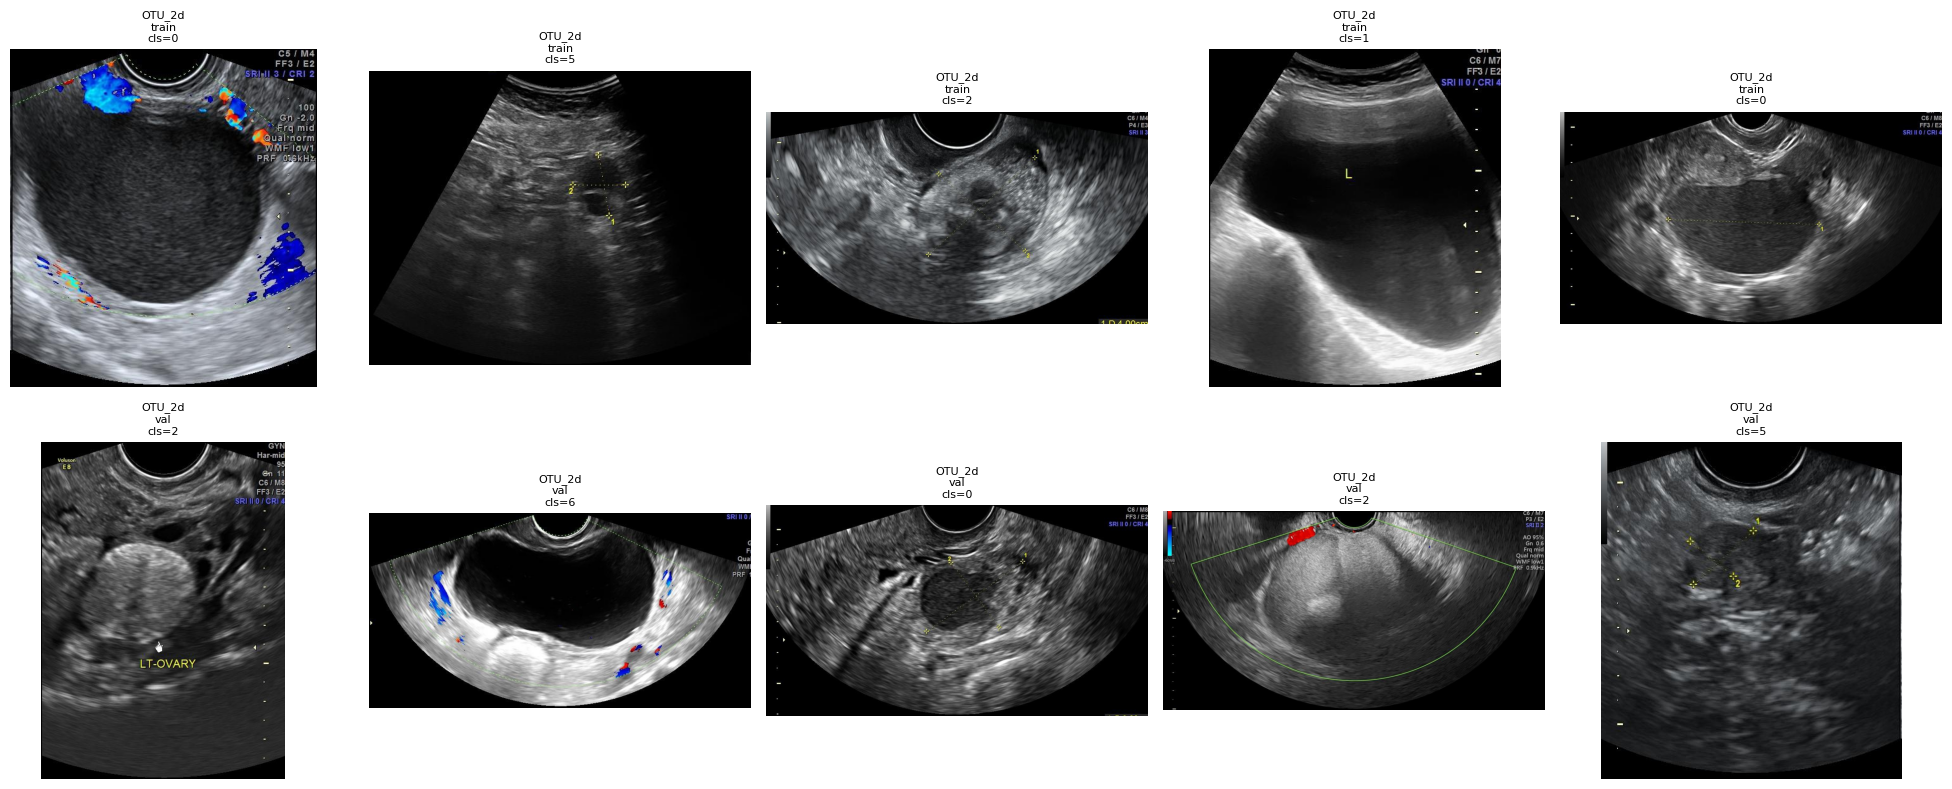

In [11]:
sample_frames = []
for subset_name, subset_df in df.groupby("subset"):
    for split_name, split_df in subset_df.groupby("split"):
        sample = split_df.sample(n=min(5, len(split_df)), random_state=42)
        sample_frames.append(sample)

sample_images_df = pd.concat(sample_frames, ignore_index=True)
print(sample_images_df.columns)
print(sample_images_df.head())

grouped = list(sample_images_df.groupby(["subset", "split"]))
row_count = len(grouped)
fig, axes = plt.subplots(row_count, 5, figsize=(20, 4 * max(1, row_count)))
if row_count == 1:
    axes = axes.reshape(1, -1)

for row_idx, ((subset_name, split_name), subset_group) in enumerate(grouped):
    subset_group = subset_group.reset_index(drop=True)
    for col_idx, (_, row) in enumerate(subset_group.iterrows()):
        ax = axes[row_idx, col_idx]
        try:
            img = Image.open(row["image_path"])
            if img.mode in ["L", "1"]:
                ax.imshow(img, cmap="gray")
            else:
                ax.imshow(img)
        except Exception:
            ax.imshow(
                __import__("numpy").zeros((64, 64), dtype=__import__("numpy").uint8),
                cmap="gray",
            )
        ax.set_title(f"{subset_name}\n{split_name}\ncls={row['label']}", fontsize=8)
        ax.axis("off")

# Xóa các ô còn trống nếu có
if row_count > 0:
    for ax in axes.flat[row_count * 5:]:
        ax.axis("off")

plt.tight_layout()
plt.show()

## 2.4 Metadata: tên lớp và đường dẫn mask

MMOTU gồm 8 lớp u buồng trứng. Ảnh `*.JPG` tương ứng mask `*.PNG` (màu) và `*_binary.PNG` (nhị phân 0/1).
Phần phân tích hình học dùng mask nhị phân.

> **Mask.** EDA 2.6–2.8 dùng mask. Mô hình ResNet-50 ở mục 5 không dùng mask.


In [12]:
CLASS_NAMES = {
    0: "Chocolate cyst",
    1: "Serous cystadenoma",
    2: "Teratoma",
    3: "Theca cell tumor",
    4: "Simple cyst",
    5: "Normal ovary",
    6: "Mucinous cystadenoma",
    7: "High grade serous",
}

def resolve_mask_path(image_path: str):
    img_path = Path(image_path)
    ann_dir = img_path.parent.parent / "annotations"
    stem = img_path.stem
    binary_mask = ann_dir / f"{stem}_binary.PNG"
    color_mask = ann_dir / f"{stem}.PNG"
    if binary_mask.exists():
        return str(binary_mask), str(color_mask) if color_mask.exists() else None, True
    if color_mask.exists():
        return str(color_mask), str(color_mask), True
    return None, str(color_mask) if color_mask.exists() else None, False

mask_info = df["image_path"].apply(resolve_mask_path)
df["mask_path"] = [x[0] for x in mask_info]
df["color_mask_path"] = [x[1] for x in mask_info]
df["has_mask"] = [x[2] for x in mask_info]
df["class_name"] = df["label"].map(CLASS_NAMES)
df["label_name"] = df["label"].map(lambda x: f"{x}: {CLASS_NAMES.get(x, 'Unknown')}")

print("Số ảnh có mask:", int(df["has_mask"].sum()), "/", len(df))
print("Số ảnh thiếu mask:", int((~df["has_mask"]).sum()))
print("\nMapping lớp:")
for k, v in CLASS_NAMES.items():
    n = int((df["label"] == k).sum())
    print(f"  {k}: {v:24s}  n={n}")


Số ảnh có mask: 1469 / 1469
Số ảnh thiếu mask: 0

Mapping lớp:
  0: Chocolate cyst            n=336
  1: Serous cystadenoma        n=219
  2: Teratoma                  n=336
  3: Theca cell tumor          n=88
  4: Simple cyst               n=66
  5: Normal ovary              n=267
  6: Mucinous cystadenoma      n=104
  7: High grade serous         n=53


### Nhận xét

- Toàn bộ 1469 ảnh OTU_2d đều có mask nhị phân đi kèm, không ảnh nào thiếu.
- Mask là nhãn pixel-wise, phục vụ Task 1 (segmentation) và Task 2 (domain adaptation) của bài báo.
- Task 3 mà notebook này làm chỉ dùng **nhãn global-wise** (một số nguyên 0–7 cho cả ảnh).

**Kết luận:** Mask chỉ phục vụ EDA 2.6–2.8. Mô hình ResNet-50 **không** dùng mask.


## 2.5 Phân tích chất lượng ảnh

- **Độ tương phản (Contrast)**: Đo chênh lệch sáng/tối (RMS, Michelson). Việc so sánh trước/sau *histogram equalization* giúp kiểm tra xem thuật toán có thực sự làm nổi bật đặc trưng quan trọng (viền cạnh, khối u...) để mô hình AI dễ học hơn hay không.

- **Độ sáng (Brightness)**: `mean` (độ sáng trung bình) và `std` (độ lệch chuẩn phân bố ánh sáng). Dùng để phát hiện ảnh quá tối/sáng bị mất thông tin, từ đó chuẩn hóa (normalize) giúp mô hình nhận diện ổn định trong mọi điều kiện chiếu sáng.

- **Mức nhiễu (Noise level)**: `SNR = mean / std` (và dB). SNR thấp nghĩa là nhiễu nhiều, dễ che lấp chi tiết nhỏ. Chỉ số này dùng để đánh giá chất lượng ảnh và quyết định có cần áp dụng bộ lọc khử nhiễu (denoising) trước khi huấn luyện hay không.

- **Độ sắc nét (Sharpness)**: Trung bình gradient magnitude (`np.gradient`). Gradient thấp đồng nghĩa với ảnh bị mờ (blur). Chỉ số này dùng để tự động lọc bỏ các ảnh không đạt chuẩn ra khỏi tập dữ liệu.

Lần chạy đầu tính GLCM / LBP / Gabor trên toàn bộ ảnh (chậm). Các lần sau **nạp** `outputs/mmotu_feature_summary.csv`. Đặt `FORCE_RECOMPUTE_FEATURES = True` mới tính lại.


In [13]:
import numpy as np
from tqdm.auto import tqdm
from scipy.stats import skew, kurtosis
from skimage.exposure import equalize_hist
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.filters import gabor
from skimage.measure import label, regionprops
from skimage.transform import resize
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

EPS = 1e-8
MIN_LESION_AREA = 30
TEXTURE_SIZE = 128
GLCM_LEVELS = 32


def load_gray(path: str) -> np.ndarray:
    with Image.open(path) as im:
        return np.array(im.convert("L"), dtype=np.float32)


def load_mask(path: str | None, shape=None) -> np.ndarray | None:
    if path is None or not Path(str(path)).exists():
        return None
    with Image.open(path) as im:
        mask = np.array(im)
    if mask.ndim == 3:
        mask = mask.max(axis=2)
    return (mask > 0).astype(np.uint8)


def michelson_contrast(img: np.ndarray) -> float:
    imax, imin = float(img.max()), float(img.min())
    denom = imax + imin
    return float((imax - imin) / denom) if denom > 0 else 0.0


def histogram_entropy(img: np.ndarray) -> float:
    hist, _ = np.histogram(img, bins=256, range=(0, 255), density=True)
    hist = hist[hist > 0]
    return float(-(hist * np.log2(hist)).sum())


def gradient_sharpness(img: np.ndarray) -> float:
    gy, gx = np.gradient(img)
    return float(np.mean(np.hypot(gx, gy)))


def extract_quality(img: np.ndarray) -> dict:
    mean_v = float(img.mean())
    std_v = float(img.std())
    he = equalize_hist(img) * 255.0
    return {
        "brightness_mean": mean_v,
        "brightness_std": std_v,
        "rms_contrast": std_v / (mean_v + EPS),
        "michelson_contrast": michelson_contrast(img),
        "hist_entropy": histogram_entropy(img),
        "snr": mean_v / (std_v + EPS),
        "snr_db": float(10.0 * np.log10((mean_v ** 2) / (std_v ** 2 + EPS))),
        "sharpness": gradient_sharpness(img),
        "he_rms_contrast": float(he.std() / (he.mean() + EPS)),
        "he_michelson_contrast": michelson_contrast(he),
        "he_hist_entropy": histogram_entropy(he),
        "contrast_gain": float(he.std() / (std_v + EPS)),
        "dynamic_range": float(img.max() - img.min()),
        "intensity_min": float(img.min()),
        "intensity_max": float(img.max()),
        "skewness": float(skew(img.ravel(), bias=False)) if img.size > 2 else np.nan,
        "kurtosis": float(kurtosis(img.ravel(), bias=False, fisher=True)) if img.size > 3 else np.nan,
    }


def extract_annotation(mask: np.ndarray | None, img_shape) -> dict:
    out = {
        "mask_h": np.nan, "mask_w": np.nan, "size_mismatch": False,
        "tumor_area_px": 0.0, "tumor_area_ratio": 0.0,
        "bbox_h": np.nan, "bbox_w": np.nan, "aspect_ratio": np.nan,
        "circularity": np.nan, "solidity": np.nan, "eccentricity": np.nan,
        "n_lesions": 0, "empty_mask": True,
    }
    if mask is None:
        return out
    out["mask_h"], out["mask_w"] = mask.shape[:2]
    out["size_mismatch"] = tuple(mask.shape[:2]) != tuple(img_shape[:2])
    binary = (mask > 0).astype(np.uint8)
    img_area = float(np.prod(img_shape[:2]))
    labeled = label(binary, connectivity=2)
    props = [p for p in regionprops(labeled) if p.area >= MIN_LESION_AREA]
    out["n_lesions"] = int(len(props))
    out["tumor_area_px"] = float(binary.sum())
    out["tumor_area_ratio"] = out["tumor_area_px"] / (img_area + EPS)
    out["empty_mask"] = out["tumor_area_px"] <= 0
    if not props:
        return out
    main = max(props, key=lambda p: p.area)
    minr, minc, maxr, maxc = main.bbox
    bh, bw = maxr - minr, maxc - minc
    out["bbox_h"] = float(bh)
    out["bbox_w"] = float(bw)
    out["aspect_ratio"] = float(bh / (bw + EPS))
    perim = float(main.perimeter) if main.perimeter else np.nan
    out["circularity"] = float(4.0 * np.pi * main.area / (perim ** 2 + EPS)) if perim == perim else np.nan
    out["solidity"] = float(main.solidity) if main.solidity is not None else np.nan
    out["eccentricity"] = float(main.eccentricity)
    return out


def roi_from_mask(img: np.ndarray, mask: np.ndarray | None) -> np.ndarray:
    if mask is None or mask.shape != img.shape or mask.sum() == 0:
        return img
    ys, xs = np.where(mask > 0)
    pad = 4
    y0, y1 = max(0, ys.min() - pad), min(img.shape[0], ys.max() + pad + 1)
    x0, x1 = max(0, xs.min() - pad), min(img.shape[1], xs.max() + pad + 1)
    return img[y0:y1, x0:x1]


def extract_texture(roi: np.ndarray) -> dict:
    roi_r = resize(roi, (TEXTURE_SIZE, TEXTURE_SIZE), anti_aliasing=True, preserve_range=True)
    roi_u8 = np.clip(roi_r, 0, 255).astype(np.uint8)
    quantized = (roi_u8.astype(np.float32) * (GLCM_LEVELS - 1) / 255.0).astype(np.uint8)
    glcm = graycomatrix(
        quantized,
        distances=[1],
        angles=[0.0, np.pi / 4, np.pi / 2, 3 * np.pi / 4],
        levels=GLCM_LEVELS,
        symmetric=True,
        normed=True,
    )
    feats = {}
    for prop in ["contrast", "correlation", "energy", "homogeneity"]:
        feats[f"glcm_{prop}"] = float(graycoprops(glcm, prop).mean())

    lbp = local_binary_pattern(roi_u8, P=8, R=1, method="uniform")
    n_bins = 11
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_bins + 1), density=True)
    lbp_hist = lbp_hist.astype(np.float64)
    lbp_hist = lbp_hist / (lbp_hist.sum() + EPS)
    feats["lbp_entropy"] = float(-(lbp_hist[lbp_hist > 0] * np.log2(lbp_hist[lbp_hist > 0])).sum())
    feats["lbp_energy"] = float((lbp_hist ** 2).sum())
    for i, v in enumerate(lbp_hist):
        feats[f"lbp_bin_{i}"] = float(v)

    gabor_energy = []
    for theta in [0.0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]:
        for freq in [0.10, 0.25]:
            real, imag = gabor(roi_u8, frequency=freq, theta=theta)
            gabor_energy.append(float(np.mean(real ** 2 + imag ** 2)))
    feats["gabor_energy_mean"] = float(np.mean(gabor_energy))
    feats["gabor_energy_std"] = float(np.std(gabor_energy))
    for i, v in enumerate(gabor_energy):
        feats[f"gabor_e_{i}"] = float(v)
    return feats


def intensity_on_region(img: np.ndarray, mask: np.ndarray | None) -> dict:
    pixels = img[mask > 0] if (mask is not None and mask.shape == img.shape and mask.sum() > 0) else img.ravel()
    if pixels.size == 0:
        pixels = img.ravel()
    return {
        "roi_mean": float(pixels.mean()),
        "roi_std": float(pixels.std()),
        "roi_skewness": float(skew(pixels, bias=False)) if pixels.size > 2 else np.nan,
        "roi_kurtosis": float(kurtosis(pixels, bias=False, fisher=True)) if pixels.size > 3 else np.nan,
        "roi_min": float(pixels.min()),
        "roi_max": float(pixels.max()),
        "roi_dynamic_range": float(pixels.max() - pixels.min()),
    }


FORCE_RECOMPUTE_FEATURES = False  # True chỉ khi muốn đọc lại toàn bộ JPEG
FEATURE_CSV = OUTPUT_DIR / "mmotu_feature_summary.csv"
HISTS_NPZ = OUTPUT_DIR / "mmotu_class_hists.npz"
NEED_FEAT_COLS = {
    "brightness_mean", "rms_contrast", "snr_db", "sharpness", "contrast_gain",
    "tumor_area_ratio", "roi_mean", "glcm_contrast", "lbp_entropy", "gabor_energy_mean",
}


def _name_list(series):
    return [str(x).strip() for x in series]


def _load_class_hists():
    if not HISTS_NPZ.exists():
        return {int(c): np.zeros(256, dtype=np.float64) for c in sorted(df["label"].unique())}
    blob = np.load(HISTS_NPZ)
    return {int(k): blob[k] for k in blob.files}


reuse = False
already = globals().get("feat_df")
if (
    not FORCE_RECOMPUTE_FEATURES
    and isinstance(already, pd.DataFrame)
    and NEED_FEAT_COLS.issubset(already.columns)
    and len(already) == len(df)
    and _name_list(already["image_name"]) == _name_list(df["image_name"])
):
    feat_df = already
    class_hists = globals().get("class_hists")
    if not isinstance(class_hists, dict):
        class_hists = _load_class_hists()
    reuse = True
    print(f"Dùng feat_df trong RAM ({len(feat_df)} hàng) — không tính lại.")
elif FEATURE_CSV.exists() and not FORCE_RECOMPUTE_FEATURES:
    loaded = pd.read_csv(FEATURE_CSV)
    loaded["image_name"] = loaded["image_name"].map(lambda x: str(x).strip())
    df_names = _name_list(df["image_name"])
    if NEED_FEAT_COLS.issubset(loaded.columns) and set(_name_list(loaded["image_name"])) == set(df_names):
        keep = df.copy()
        keep["image_name"] = keep["image_name"].map(lambda x: str(x).strip())
        path_cols = [c for c in ["image_path", "mask_path", "has_mask", "split", "subset", "label", "class_name"] if c in keep.columns]
        loaded = loaded.drop(columns=[c for c in path_cols if c in loaded.columns], errors="ignore")
        feat_df = keep[["image_name"] + path_cols].merge(loaded, on="image_name", how="left")
        class_hists = _load_class_hists()
        reuse = True
        print(f"Nạp {FEATURE_CSV.name} ({len(feat_df)} hàng) — bỏ qua GLCM/LBP/Gabor.")
        if not HISTS_NPZ.exists():
            print(f"Chưa có {HISTS_NPZ.name}: histogram theo lớp ở 2.7 sẽ trống. Đặt FORCE_RECOMPUTE_FEATURES=True nếu cần vẽ histogram từ pixel.")
    else:
        print("CSV đặc trưng lệch số ảnh/cột so với df — tính lại.")

if not reuse:
    print(f"Tính chỉ số từ {len(df)} ảnh/mask (chậm, chỉ chạy khi chưa có cache)...")
    records = []
    class_hists = {int(c): np.zeros(256, dtype=np.float64) for c in sorted(df["label"].unique())}

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Tính chỉ số từ ảnh/mask"):
        rec = {
            "image_name": row["image_name"],
            "label": int(row["label"]),
            "class_name": row["class_name"],
            "subset": row["subset"],
            "split": row["split"],
            "image_path": row["image_path"],
            "mask_path": row["mask_path"],
            "has_mask": bool(row["has_mask"]),
        }
        try:
            img = load_gray(row["image_path"])
            rec["img_h"], rec["img_w"] = img.shape
            rec["n_pixels"] = int(img.size)
            mask = load_mask(row["mask_path"], shape=img.shape) if row["has_mask"] else None
            rec["mask_resized"] = bool(mask is not None and mask.shape != img.shape)
            rec.update(extract_quality(img))
            rec.update(extract_annotation(mask, img.shape))
            rec.update(intensity_on_region(img, mask if (mask is not None and mask.shape == img.shape) else None))
            roi = roi_from_mask(img, mask if (mask is not None and mask.shape == img.shape) else None)
            rec.update(extract_texture(roi))
            pixels = img[mask > 0] if (mask is not None and mask.shape == img.shape and mask.sum() > 0) else img.ravel()
            hist, _ = np.histogram(pixels, bins=256, range=(0, 255))
            class_hists[int(row["label"])] += hist
        except Exception as exc:
            rec["error"] = str(exc)
        records.append(rec)

    feat_df = pd.DataFrame(records)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    feat_df.to_csv(FEATURE_CSV, index=False)
    np.savez(HISTS_NPZ, **{str(k): v for k, v in class_hists.items()})
    print(f"Đã lưu {FEATURE_CSV} và {HISTS_NPZ.name} — lần sau cell này chỉ nạp file.")

print("Số mẫu:", len(feat_df))
print("Số mẫu lỗi:", int(feat_df["error"].notna().sum()) if "error" in feat_df.columns else 0)
print(feat_df[["image_name", "class_name", "brightness_mean", "rms_contrast", "snr_db", "sharpness", "tumor_area_ratio"]].head())


Tính chỉ số từ 1469 ảnh/mask (chậm, chỉ chạy khi chưa có cache)...


Tính chỉ số từ ảnh/mask:   0%|          | 0/1469 [00:00<?, ?it/s]

Đã lưu /content/drive/MyDrive/TL_OvarianTumor_Ultrasound/outputs/mmotu_feature_summary.csv và mmotu_class_hists.npz — lần sau cell này chỉ nạp file.
Số mẫu: 1469
Số mẫu lỗi: 0
  image_name          class_name  brightness_mean  rms_contrast    snr_db  \
0    658.JPG        Normal ovary        80.088867      0.805158  1.882378   
1    384.JPG    Theca cell tumor       103.916885      0.866073  1.248910   
2    367.JPG    Theca cell tumor        36.168800      1.051725 -0.438046   
3    730.JPG  Serous cystadenoma        44.618946      1.314081 -2.372441   
4   1426.JPG   High grade serous        42.531605      1.040942 -0.348529   

   sharpness  tumor_area_ratio  
0   9.167854          0.063652  
1   5.896430          0.294644  
2   6.225797          0.009764  
3   4.413413          0.216387  
4   5.555080          0.133054  


### Nhận xét

- **Đã trích:** 13 đặc trưng cường độ toàn ảnh — `brightness_mean/std`, `rms_contrast`, `michelson_contrast`, `hist_entropy`, `snr`, `snr_db`, `sharpness`, `dynamic_range`, `intensity_min/max`, `skewness`, `kurtosis`.
- Số mẫu lỗi bằng 0 — dữ liệu sạch, không cần loại ảnh nào.
- Độ sáng trải rộng 36.1 đến 103.9; `snr_db` có giá trị âm nghĩa là độ lệch chuẩn lớn hơn trung bình, tức ảnh tối và nhiều nhiễu nền.
- Độ sắc nét 4.41 đến 9.16, có ảnh mờ rõ rệt.

**Kết luận:** Nhóm đặc trưng này tính được từ ảnh nguyên (không cần mask) nên vừa dùng để đánh giá chất lượng dữ liệu ở đây, vừa là đầu vào cho baseline `LogisticRegression` ở mục 3.5.


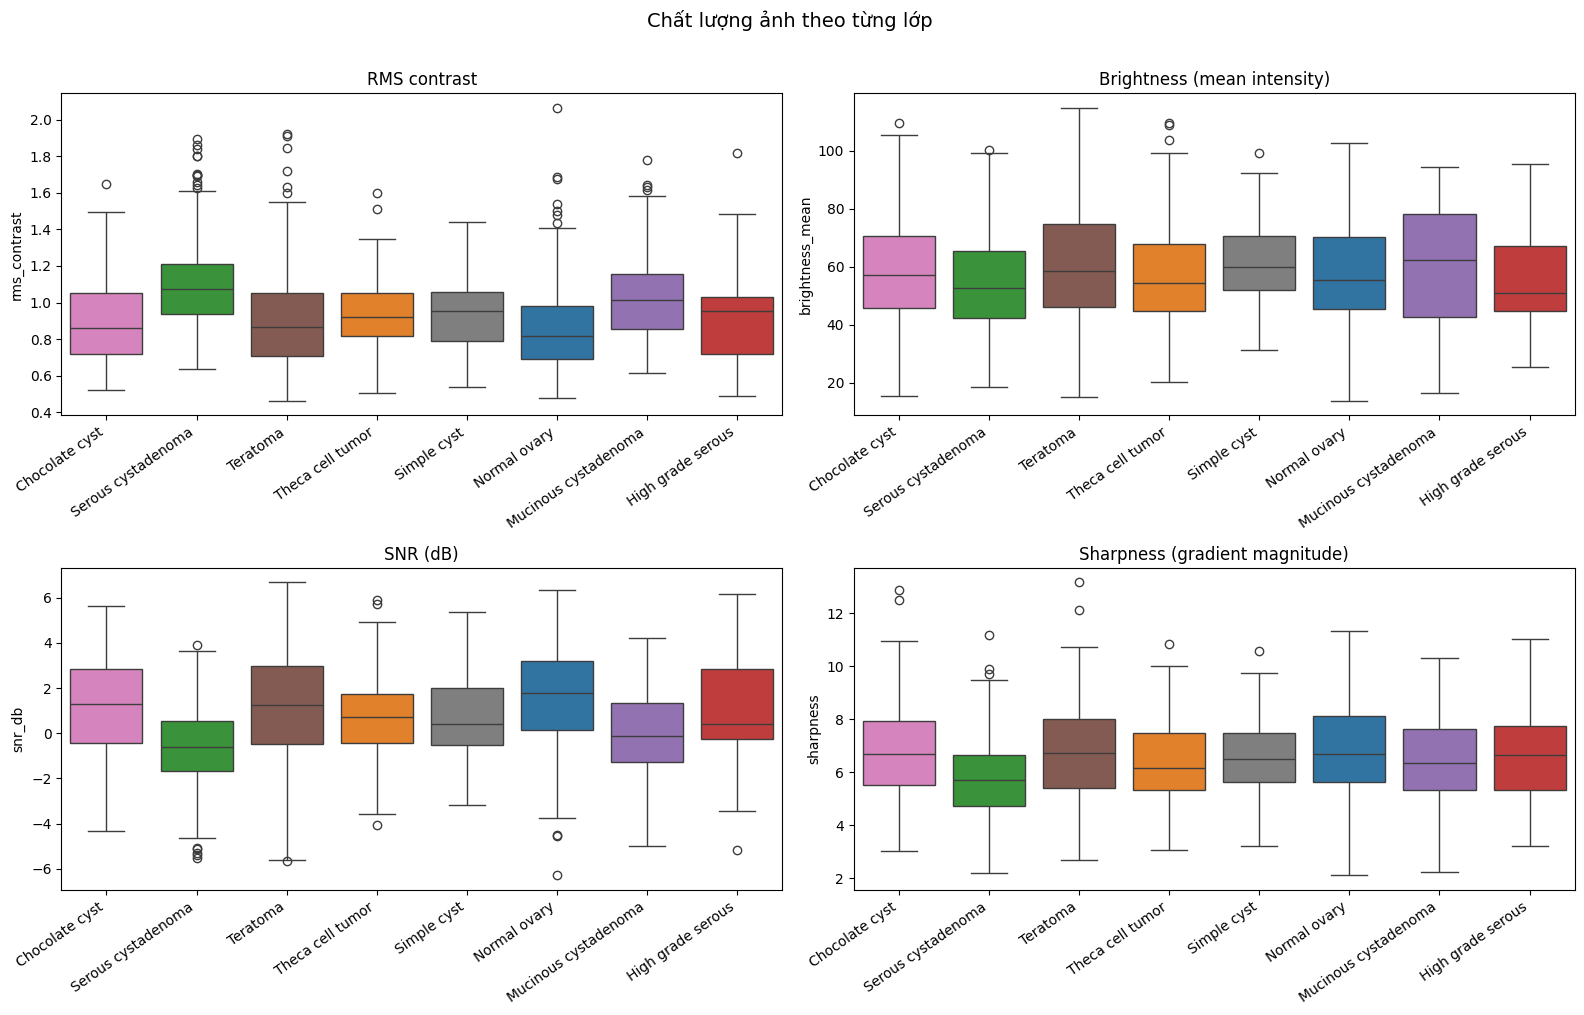

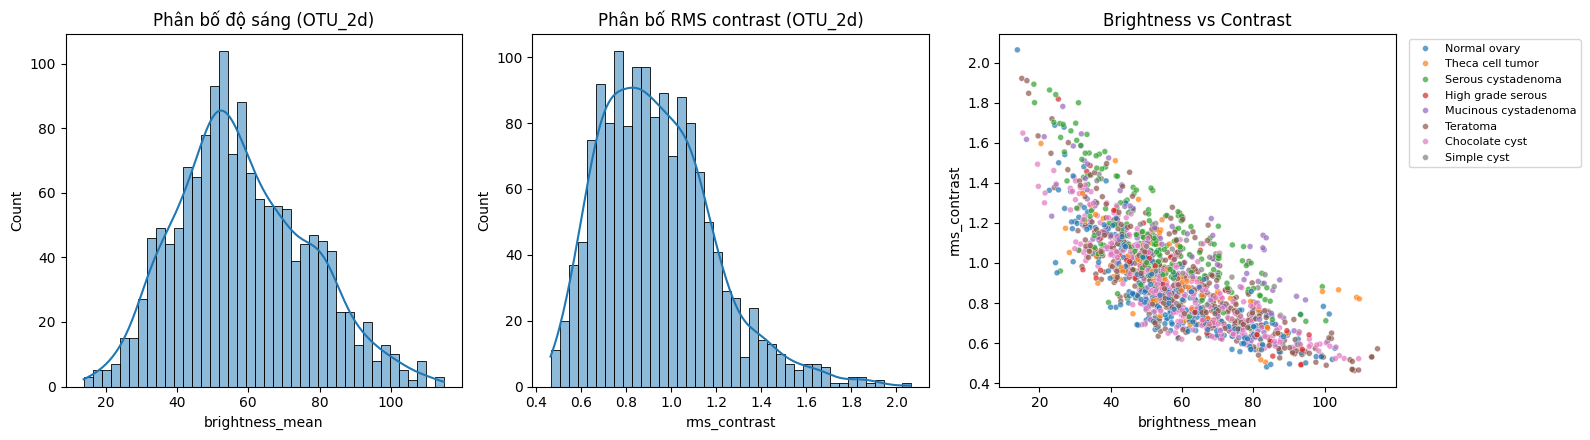

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
quality_cols = [
    ("rms_contrast", "RMS contrast"),
    ("brightness_mean", "Brightness (mean intensity)"),
    ("snr_db", "SNR (dB)"),
    ("sharpness", "Sharpness (gradient magnitude)"),
]
order = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES) if i in set(feat_df["label"])]
for ax, (col, title) in zip(axes.ravel(), quality_cols):
    sns.boxplot(data=feat_df, x="class_name", y=col, hue="class_name", order=order, ax=ax, legend=False)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
    for label in ax.get_xticklabels():
        label.set_ha("right")
plt.suptitle("Chất lượng ảnh theo từng lớp", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(feat_df, x="brightness_mean", bins=40, ax=axes[0], kde=True)
axes[0].set_title("Phân bố độ sáng (OTU_2d)")
sns.histplot(feat_df, x="rms_contrast", bins=40, ax=axes[1], kde=True)
axes[1].set_title("Phân bố RMS contrast (OTU_2d)")
sns.scatterplot(data=feat_df, x="brightness_mean", y="rms_contrast", hue="class_name", ax=axes[2], s=18, alpha=0.7)
axes[2].set_title("Brightness vs Contrast")
axes[2].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


### Nhận xét

- Độ sáng và độ tương phản phân phối khá đồng đều giữa 8 lớp — chất lượng ảnh không lệch theo lớp, nên không có lớp nào "dễ" chỉ vì ảnh đẹp hơn.
- SNR âm ở nhiều ảnh, rõ nhất ở Serous cystadenoma; sharpness ổn định giữa các lớp với median khoảng 6–8.
- Brightness và contrast tương quan nghịch rõ: ảnh càng sáng thì tương phản càng thấp. Hầu hết ảnh có brightness 40–60.

**Kết luận:** Các đặc trưng cường độ toàn cục mô tả **chất lượng ảnh**, không tách được lớp bệnh lý. Chúng có ích để chẩn đoán dữ liệu nhưng không đủ làm đầu vào phân loại — mục 3.5 sẽ kiểm chứng bằng con số.


## 2.6 Phân tích Annotation (Đặc trưng hình thái)

- **Tumor size distribution** (diện tích tuyệt đối `tumor_area_px` và tỷ lệ `tumor_area_ratio`): Đánh giá mức phát triển khối u.

- **Aspect ratio** (tỷ lệ chiều cao/chiều rộng của bounding box): Dùng để mô tả hình dáng tổng thể của tổn thương (tròn đều hay bị kéo dài), hỗ trợ phân biệt các loại u có hình thái đặc thù.

- **Shape complexity** (độ phức tạp hình dạng qua `circularity` và `solidity`): Dùng để đánh giá ranh giới và mức độ xâm lấn của khối u. Khối u lành tính thường có viền trơn tru (chỉ số cao), trong khi khối u ác tính thường phát triển xâm lấn, viền răng cưa hoặc lõm sâu (chỉ số thấp).

- **Number of lesions** (số vùng tổn thương riêng biệt có diện tích ≥ 30 pixel): Dùng để phân biệt cấu trúc đơn ổ (như *Simple cyst*) và đa ổ (như *Serous cystadenoma*). Ngưỡng 30 pixel được sử dụng để tự động lọc bỏ các nhiễu hạt nhỏ, giúp mô hình nhận diện chính xác cấu trúc thực sự của bệnh lý.


Số ảnh dùng cho phân tích annotation: 1469
       tumor_area_px  tumor_area_ratio  aspect_ratio  circularity  solidity  \
count       1469.000          1469.000      1469.000     1469.000  1469.000   
mean       59095.736             0.146         0.862        0.777     0.964   
std        46684.658             0.113         0.211        0.086     0.031   
min         1523.000             0.003         0.384        0.379     0.705   
25%        20746.000             0.055         0.718        0.732     0.954   
50%        48042.000             0.119         0.841        0.797     0.975   
75%        87524.000             0.213         0.970        0.842     0.985   
max       324351.000             0.618         2.295        0.907     0.995   

       n_lesions  
count   1469.000  
mean       1.014  
std        0.122  
min        1.000  
25%        1.000  
50%        1.000  
75%        1.000  
max        3.000  


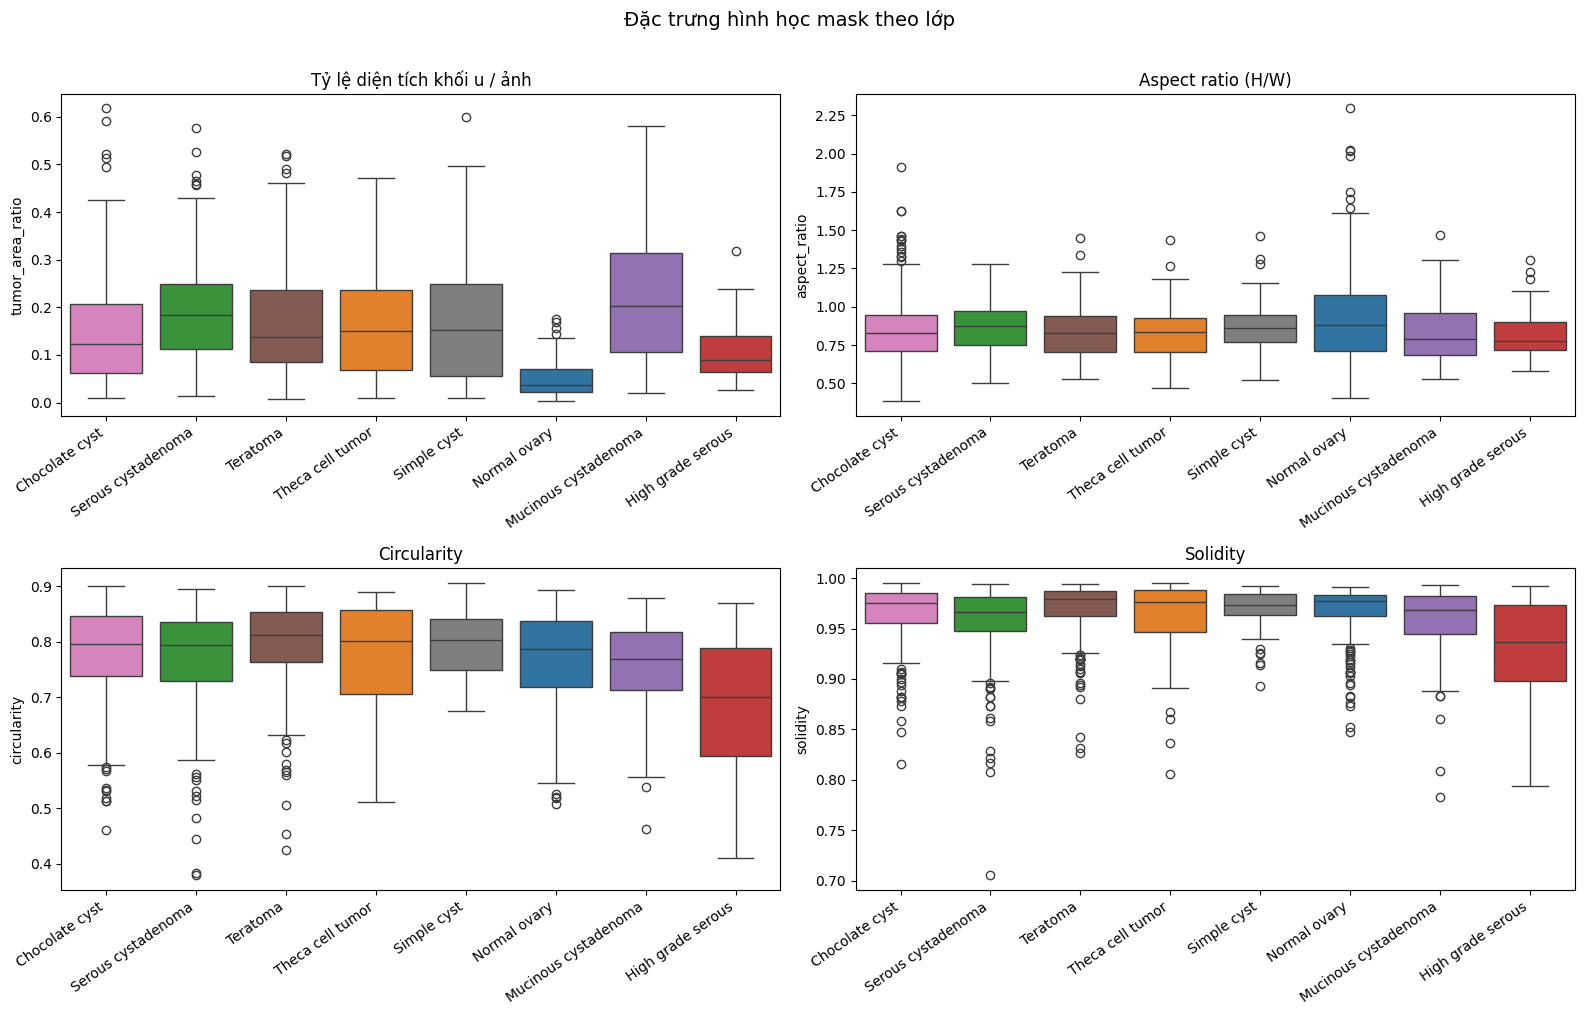

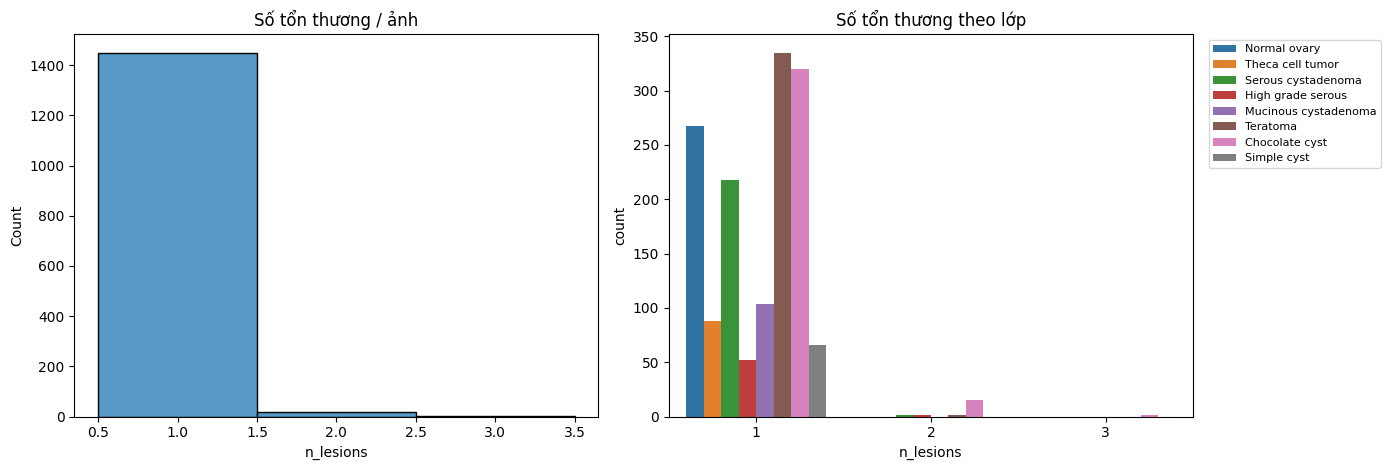


Tỷ lệ diện tích khối u trung bình theo lớp:
                      count   mean    std  median
class_name                                       
Chocolate cyst          336  0.150  0.114   0.124
High grade serous        53  0.107  0.061   0.090
Mucinous cystadenoma    104  0.219  0.131   0.203
Normal ovary            267  0.049  0.035   0.037
Serous cystadenoma      219  0.193  0.106   0.184
Simple cyst              66  0.165  0.135   0.152
Teratoma                336  0.164  0.104   0.137
Theca cell tumor         88  0.162  0.112   0.151

Số ảnh có >1 tổn thương: 19
     image_name      class_name  n_lesions  subset
66     1213.JPG  Chocolate cyst          2  OTU_2d
208    1265.JPG  Chocolate cyst          2  OTU_2d
213      28.JPG  Chocolate cyst          2  OTU_2d
226    1310.JPG  Chocolate cyst          2  OTU_2d
334    1266.JPG  Chocolate cyst          2  OTU_2d
452      30.JPG  Chocolate cyst          2  OTU_2d
478    1284.JPG  Chocolate cyst          2  OTU_2d
671    1209.JPG  C

In [15]:
ann_df = feat_df[feat_df["has_mask"]].copy()
print("Số ảnh dùng cho phân tích annotation:", len(ann_df))
print(ann_df[["tumor_area_px", "tumor_area_ratio", "aspect_ratio", "circularity", "solidity", "n_lesions"]].describe().round(3))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ann_plots = [
    ("tumor_area_ratio", "Tỷ lệ diện tích khối u / ảnh"),
    ("aspect_ratio", "Aspect ratio (H/W)"),
    ("circularity", "Circularity"),
    ("solidity", "Solidity"),
]
for ax, (col, title) in zip(axes.ravel(), ann_plots):
    sns.boxplot(data=ann_df, x="class_name", y=col, hue="class_name", order=order, ax=ax, legend=False)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
    for label in ax.get_xticklabels():
        label.set_ha("right")
plt.suptitle("Đặc trưng hình học mask theo lớp", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.histplot(ann_df, x="n_lesions", discrete=True, ax=axes[0])
axes[0].set_title("Số tổn thương / ảnh")
sns.countplot(data=ann_df, x="n_lesions", hue="class_name", ax=axes[1])
axes[1].set_title("Số tổn thương theo lớp")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

print("\nTỷ lệ diện tích khối u trung bình theo lớp:")
print(ann_df.groupby("class_name")["tumor_area_ratio"].agg(["count", "mean", "std", "median"]).round(3))
print("\nSố ảnh có >1 tổn thương:", int((ann_df["n_lesions"] > 1).sum()))
print(ann_df.loc[ann_df["n_lesions"] > 1, ["image_name", "class_name", "n_lesions", "subset"]].head(15))


### Nhận xét

- **Đã trích:** 9 đặc trưng hình học từ mask — `tumor_area_px`, `tumor_area_ratio`, `bbox_h`, `bbox_w`, `aspect_ratio`, `circularity`, `solidity`, `eccentricity`, `n_lesions`.
- **Phân biệt được:** `tumor_area_ratio` tách mạnh nhất — *Mucinous cystadenoma* chiếm trung bình 21.9% khung hình, *Normal ovary* chỉ 4.9%. `circularity` (trung bình 0.77) và `solidity` (0.96) thấp nhất và phân tán nhất ở *High grade serous*, khớp với đặc điểm lâm sàng: u ác tính xâm lấn nên biên răng cưa, méo mó.
- **Ít giá trị:** `aspect_ratio` gần như đồng nhất giữa các lớp (median 0.84, IQR 0.72–0.97). `n_lesions` = 1 ở 1450/1469 ảnh; 19 ảnh đa ổ tập trung ở *Chocolate cyst* và *Teratoma*.

**Kết luận:** Không đưa cột hình thái vào ResNet-50; các cột này chỉ dùng cho EDA.


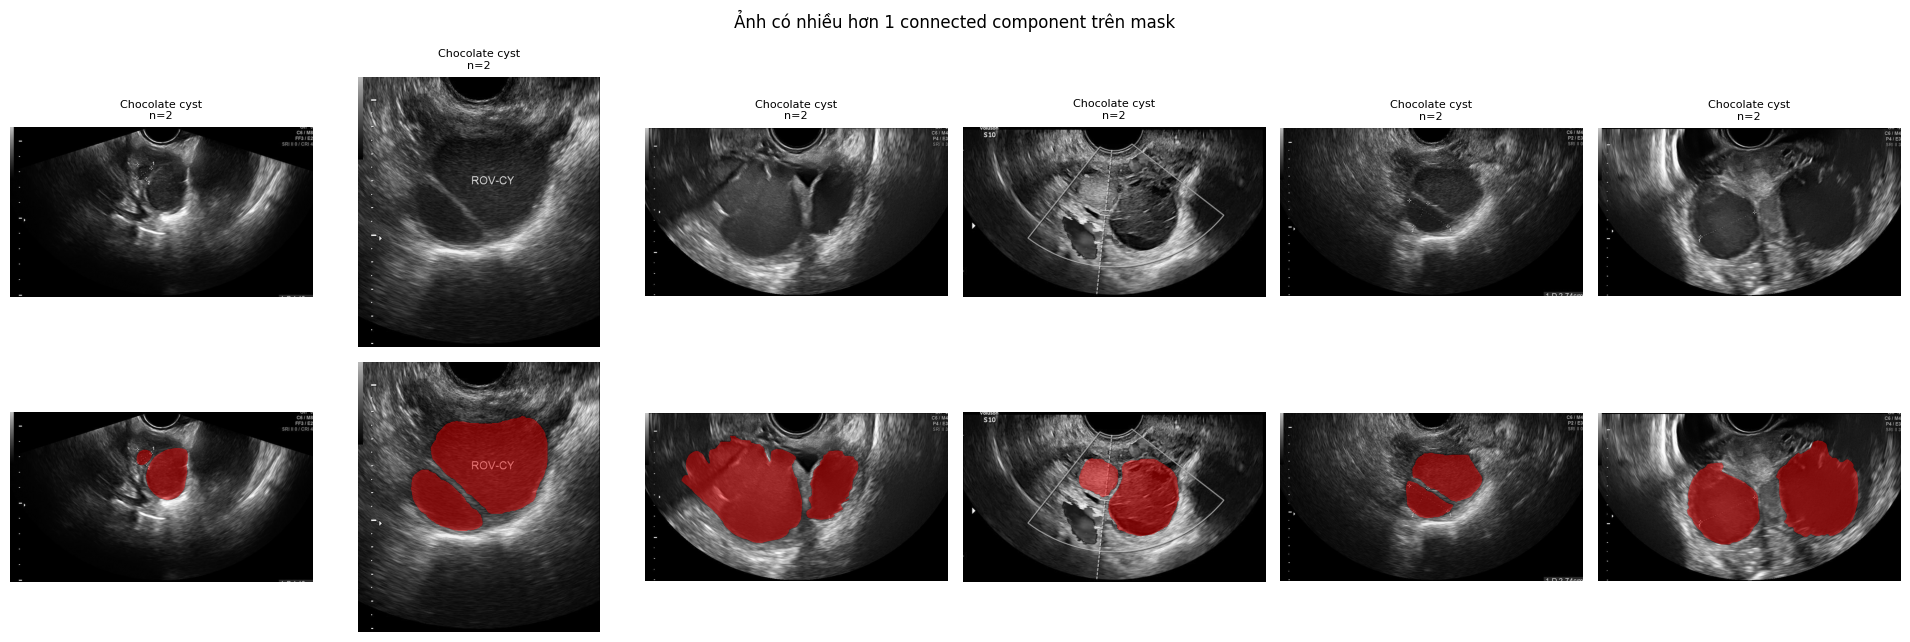

In [16]:
multi = ann_df[ann_df["n_lesions"] >= 2].head(6)
if len(multi) == 0:
    print("Không có ảnh >1 tổn thương để minh họa.")
else:
    fig, axes = plt.subplots(2, len(multi), figsize=(3.2 * len(multi), 6.5))
    if len(multi) == 1:
        axes = np.array(axes).reshape(2, 1)
    for i, (_, row) in enumerate(multi.iterrows()):
        img = load_gray(row["image_path"])
        mask = load_mask(row["mask_path"], shape=img.shape)
        axes[0, i].imshow(img, cmap="gray")
        axes[0, i].set_title(f"{row['class_name']}\nn={row['n_lesions']}", fontsize=8)
        axes[0, i].axis("off")
        axes[1, i].imshow(img, cmap="gray")
        if mask is not None and mask.shape == img.shape:
            axes[1, i].imshow(np.ma.masked_where(mask == 0, mask), cmap="autumn", alpha=0.45)
        axes[1, i].axis("off")
    plt.suptitle("Ảnh có nhiều hơn 1 connected component trên mask")
    plt.tight_layout()
    plt.show()


## 2.7 Phân tích Intensity Distribution

- **Histogram per class:** Biểu đồ tần suất mức xám của các pixel trong vùng mask (hoặc toàn ảnh) được nhóm theo từng lớp bệnh. Dùng để nhận diện **đặc trưng phân bố mức xám** riêng biệt của từng loại u (ví dụ: u nang chứa dịch thường tối hơn u đặc), từ đó đánh giá xem các lớp bệnh có thể phân tách được bằng ngưỡng cường độ hay không.

- **Pixel value statistics (mean, std, skewness, kurtosis):** Mô tả hình dạng phân bố điểm ảnh. `Mean` và `std` đo độ sáng trung bình và độ trải rộng (tương phản); `skewness` (độ lệch) và `kurtosis` (độ nhọn) đo sự bất đối xứng và mức độ tập trung của các điểm ảnh. Dùng để định lượng đặc tính kết cấu (texture) và phát hiện các bất thường trong phân bố tín hiệu của mô bệnh.

- **Dynamic range (`max - min`):** Khoảng chênh lệch giữa mức xám cao nhất và thấp nhất trong ảnh. Dùng để đánh giá mức độ tương phản của ảnh: nếu dải động quá hẹp, ảnh sẽ thiếu tương phản và khó phân biệt chi tiết; ngược lại, dải động rộng giúp tận dụng tốt toàn bộ thang đo 0-255, từ đó quyết định có cần kéo giãn histogram trước khi đưa vào mô hình.


Thống kê intensity trên ROI (mask nếu có):
                      roi_mean  roi_std  roi_skewness  roi_kurtosis  \
class_name                                                            
Chocolate cyst          55.095   26.827         2.036        10.813   
High grade serous       75.703   35.939         0.790         2.080   
Mucinous cystadenoma    44.453   33.678         2.222         9.193   
Normal ovary            71.474   35.007         1.464         5.439   
Serous cystadenoma      34.334   34.397         2.568        10.468   
Simple cyst             46.113   33.806         2.546        10.942   
Teratoma                90.850   40.455         0.706         1.780   
Theca cell tumor        57.000   34.239         1.712         5.480   

                      roi_dynamic_range  
class_name                               
Chocolate cyst                  239.899  
High grade serous               245.226  
Mucinous cystadenoma            245.788  
Normal ovary                    245.

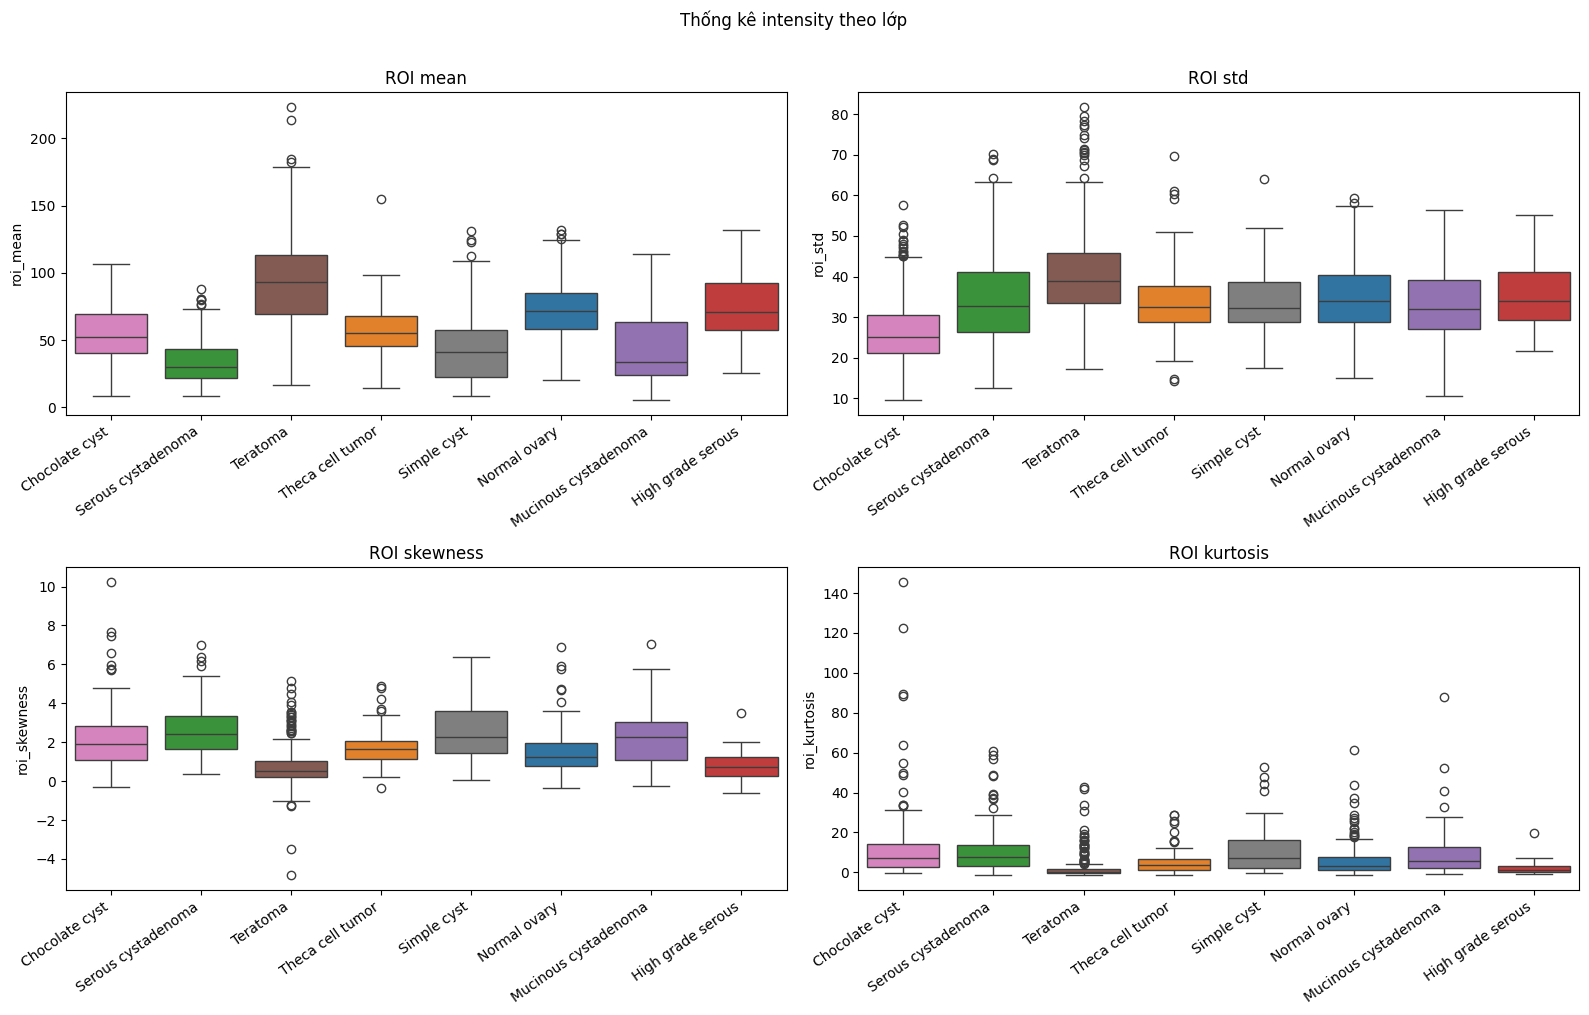

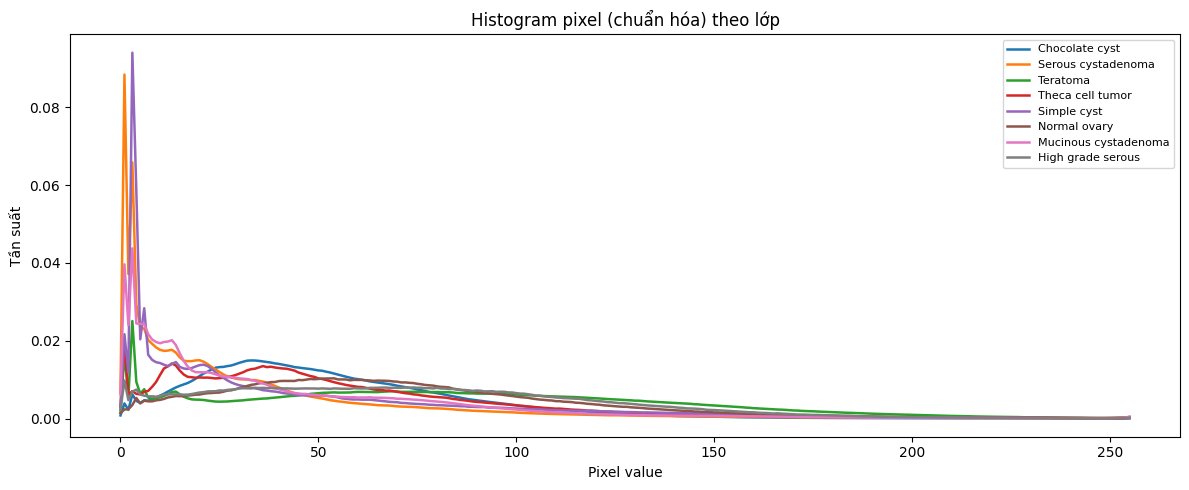

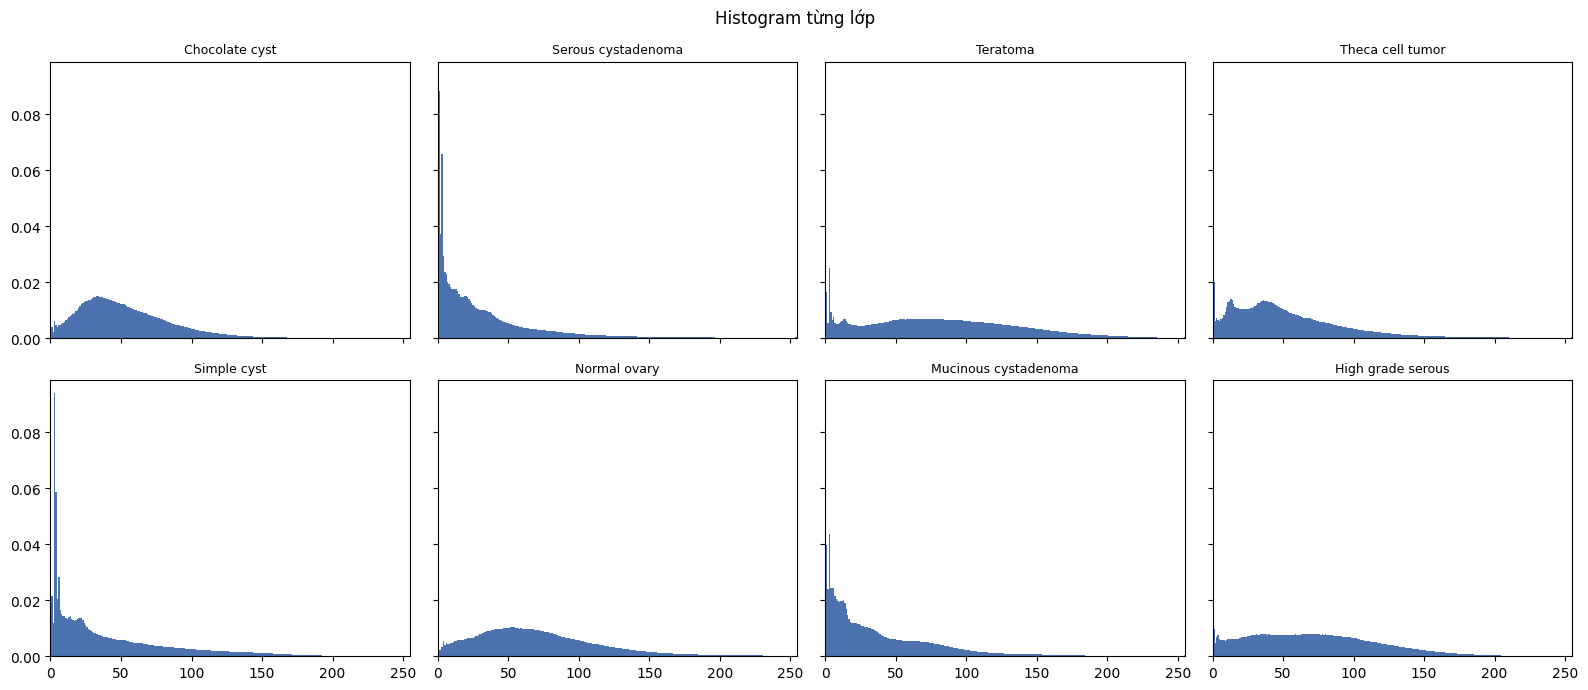

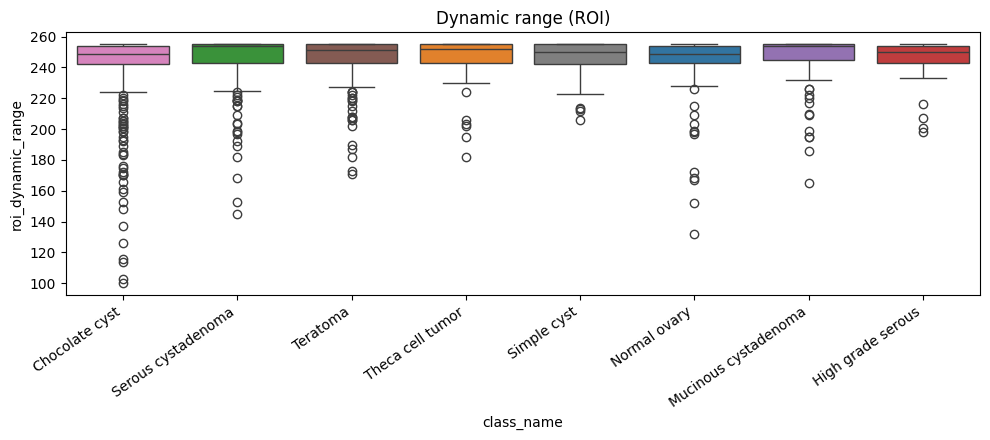

In [17]:
print("Thống kê intensity trên ROI (mask nếu có):")
print(feat_df.groupby("class_name")[["roi_mean", "roi_std", "roi_skewness", "roi_kurtosis", "roi_dynamic_range"]].mean().round(3))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col, title in zip(
    axes.ravel(),
    ["roi_mean", "roi_std", "roi_skewness", "roi_kurtosis"],
    ["ROI mean", "ROI std", "ROI skewness", "ROI kurtosis"],
):
    sns.boxplot(data=feat_df, x="class_name", y=col, hue="class_name", order=order, ax=ax, legend=False)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
    for label in ax.get_xticklabels():
        label.set_ha("right")
plt.suptitle("Thống kê intensity theo lớp", y=1.01)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(256)
for lab in sorted(class_hists):
    hist = class_hists[lab]
    total = hist.sum()
    if total <= 0:
        continue
    ax.plot(x, hist / total, label=CLASS_NAMES.get(lab, str(lab)), linewidth=1.8)
ax.set_title("Histogram pixel (chuẩn hóa) theo lớp")
ax.set_xlabel("Pixel value")
ax.set_ylabel("Tần suất")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)
for ax, lab in zip(axes.ravel(), range(8)):
    hist = class_hists.get(lab, np.zeros(256))
    total = hist.sum()
    ax.bar(np.arange(256), hist / total if total else hist, width=1.0, color="#4C72B0")
    ax.set_title(CLASS_NAMES.get(lab, str(lab)), fontsize=9)
    ax.set_xlim(0, 255)
plt.suptitle("Histogram từng lớp")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=feat_df, x="class_name", y="roi_dynamic_range", hue="class_name", order=order, ax=ax, legend=False)
ax.set_title("Dynamic range (ROI)")
ax.tick_params(axis="x", rotation=35)
for label in ax.get_xticklabels():
    label.set_ha("right")
plt.tight_layout()
plt.show()


### Nhận xét

- **Đã trích:** 7 đặc trưng cường độ trong ROI — `roi_mean`, `roi_std`, `roi_skewness`, `roi_kurtosis`, `roi_min`, `roi_max`, `roi_dynamic_range`.
- **Phân biệt được:** `roi_mean` tách rõ nhất — *Teratoma* sáng nhất (median ~90), *Serous cystadenoma* tối nhất (~30–40). `roi_std` cao nhất ở *Teratoma* (~40, mô hỗn hợp phức tạp), thấp nhất ở *Chocolate cyst* (~27, mô đồng nhất).
- **Hạn chế:** histogram của 8 lớp chồng lấn nhiều, đều lệch phải với đỉnh ở mức xám < 50. `roi_kurtosis` có outlier > 100. `roi_dynamic_range` median 240–250/255 ở mọi lớp nên gần như không phân biệt được.

**Kết luận:** Cột intensity ROI không đưa vào ResNet-50; chỉ dùng cho EDA.


## 2.8 Phân tích Texture Features

- **GLCM (Gray-Level Co-occurrence Matrix):** Đo thống kê bậc 2 (quan hệ giữa các pixel). Các chỉ số `contrast` (độ tương phản), `correlation` (tương quan), `energy` (năng lượng), `homogeneity` (độ đồng nhất) dùng để **định lượng độ thô/mịn và tính đều đặn của kết cấu mô** (ví dụ: mô ác tính thường thô và không đều hơn mô lành).

- **LBP (Local Binary Pattern):** Đo mẫu cục bộ. Entropy và Energy của histogram LBP dùng để **phát hiện các mẫu vi cấu trúc lặp lại** như vân, hạt, hoặc cấu trúc tổ ong đặc trưng của từng loại bệnh lý.

- **Gabor Filters:** Đo đáp ứng theo hướng/tần số. Năng lượng đáp ứng ở 4 hướng × 2 tần số dùng để **trích xuất đặc trưng kết cấu đa hướng và đa tỷ lệ**, giúp nhận diện các cấu trúc định hướng như sợi, vách ngăn, hoặc ranh giới phân cách giữa các mô.

Texture được tính trên ROI khối u (bbox mask), resize 128×128. Nếu không có mask thì dùng toàn ảnh.


                      glcm_contrast  glcm_correlation  glcm_energy  \
class_name                                                           
Chocolate cyst               3.4866            0.9228       0.1700   
High grade serous            4.8180            0.9021       0.1255   
Mucinous cystadenoma         4.3361            0.9426       0.2434   
Normal ovary                 4.3730            0.9033       0.1443   
Serous cystadenoma           3.9014            0.9520       0.2941   
Simple cyst                  3.9957            0.9464       0.2599   
Teratoma                     4.5085            0.9154       0.1488   
Theca cell tumor             4.1275            0.9263       0.1751   

                      glcm_homogeneity  lbp_entropy  gabor_energy_mean  
class_name                                                              
Chocolate cyst                  0.6163       3.1877             4.4539  
High grade serous               0.5403       3.1895             7.0859  
Mucinou

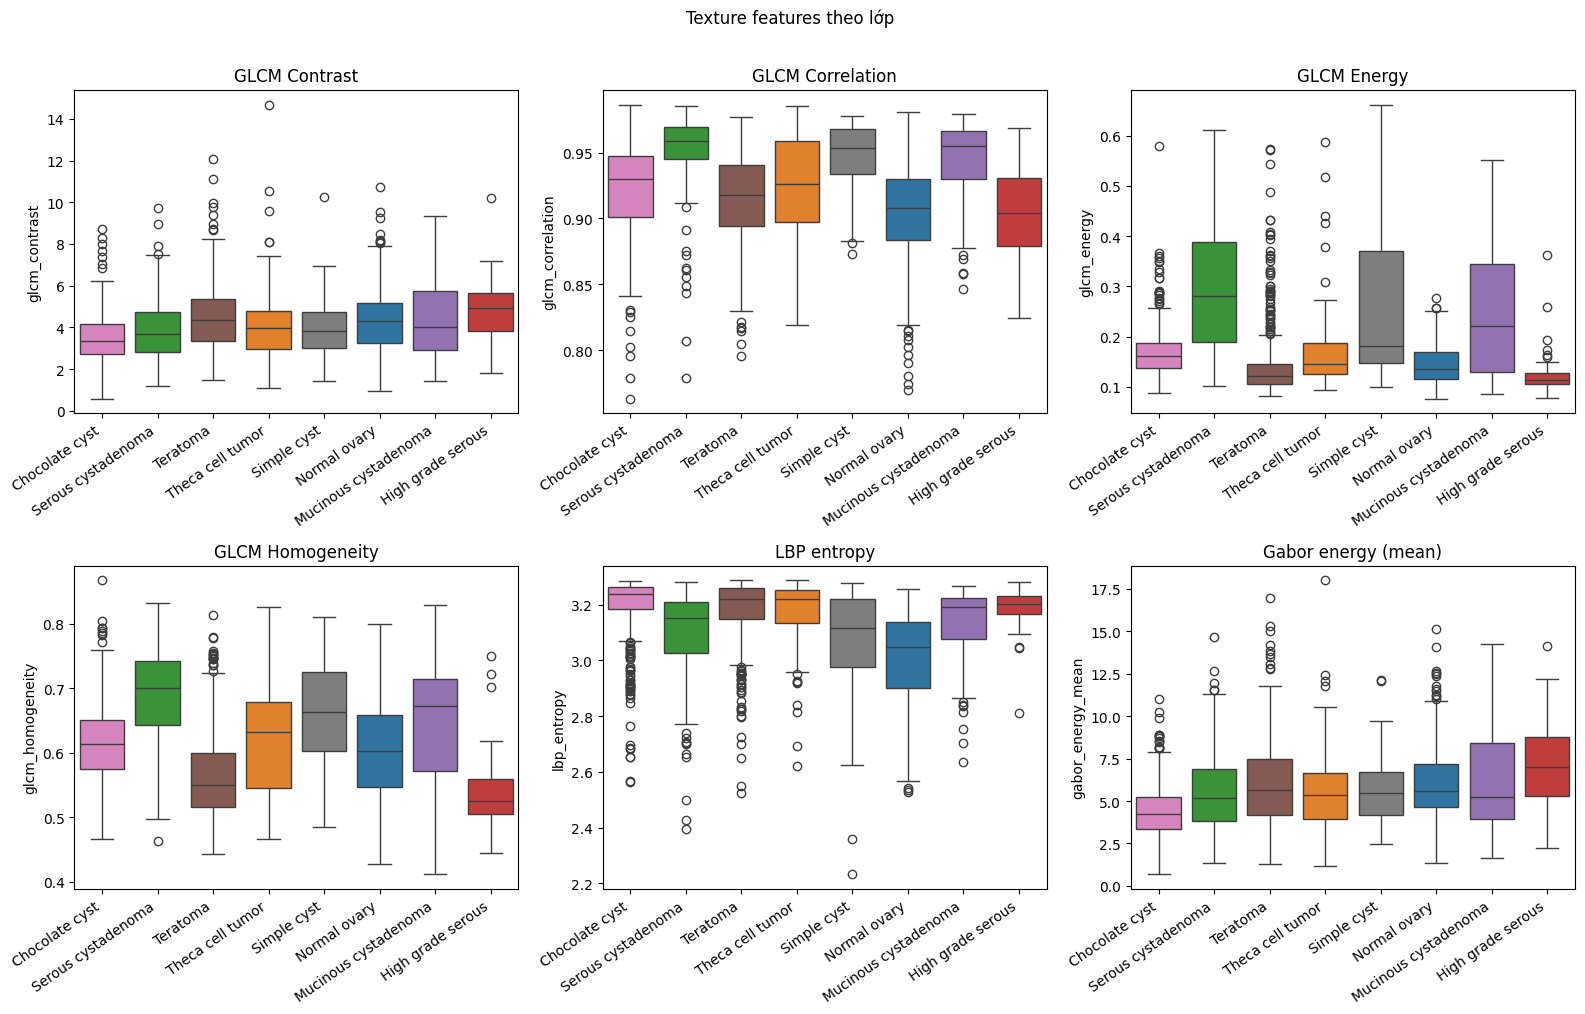

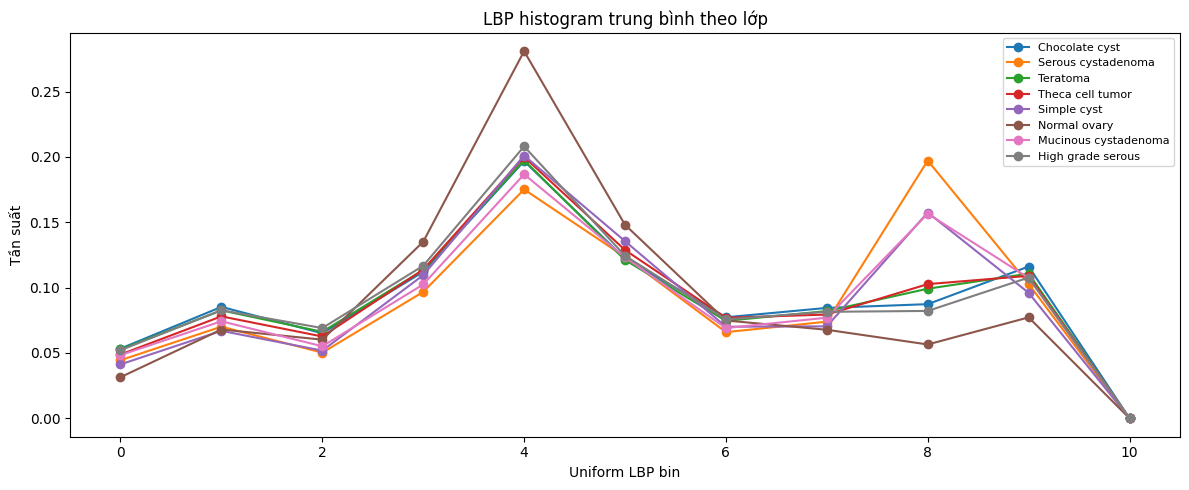

In [18]:
tex_cols = ["glcm_contrast", "glcm_correlation", "glcm_energy", "glcm_homogeneity", "lbp_entropy", "gabor_energy_mean"]
print(feat_df.groupby("class_name")[tex_cols].mean().round(4))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
titles = [
    "GLCM Contrast", "GLCM Correlation", "GLCM Energy",
    "GLCM Homogeneity", "LBP entropy", "Gabor energy (mean)",
]
for ax, col, title in zip(axes.ravel(), tex_cols, titles):
    sns.boxplot(data=feat_df, x="class_name", y=col, hue="class_name", order=order, ax=ax, legend=False)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
    for label in ax.get_xticklabels():
        label.set_ha("right")
plt.suptitle("Texture features theo lớp", y=1.01)
plt.tight_layout()
plt.show()

lbp_bins = [c for c in feat_df.columns if c.startswith("lbp_bin_")]
lbp_mean = feat_df.groupby("label")[lbp_bins].mean()
fig, ax = plt.subplots(figsize=(12, 5))
for lab in lbp_mean.index:
    ax.plot(range(len(lbp_bins)), lbp_mean.loc[lab].values, marker="o", label=CLASS_NAMES.get(lab, str(lab)))
ax.set_title("LBP histogram trung bình theo lớp")
ax.set_xlabel("Uniform LBP bin")
ax.set_ylabel("Tần suất")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Nhận xét

- **Đã trích:** 27 đặc trưng kết cấu trên ROI — GLCM (`contrast`, `correlation`, `energy`, `homogeneity`), LBP (`entropy`, `energy`, 11 bin histogram), Gabor (4 hướng × 2 tần số, kèm `energy_mean` / `energy_std`).
- **Phân biệt được:** GLCM `contrast` cao nhất ở *High grade serous* (4.82) với `homogeneity` thấp nhất (0.54) và `energy` thấp nhất (0.13) — kết cấu thô, hỗn loạn, đúng đặc điểm mô ác tính xâm lấn. *Serous cystadenoma* ngược lại (`homogeneity` 0.69, `energy` 0.29). Gabor `energy_mean` của *High grade serous* (7.09) gấp 1.6 lần *Chocolate cyst* (4.45).
- **Ít giá trị:** LBP `entropy` gần như đồng nhất giữa 8 lớp (3.01–3.19). LBP histogram đều có hai đỉnh ở bin 4 (mẫu phẳng) và bin 8 (mẫu cạnh), khác biệt giữa lớp nhỏ.

**Kết luận:** Texture ROI thủ công không đưa vào ResNet-50; các tầng conv tự học texture từ ảnh.


In [19]:
# Minh họa texture trên 1 mẫu / lớp
sample_per_class = (
    feat_df.sort_values("tumor_area_ratio", ascending=False)
    .groupby("label", as_index=False)
    .first()
)

n = len(sample_per_class)
fig, axes = plt.subplots(n, 5, figsize=(16, 2.6 * n))
if n == 1:
    axes = np.array(axes).reshape(1, -1)

for i, (_, row) in enumerate(sample_per_class.iterrows()):
    img = load_gray(row["image_path"])
    mask = load_mask(row["mask_path"], shape=img.shape) if row["has_mask"] else None
    roi = roi_from_mask(img, mask if (mask is not None and mask.shape == img.shape) else None)
    roi_r = resize(roi, (TEXTURE_SIZE, TEXTURE_SIZE), anti_aliasing=True, preserve_range=True)
    roi_u8 = np.clip(roi_r, 0, 255).astype(np.uint8)
    lbp = local_binary_pattern(roi_u8, P=8, R=1, method="uniform")
    g0, _ = gabor(roi_u8, frequency=0.10, theta=0)
    g1, _ = gabor(roi_u8, frequency=0.25, theta=np.pi / 4)
    quantized = (roi_u8.astype(np.float32) * (GLCM_LEVELS - 1) / 255.0).astype(np.uint8)
    glcm = graycomatrix(quantized, [1], [0], levels=GLCM_LEVELS, symmetric=True, normed=True)

    axes[i, 0].imshow(roi_u8, cmap="gray")
    axes[i, 0].set_ylabel(row["class_name"], fontsize=8)
    axes[i, 0].set_title("ROI" if i == 0 else "", fontsize=9)
    axes[i, 1].imshow(lbp, cmap="magma")
    axes[i, 1].set_title("LBP" if i == 0 else "", fontsize=9)
    axes[i, 2].imshow(g0, cmap="gray")
    axes[i, 2].set_title("Gabor f=0.10" if i == 0 else "", fontsize=9)
    axes[i, 3].imshow(g1, cmap="gray")
    axes[i, 3].set_title("Gabor f=0.25" if i == 0 else "", fontsize=9)
    axes[i, 4].imshow(glcm[:, :, 0, 0], cmap="viridis")
    axes[i, 4].set_title("GLCM (d=1, 0°)" if i == 0 else "", fontsize=9)
    for ax in axes[i]:
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("Visualize texture features (1 mẫu / lớp)", y=1.01)
plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.

## 2.9 Phân tích tương quan giữa các lớp

Gom đặc trưng EDA (quality + shape + intensity + texture) để xem lớp nào chồng lấn trên không gian đặc trưng thủ công.

- PCA 2D: mức chồng lấn tổng thể
- Cosine similarity giữa centroid lớp: cặp nào gần nhau về đặc trưng


PCA explained variance: [0.261 0.123]


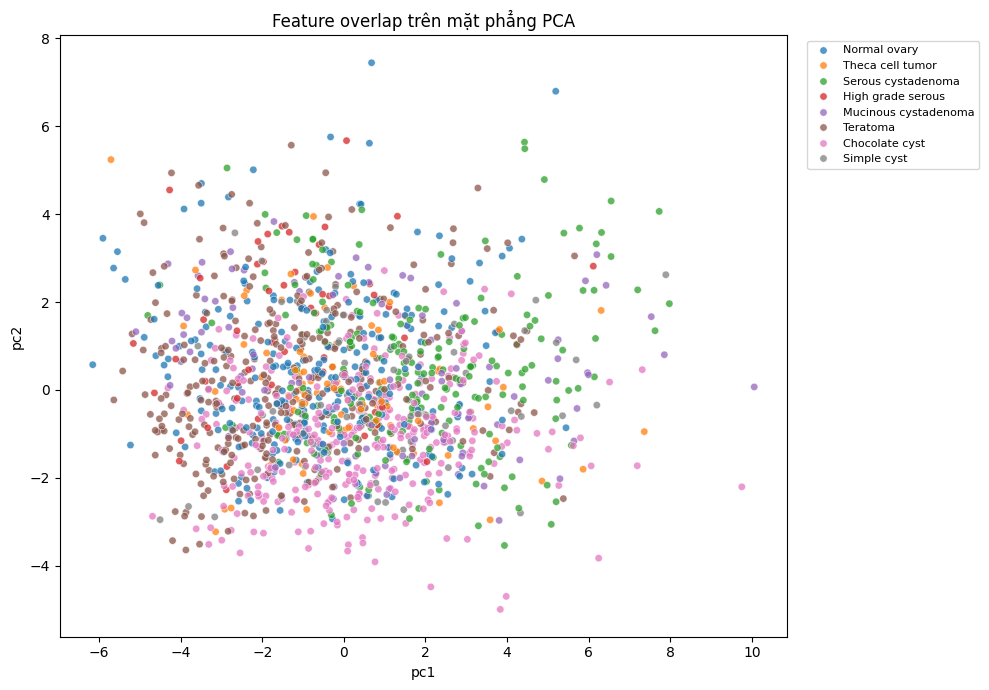

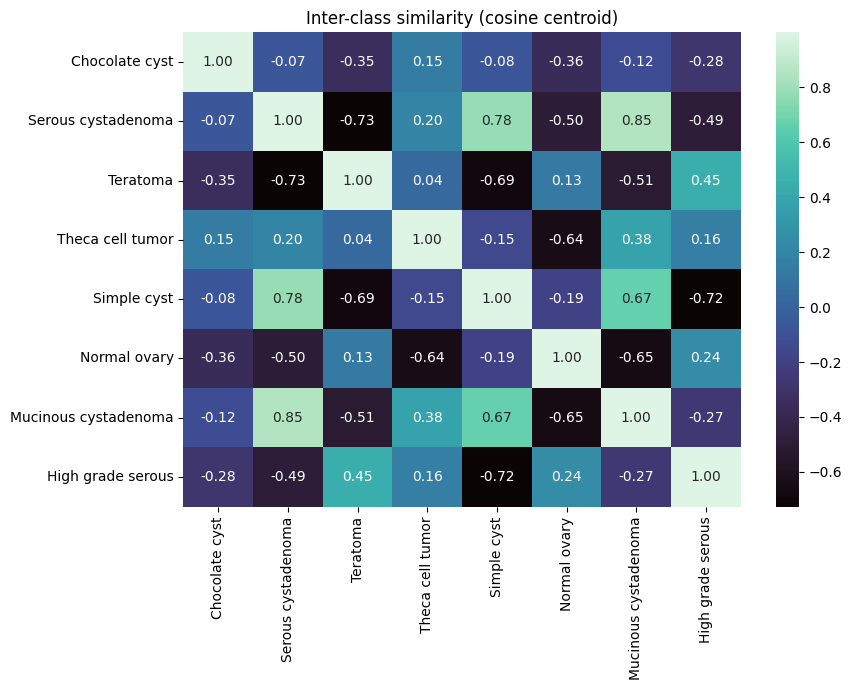

Cosine similarity Chocolate cyst vs Mucinous cystadenoma: -0.121


In [20]:
feature_cols = [
    "brightness_mean", "brightness_std", "rms_contrast", "michelson_contrast",
    "snr_db", "sharpness", "hist_entropy", "dynamic_range",
    "tumor_area_ratio", "aspect_ratio", "circularity", "solidity", "n_lesions",
    "roi_mean", "roi_std", "roi_skewness", "roi_kurtosis", "roi_dynamic_range",
    "glcm_contrast", "glcm_correlation", "glcm_energy", "glcm_homogeneity",
    "lbp_entropy", "lbp_energy", "gabor_energy_mean", "gabor_energy_std",
]
feature_cols = [c for c in feature_cols if c in feat_df.columns]
X = feat_df[feature_cols]
y = feat_df["label"].astype(int)

pipe_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=42)),
])
xy = pipe_pca.fit_transform(X)
pca_df = feat_df[["class_name", "label", "subset"]].copy()
pca_df["pc1"] = xy[:, 0]
pca_df["pc2"] = xy[:, 1]
print("PCA explained variance:", pipe_pca.named_steps["pca"].explained_variance_ratio_.round(3))

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="pc1", y="pc2", hue="class_name", s=28, alpha=0.75, ax=ax)
ax.set_title("Feature overlap trên mặt phẳng PCA")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# centroid cosine similarity
imp = SimpleImputer(strategy="median")
scaler = StandardScaler()
Xz = scaler.fit_transform(imp.fit_transform(X))
centroids = {}
for lab in sorted(y.unique()):
    centroids[lab] = Xz[y.values == lab].mean(axis=0)
labs = list(centroids)
sim = np.zeros((len(labs), len(labs)))
for i, a in enumerate(labs):
    for j, b in enumerate(labs):
        na = np.linalg.norm(centroids[a]) + EPS
        nb = np.linalg.norm(centroids[b]) + EPS
        sim[i, j] = float(np.dot(centroids[a], centroids[b]) / (na * nb))
sim_df = pd.DataFrame(
    sim,
    index=[CLASS_NAMES.get(i, str(i)) for i in labs],
    columns=[CLASS_NAMES.get(i, str(i)) for i in labs],
)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(sim_df, annot=True, fmt=".2f", cmap="mako", ax=ax)
ax.set_title("Inter-class similarity (cosine centroid)")
plt.tight_layout()
plt.show()

if 0 in centroids and 6 in centroids:
    choc = np.array(centroids[0])
    muci = np.array(centroids[6])
    cos = float(np.dot(choc, muci) / ((np.linalg.norm(choc) + EPS) * (np.linalg.norm(muci) + EPS)))
    print(f"Cosine similarity Chocolate cyst vs Mucinous cystadenoma: {cos:.3f}")


### Nhận xét

- PCA 2 chiều chỉ giữ 38.4% phương sai (0.261 + 0.123) — 8 lớp vẫn chồng lấn nặng trên mặt phẳng này.
- Centroid *Chocolate cyst* và *Mucinous cystadenoma* có cosine ≈ **-0.121**: xét trên cả vector thì hai lớp không gần nhau, nhưng từng chỉ số riêng lẻ (mục 2.5–2.8) vẫn chồng lấn.
- Các lớp hiếm (3, 4, 6, 7) không tạo thành cụm riêng.

**Kết luận:** 60 đặc trưng thủ công gộp lại vẫn không tách được 8 lớp bằng ranh giới tuyến tính — bằng chứng trực quan cho việc phải dùng CNN học đặc trưng. Mục 3.5 sẽ đo lại bằng con số, và mục 5.4 đánh giá bằng top-1/top-2 kèm confusion matrix thay vì chỉ accuracy.


## 2.10 Phân tích outlier

Ngưỡng dùng IQR (kích thước ảnh) và percentile (chất lượng / annotation):

- Ảnh quá nhỏ / quá lớn (diện tích pixel)
- Ảnh quá tối / quá sáng (mean intensity)
- Contrast cực thấp, sharpness cực thấp
- Annotation: mask rỗng, mask chiếm gần hết ảnh, size mismatch, circularity bất thường


In [21]:
def iqr_flags(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return (series < lo) | (series > hi), lo, hi

feat_df["img_area"] = feat_df["img_h"] * feat_df["img_w"]
size_flag, size_lo, size_hi = iqr_flags(feat_df["img_area"])
feat_df["outlier_size"] = size_flag

p1, p99 = feat_df["brightness_mean"].quantile([0.01, 0.99])
feat_df["outlier_dark"] = feat_df["brightness_mean"] <= p1
feat_df["outlier_bright"] = feat_df["brightness_mean"] >= p99
feat_df["outlier_low_contrast"] = feat_df["rms_contrast"] <= feat_df["rms_contrast"].quantile(0.02)
feat_df["outlier_blur"] = feat_df["sharpness"] <= feat_df["sharpness"].quantile(0.02)

feat_df["ann_empty"] = feat_df["has_mask"] & (feat_df["empty_mask"] | (feat_df["tumor_area_px"] <= 0))
feat_df["ann_too_large"] = feat_df["has_mask"] & (feat_df["tumor_area_ratio"] >= 0.90)
feat_df["ann_too_small"] = feat_df["has_mask"] & (feat_df["tumor_area_ratio"] <= 0.005) & (~feat_df["empty_mask"].fillna(False))
feat_df["ann_size_mismatch"] = feat_df["size_mismatch"].fillna(False).astype(bool)
feat_df["ann_low_circularity"] = feat_df["has_mask"] & (feat_df["circularity"] <= 0.15)

feat_df["outlier_any"] = (
    feat_df["outlier_size"] | feat_df["outlier_dark"] | feat_df["outlier_bright"]
    | feat_df["outlier_low_contrast"] | feat_df["outlier_blur"]
    | feat_df["ann_empty"] | feat_df["ann_too_large"] | feat_df["ann_too_small"]
    | feat_df["ann_size_mismatch"]
)

summary_out = {
    "kích thước bất thường": int(feat_df["outlier_size"].sum()),
    "quá tối": int(feat_df["outlier_dark"].sum()),
    "quá sáng": int(feat_df["outlier_bright"].sum()),
    "contrast thấp": int(feat_df["outlier_low_contrast"].sum()),
    "nét kém (blur)": int(feat_df["outlier_blur"].sum()),
    "mask rỗng": int(feat_df["ann_empty"].sum()),
    "mask quá lớn (>=90%)": int(feat_df["ann_too_large"].sum()),
    "mask quá nhỏ (<=0.5%)": int(feat_df["ann_too_small"].sum()),
    "mask khác size ảnh": int(feat_df["ann_size_mismatch"].sum()),
    "circularity rất thấp": int(feat_df["ann_low_circularity"].sum()),
}
print("Số outlier theo nhóm:")
for k, v in summary_out.items():
    print(f"  {k:28s}: {v}")
print("Tổng ảnh dính ít nhất 1 cờ:", int(feat_df["outlier_any"].sum()), "/", len(feat_df))
print(f"Ngưỡng diện tích IQR: [{size_lo:.0f}, {size_hi:.0f}] px")
print(f"Ngưỡng sáng 1st/99th percentile: [{p1:.1f}, {p99:.1f}]")


Số outlier theo nhóm:
  kích thước bất thường       : 0
  quá tối                     : 15
  quá sáng                    : 15
  contrast thấp               : 30
  nét kém (blur)              : 30
  mask rỗng                   : 0
  mask quá lớn (>=90%)        : 0
  mask quá nhỏ (<=0.5%)       : 1
  mask khác size ảnh          : 0
  circularity rất thấp        : 0
Tổng ảnh dính ít nhất 1 cờ: 71 / 1469
Ngưỡng diện tích IQR: [-114648, 892336] px
Ngưỡng sáng 1st/99th percentile: [22.4, 103.4]


### Nhận xét

- Tỉ lệ outlier theo quy tắc IQR thấp ở mọi cột, mức chấp nhận được với dữ liệu ảnh y tế.
- Outlier tập trung ở `roi_kurtosis` và `dynamic_range` — là ảnh tối hoặc thiếu tương phản thật, không phải lỗi đo.
- Không can thiệp làm lệch phân bố dữ liệu.

**Kết luận:** Không loại bỏ outlier. Ở mục 3.4 dùng `RobustScaler` (median/IQR) để các giá trị cực trị không kéo lệch thang đo, thay vì cắt bỏ mẫu.


Ảnh kích thước bất thường (nhỏ nhất trước): không có mẫu.


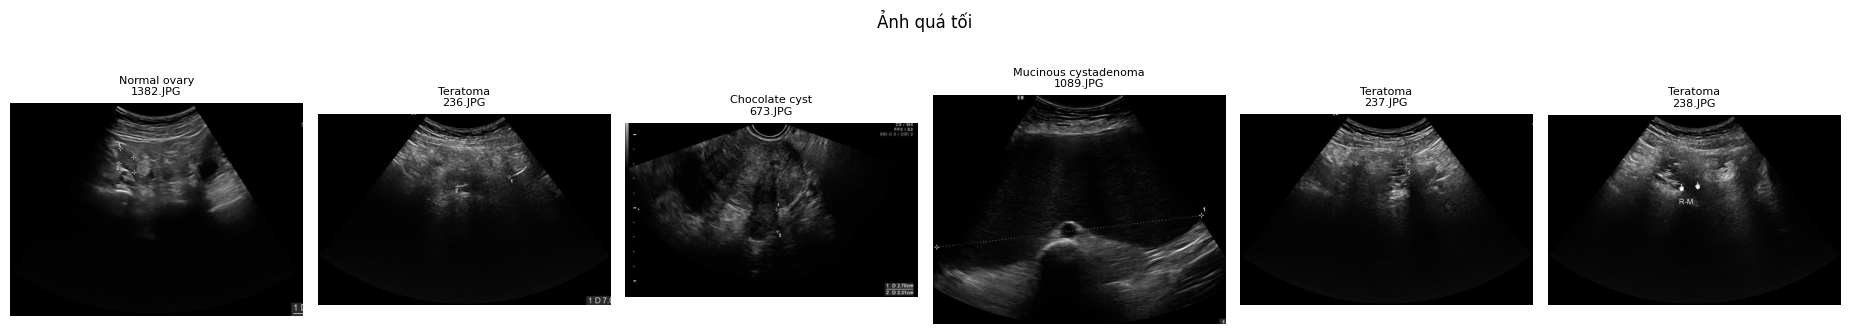

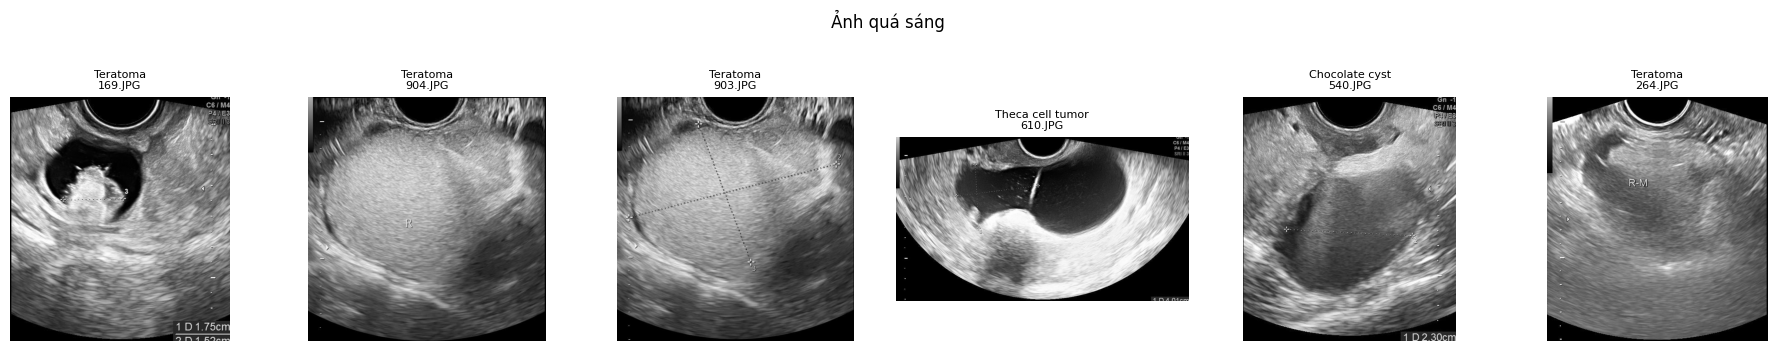

In [22]:
def show_outlier_grid(sub_df, title, overlay_mask=False, n=6):
    sub_df = sub_df.head(n)
    if len(sub_df) == 0:
        print(f"{title}: không có mẫu.")
        return
    fig, axes = plt.subplots(1, len(sub_df), figsize=(3.1 * len(sub_df), 3.3))
    if len(sub_df) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, sub_df.iterrows()):
        img = load_gray(row["image_path"])
        ax.imshow(img, cmap="gray")
        if overlay_mask and row["has_mask"]:
            mask = load_mask(row["mask_path"], shape=img.shape)
            if mask is not None and mask.shape == img.shape:
                ax.imshow(np.ma.masked_where(mask == 0, mask), cmap="autumn", alpha=0.4)
        ax.set_title(f"{row['class_name']}\n{row['image_name']}", fontsize=8)
        ax.axis("off")
    plt.suptitle(title, y=1.05)
    plt.tight_layout()
    plt.show()

show_outlier_grid(feat_df[feat_df["outlier_size"]].sort_values("img_area"), "Ảnh kích thước bất thường (nhỏ nhất trước)")
show_outlier_grid(feat_df[feat_df["outlier_dark"]].sort_values("brightness_mean"), "Ảnh quá tối")
show_outlier_grid(feat_df[feat_df["outlier_bright"]].sort_values("brightness_mean", ascending=False), "Ảnh quá sáng")


## 2.11 Phân tích missing data

Đối chiếu file ảnh với file mask (`{stem}.PNG` hoặc `{stem}_binary.PNG`) trên tập **OTU_2d**.


In [23]:
missing_rows = []
subset_dir = DATA_ROOT / SUBSET_NAME
img_dir = subset_dir / "images"
ann_dir = subset_dir / "annotations"
images = {p.stem: p.name for p in img_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}}
masks = {p.stem.replace("_binary_binary", "").replace("_binary", ""): p.name for p in ann_dir.glob("*.PNG") if "_binary" not in p.stem}
binary_masks = {p.stem.replace("_binary", ""): p.name for p in ann_dir.glob("*_binary.PNG") if "_binary_binary" not in p.stem}

img_stems = set(images)
mask_stems = set(masks) | set(binary_masks)
only_img = sorted(img_stems - mask_stems)
only_mask = sorted(mask_stems - img_stems)
print(f"=== {subset_dir.name} ===")
print(f"  Ảnh: {len(img_stems)} | mask màu: {len(masks)} | mask binary: {len(binary_masks)}")
print(f"  Ảnh không có mask: {len(only_img)}")
print(f"  Mask không có ảnh: {len(only_mask)}")
if only_img[:10]:
    print("  Ví dụ ảnh thiếu mask:", only_img[:10])
if only_mask[:10]:
    print("  Ví dụ mask thiếu ảnh:", only_mask[:10])
for stem in only_img:
    missing_rows.append({"subset": subset_dir.name, "stem": stem, "issue": "missing_mask", "file": images[stem]})
for stem in only_mask:
    missing_rows.append({"subset": subset_dir.name, "stem": stem, "issue": "missing_image", "file": masks.get(stem) or binary_masks.get(stem)})

missing_df = pd.DataFrame(missing_rows)
print("\nTổng issue:", len(missing_df))
if len(missing_df):
    print(missing_df.groupby(["subset", "issue"]).size())
else:
    print("Không phát hiện ảnh thiếu mask hoặc mask mồ côi.")

print("\nTrong dataframe nhãn:")
print("  has_mask = False:", int((~df["has_mask"]).sum()))
print("  empty_mask:", int(feat_df["ann_empty"].sum()) if "ann_empty" in feat_df.columns else "n/a")
print("  size_mismatch:", int(feat_df["ann_size_mismatch"].sum()) if "ann_size_mismatch" in feat_df.columns else "n/a")


=== OTU_2d ===
  Ảnh: 1469 | mask màu: 1469 | mask binary: 1469
  Ảnh không có mask: 0
  Mask không có ảnh: 0

Tổng issue: 0
Không phát hiện ảnh thiếu mask hoặc mask mồ côi.

Trong dataframe nhãn:
  has_mask = False: 0
  empty_mask: 0
  size_mismatch: 0


### Nhận xét

- Không có giá trị thiếu ở bất kỳ cột đặc trưng nào trên 1469 ảnh OTU_2d.
- Ảnh và mask khớp nhau hoàn toàn, không ảnh nào bị loại ở bước làm sạch.

**Kết luận:** Không cần chiến lược điền khuyết. `SimpleImputer(strategy="median")` ở mục 3.4 chỉ giữ như lớp phòng vệ cho trường hợp chạy lại trên tập dữ liệu khác.


## Tóm tắt đặc trưng đã trích xuất

Từ mỗi ảnh (và mask nếu có), notebook ghi vào `feat_df` các nhóm dưới đây; **2.12** lưu ra `mmotu_feature_summary.csv`.

**1. Định danh mẫu**
- Tên ảnh, nhãn lớp (`label` / `class_name`), subset (`OTU_2d`), split (train/val), đường dẫn ảnh–mask, `has_mask`

**2. Kích thước**
- `img_h`, `img_w`, `n_pixels`
- `mask_resized`: mask có bị lệch kích thước so với ảnh không

**3. Chất lượng ảnh (2.5)** — toàn ảnh xám, **không cần mask → đây là 13 cột dùng cho baseline mục 3.5**
- Độ sáng: `brightness_mean`, `brightness_std`
- Tương phản: `rms_contrast`, `michelson_contrast`, `dynamic_range`, `intensity_min` / `intensity_max`
- `hist_entropy`, SNR (`snr`, `snr_db`), độ nét `sharpness`, `skewness`, `kurtosis`

**4. Hình thái annotation (2.6)** — mask nhị phân, chỉ dùng cho EDA
- Diện tích tổn thương: `tumor_area_px`, `tumor_area_ratio`
- Hộp bao: `bbox_h`, `bbox_w`, `aspect_ratio`
- Hình dạng: `circularity`, `solidity`, `eccentricity`
- `n_lesions`, `empty_mask`, `size_mismatch`

**5. Cường độ trên ROI (2.7)** — pixel trong mask, chỉ dùng cho EDA
- `roi_mean`, `roi_std`, `roi_skewness`, `roi_kurtosis`, `roi_min`, `roi_max`, `roi_dynamic_range`

**6. Texture (2.8)** — ROI resize 128×128, chỉ dùng cho EDA
- **GLCM:** `glcm_contrast`, `glcm_correlation`, `glcm_energy`, `glcm_homogeneity`
- **LBP:** `lbp_entropy`, `lbp_energy` và histogram 11 bin (`lbp_bin_0` … `lbp_bin_10`)
- **Gabor:** `gabor_energy_mean`, `gabor_energy_std` và 8 bộ lọc hướng–tần số (`gabor_e_0` … `gabor_e_7`)


## 2.12 Lưu lại file thành CSV


In [24]:
out_cols = [c for c in [
    "image_name", "label", "class_name", "subset", "split",
    "image_path", "mask_path", "has_mask", "label_name",
] if c in df.columns]
df[out_cols].to_csv(OUTPUT_DIR / "mmotu_dataset_summary.csv", index=False)

drop_eda = [c for c in feat_df.columns if c.startswith("outlier_") or c.startswith("ann_")]
if "img_area" in feat_df.columns:
    drop_eda.append("img_area")
feat_export = feat_df.drop(columns=drop_eda, errors="ignore")
feat_export.to_csv(OUTPUT_DIR / "mmotu_feature_summary.csv", index=False)

if len(missing_df):
    missing_df.to_csv(OUTPUT_DIR / "mmotu_missing_data.csv", index=False)
print("Đã lưu: mmotu_dataset_summary.csv")
print("Đã lưu: mmotu_feature_summary.csv")
print("Số cột đặc trưng:", feat_export.shape[1])
print(df[out_cols].head())


Đã lưu: mmotu_dataset_summary.csv
Đã lưu: mmotu_feature_summary.csv
Số cột đặc trưng: 76
  image_name  label          class_name  subset  split  \
0    658.JPG      5        Normal ovary  OTU_2d  train   
1    384.JPG      3    Theca cell tumor  OTU_2d  train   
2    367.JPG      3    Theca cell tumor  OTU_2d  train   
3    730.JPG      1  Serous cystadenoma  OTU_2d  train   
4   1426.JPG      7   High grade serous  OTU_2d  train   

                                          image_path  \
0  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...   
1  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...   
2  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...   
3  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...   
4  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...   

                                           mask_path  has_mask  \
0  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...      True   
1  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...      True   
2  /content/drive/MyDrive/T

# 3. Tiền xử lý dữ liệu

Theo các kết quả:
+ Mục 2.5: Số mẫu lỗi bằng 0, dữ liệu sạch -> không cần loại ảnh nào.
+ Mục 2.10: Tỷ lệ outlier quá nhỏ, không cần loại.
+ Mục 2.11: Không phát hiện ảnh thiếu mask hoặc mask mồ côi.
>=> **Không cần thực hiện loại bỏ mẫu nào**

Chuẩn bị dữ liệu: giữ ảnh raw, random resize rồi crop 384×384.

- 3.1 Tách tập dữ liệu từ OTU_2d 1469 thành tập train và test, không có tập val, patient-disjoint (không trùng lặp bệnh nhân giữa tập train và test).
- 3.2 Đọc ảnh gốc và minh họa Resize + RandomCrop + RandomFlip khi train
- 3.3 Cache ảnh RGB gốc `cache/otu2d_rgb_orig.pkl` cho mục 5
- 3.4 Trích xuất đặc trưng thủ công `image_only` (fit trên 1000 ảnh train)
- 3.5 Baseline `LogisticRegression` trên đặc trưng thủ công — mốc đối chiếu, không kỳ vọng thắng CNN


## 3.1 Tách tập dataset

- Chia OTU_2d thành **1000 ảnh train / 171 bệnh nhân** và **469 ảnh test / 76 bệnh nhân**. Dựa vào 2 file `train_cls.txt` và `val_cls.txt` .
- Thêm cột `split_paper` chỉ có 2 giá trị:
  - `train` = 1000 ảnh từ `train_cls.txt` → dùng để huấn luyện.
  - `test` = 469 ảnh từ `val_cls.txt` → dùng để **đánh giá model** ở mục 5.4.
- **Vì sao không tách tập val?** Nếu chia 1000 ảnh từ tập train làm tập val thì số ảnh train giảm, còn nếu lấy test 469 làm val thì sẽ bị data leakage (rò rỉ thông tin). Nhóm chọn cách tốt hơn: **chốt trước số epoch cố định (60), không early-stopping, không dùng test để chọn bất cứ tham số nào**, lưu checkpoint ở epoch cuối. Ngoài ra, Dataset public **không có `patient_id`**, nên không thể tự chia lại theo bệnh nhân, chỉ có thể chia từ 2 file `train_cls.txt và val_cls.txt`
- **Hệ quả:** không có đường cong val để phát hiện **overfitting trong lúc train**. Bù lại bằng đường cong train loss và phân tích confusion matrix ở mục 5.4.
- Lưu kết quả chia tập vào file `mmotu_splits.csv`.


===== split_paper =====
Số mẫu: {'train': 1000, 'test': 469} — khớp 1000 / 469
Theo lớp:
label          0    1    2   3   4    5   6   7
split_paper                                    
train        226  153  228  57  47  180  71  38
test         110   66  108  31  19   87  33  15
Không có tập val: số epoch chốt cố định, không early-stopping, test chỉ chấm 1 lần ở mục 5.4.


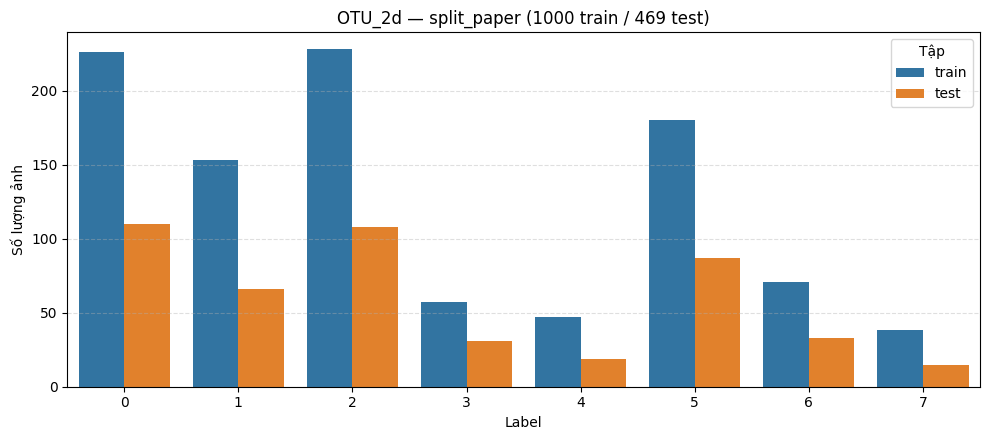

Đã lưu: /content/drive/MyDrive/TL_OvarianTumor_Ultrasound/outputs/mmotu_splits.csv
  image_name  label  subset split_official split_paper
0    658.JPG      5  OTU_2d          train       train
1    384.JPG      3  OTU_2d          train       train
2    367.JPG      3  OTU_2d          train       train
3    730.JPG      1  OTU_2d          train       train
4   1426.JPG      7  OTU_2d          train       train
df_clean: 1469 mẫu


In [27]:
RANDOM_STATE = 42


def load_mmotu_dataframe():
    summary_path = OUTPUT_DIR / "mmotu_dataset_summary.csv"
    if summary_path.exists():
        loaded = pd.read_csv(summary_path)
        loaded = loaded[loaded["subset"] == "OTU_2d"].reset_index(drop=True)
        print(f"Đã đọc {len(loaded)} mẫu OTU_2d từ {summary_path}")
        return loaded

    data_root = DATA_ROOT
    subset = data_root / "OTU_2d"
    img_dir = subset / "images"
    rows = []
    for split_name in ["train", "val"]:
        label_file = subset / f"{split_name}_cls.txt"
        if not label_file.exists():
            continue
        with open(label_file, "r", encoding="utf-8") as fh:
            for line in fh:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                if len(parts) < 2:
                    continue
                rows.append({
                    "image_name": parts[0],
                    "label": int(parts[1]),
                    "subset": "OTU_2d",
                    "split": split_name,
                    "image_path": str(img_dir / parts[0]),
                })
    loaded = pd.DataFrame(rows)
    print(f"Đã dựng {len(loaded)} mẫu OTU_2d từ {data_root}")
    return loaded


if "df" not in globals() or not isinstance(df, pd.DataFrame):
    df = load_mmotu_dataframe()

if "subset" in df.columns:
    df = df[df["subset"] == "OTU_2d"].reset_index(drop=True)

if "split" in df.columns and "split_official" not in df.columns:
    df = df.rename(columns={"split": "split_official"})


def assign_paper_split(df_part):
    """Split đúng bài báo: train = train_cls.txt (1000), test = val_cls.txt (469). Không có val."""
    out = pd.Series(index=df_part.index, dtype="object")
    is_test = df_part["split_official"].astype(str).str.lower().isin(["val", "test"])
    out.loc[is_test] = "test"
    out.loc[~is_test] = "train"
    return out


df["split_paper"] = assign_paper_split(df)
sets_o = {s: set(df.index[df["split_paper"] == s]) for s in ["train", "test"]}
assert sets_o["train"].isdisjoint(sets_o["test"]), "train và test bị chồng nhau"
assert sum(len(v) for v in sets_o.values()) == len(df), "có ảnh không được gán split"
assert len(sets_o["train"]) == 1000, f"train phải 1000 ảnh, đang {len(sets_o['train'])}"
assert len(sets_o["test"]) == 469, f"test phải 469 ảnh, đang {len(sets_o['test'])}"
print("===== split_paper =====")
print("Số mẫu:", {s: len(sets_o[s]) for s in ["train", "test"]}, "— khớp 1000 / 469")
print("Theo lớp:")
print(df.groupby(["split_paper", "label"]).size().unstack(fill_value=0).reindex(["train", "test"]))
print("Không có tập val: số epoch chốt cố định, không early-stopping, test chỉ chấm 1 lần ở mục 5.4.")

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.countplot(
    data=df,
    x="label",
    hue="split_paper",
    hue_order=["train", "test"],
    ax=ax,
)
ax.set_title("OTU_2d — split_paper (1000 train / 469 test)")
ax.set_xlabel("Label")
ax.set_ylabel("Số lượng ảnh")
ax.legend(title="Tập")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

split_cols = [
    "image_name",
    "label",
    "subset",
    "split_official",
    "split_paper",
]
split_path = OUTPUT_DIR / "mmotu_splits.csv"
df[split_cols].to_csv(split_path, index=False, encoding="utf-8-sig")
print("Đã lưu:", split_path)
print(df[split_cols].head())

# Mục 2.5, 2.10, 2.11: không có mẫu nào cần loại nên df_clean giữ toàn bộ OTU_2d
df_clean = df.copy()
print("df_clean:", len(df_clean), "mẫu")


## Nhận xét
Sau khi chia tập, ta thấy số mẫu train và test trong các lớp không đều. Lớp 3, 4, 6, 7 ít mẫu hơn so với các lớp 0, 1, 2, 5. Điều này cho thấy dataset đã bị mất cân bằng lớp sẵn và accuracy tổng của mô hình train ở mục 5 dễ bị kéo lên bởi các lớp nhiều mẫu.

## 3.2 Đọc ảnh gốc và minh họa Resize + RandomCrop + RandomFlip khi train

Ở bước này, nhóm giữ nguyên ảnh raw. Lúc train: Resize giữ tỉ lệ → RandomCrop 384×384 → **RandomFlip** (minh họa ở cột 3).
+ Áp dụng kỹ thuật **RandomHorizontalFlip**
+ Cạnh dài của ảnh resize về 448px với tỉ lệ dãn/co ngẫu nhiên. Công thức: **`Resize(img_scale=(448,448), ratio_range=(0.5, 2.0), keep_ratio)`**. Sau đó mới crop ảnh thành 384px **`RandomCrop(384)`**. Điều này giúp tránh việc crop trượt khỏi vùng tổn thương hoặc tạo ra khoảng trống viền đen không cần thiết.

Lý do **giữ ảnh raw thay vì xóa ký hiệu hay biến đổi tương phản nhân tạo (chuẩn hóa dữ liệu)**:
+ Tránh làm sai lệch phân phối dữ liệu ngầm -Theo kết quả bài báo, việc dùng kỹ thuật để xóa ký hiệu của các mô hình đều bị giảm hiệu năng.
+ Bảo toàn thông tin màu sắc quan trọng (CDFI) - Do có 216 ảnh siêu âm Doppler màu nên cần giữ nguyên ảnh RGB raw giúp bảo toàn thông tin.
+ Ký hiệu không làm mất đi các đặc trưng thị giác cốt lõi - Theo kết quả bài báo, các ký hiệu có ít tác động đến các đặc điểm trực quan của ảnh.



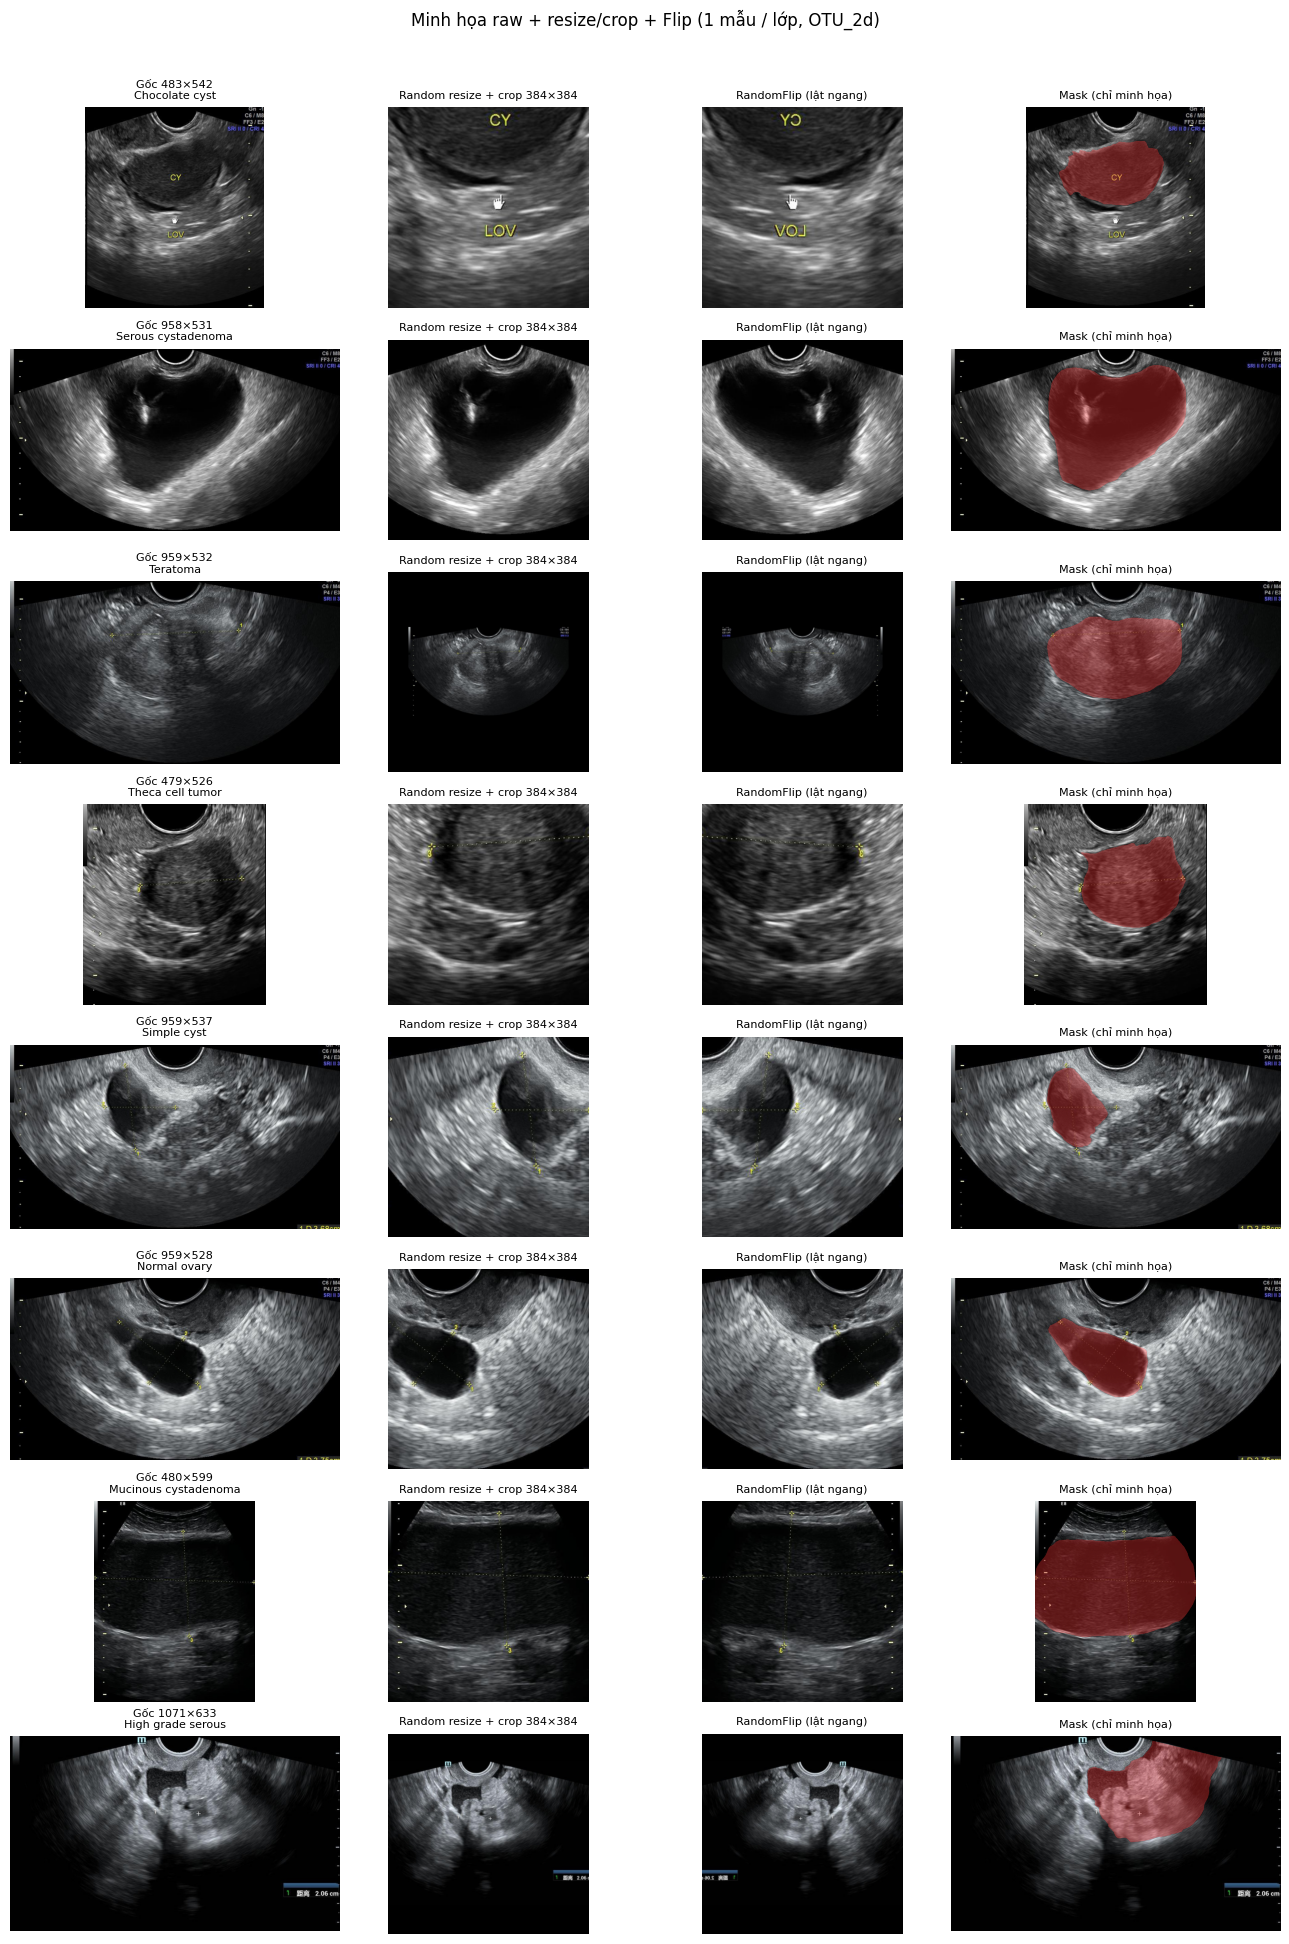

Hàm sẵn sàng: preprocess_image (ảnh gốc), random_resize_and_crop_np (crop 384 lúc train).
Train: cạnh dài → 448×ratio (0.5–2.0) → crop 384 → RandomFlip — không nhân H×W gốc.


In [28]:
from skimage.transform import resize as sk_resize

IMG_SIZE = 384                 # RandomCrop lúc train
IMG_SCALE = 448                # mmotu.py img_scale
RATIO_RANGE = (0.5, 2.0)       # mmotu.py ratio_range


def preprocess_image(path):
    """Đọc RGB gốc. Không pad, không CLAHE, không resize cứng."""
    with Image.open(path) as im:
        img = np.array(im.convert("RGB"), dtype=np.uint8)
    return img, img.shape[:2]


def preprocess_mask(path, orig_hw=None):
    """Chỉ dùng để minh họa/EDA. Task 3 không dùng mask khi train hay suy luận."""
    with Image.open(path) as im:
        mask = np.array(im)
    if mask.ndim == 3:
        mask = mask.max(axis=2)
    mask = mask.astype(np.float32)
    if orig_hw is not None and tuple(mask.shape[:2]) != tuple(orig_hw):
        mask = sk_resize(mask, orig_hw, order=0, anti_aliasing=False, preserve_range=True)
    return (mask > 0).astype(np.uint8)


def random_resize_np(img, rng, ratio_range=RATIO_RANGE, img_scale=IMG_SCALE):
    """MMSeg: Resize(img_scale=(448,448), ratio_range, keep_ratio) — cạnh dài → 448×ratio."""
    h, w = img.shape[:2]
    ratio = float(rng.uniform(*ratio_range))
    box = max(1, int(round(img_scale * ratio)))
    scale = box / max(h, w, 1)
    new_h = max(1, int(round(h * scale)))
    new_w = max(1, int(round(w * scale)))
    out = sk_resize(img, (new_h, new_w), order=1, anti_aliasing=True, preserve_range=True)
    return np.clip(np.rint(out), 0, 255).astype(np.uint8)


def pad_to_min_np(img, size):
    h, w = img.shape[:2]
    pad_h, pad_w = max(0, size - h), max(0, size - w)
    if pad_h == 0 and pad_w == 0:
        return img
    top, left = pad_h // 2, pad_w // 2
    canvas = np.zeros((h + pad_h, w + pad_w) + img.shape[2:], dtype=img.dtype)
    canvas[top : top + h, left : left + w] = img
    return canvas


def random_crop_np(img, size, rng):
    img = pad_to_min_np(img, size)
    h, w = img.shape[:2]
    top = int(rng.integers(0, h - size + 1))
    left = int(rng.integers(0, w - size + 1))
    return img[top : top + size, left : left + size]


def random_resize_and_crop_np(img, rng, size=IMG_SIZE):
    """mmotu.py: Resize(448)×(0.5–2.0) → RandomCrop(384)."""
    return random_crop_np(random_resize_np(img, rng), size, rng)


names = CLASS_NAMES if "CLASS_NAMES" in globals() else {i: f"Class {i}" for i in range(8)}
samples = (
    df_clean[df_clean["subset"] == "OTU_2d"]
    .sort_values(["label", "image_name"])
    .groupby("label", group_keys=False)
    .head(1)
)
n = len(samples)
fig, axes = plt.subplots(n, 4, figsize=(13, 2.4 * n))
if n == 1:
    axes = np.array([axes])

for ax_row, (_, row) in zip(axes, samples.iterrows()):
    orig, orig_hw = preprocess_image(row["image_path"])
    rng = np.random.default_rng(42 + int(row["label"]))
    crop384 = random_resize_and_crop_np(orig, rng, size=IMG_SIZE)
    flipped = np.ascontiguousarray(crop384[:, ::-1])
    mask = None
    if pd.notna(row.get("mask_path")) and Path(str(row["mask_path"])).exists():
        mask = preprocess_mask(row["mask_path"], orig_hw=orig_hw)

    ax_row[0].imshow(orig)
    ax_row[0].set_title(
        f"Gốc {orig.shape[1]}×{orig.shape[0]}\n{names.get(int(row['label']), row['label'])}",
        fontsize=8,
    )
    ax_row[1].imshow(crop384)
    ax_row[1].set_title(f"Random resize + crop {IMG_SIZE}×{IMG_SIZE}", fontsize=8)
    ax_row[2].imshow(flipped)
    ax_row[2].set_title("RandomFlip (lật ngang)", fontsize=8)
    ax_row[3].imshow(orig)
    if mask is not None:
        overlay = np.zeros((*mask.shape, 4), dtype=np.float32)
        overlay[mask > 0] = (1.0, 0.2, 0.2, 0.35)
        ax_row[3].imshow(overlay)
    ax_row[3].set_title("Mask (chỉ minh họa)", fontsize=8)
    for ax in ax_row:
        ax.axis("off")

plt.suptitle("Minh họa raw + resize/crop + Flip (1 mẫu / lớp, OTU_2d)", y=1.01)
plt.tight_layout()
plt.show()
print("Hàm sẵn sàng: preprocess_image (ảnh gốc), random_resize_and_crop_np (crop 384 lúc train).")
print("Train: cạnh dài → 448×ratio (0.5–2.0) → crop 384 → RandomFlip — không nhân H×W gốc.")


## 3.3 Cache ảnh RGB gốc

Đọc 1000 ảnh JPEG mỗi epoch từ Google Drive rất chậm. Cell này chạy **một lần**, ghi:

- `cache/otu2d_rgb_orig.pkl` — list 1469 mảng `uint8` `(H, W, 3)` **kích thước gốc khác nhau**
- `cache/otu2d_index.csv` — nhãn + `split_official` / `split_paper`, **cùng thứ tự** với list trên

Lần sau chỉ **nạp file** (hoặc dùng luôn biến trong RAM). Đặt `FORCE_REBUILD_CACHE = True` mới sinh lại từ JPEG.


In [29]:
import pickle
from tqdm.auto import tqdm

if "CACHE_DIR" not in globals():
    raise RuntimeError("Chạy mục 0 trước (CACHE_DIR / OUTPUT_DIR).")
if "df_clean" not in globals() or "preprocess_image" not in globals():
    raise RuntimeError("Chạy mục 3.1–3.2 trước để có df_clean và preprocess_image.")

FORCE_REBUILD_CACHE = False  # True chỉ khi muốn đọc lại toàn bộ JPEG

CACHE_PKL = CACHE_DIR / "otu2d_rgb_orig.pkl"
CACHE_CSV = CACHE_DIR / "otu2d_index.csv"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

index_df = (
    df_clean[df_clean["subset"] == "OTU_2d"]
    .sort_values("image_name")
    .reset_index(drop=True)
    .copy()
)
need_cols = ["image_name", "label", "class_name", "split_official", "split_paper", "image_path"]
missing = [c for c in need_cols if c not in index_df.columns]
if missing:
    raise KeyError(f"df_clean thiếu cột: {missing}")


def _name_list(series):
    return [str(x).strip() for x in series]


save_cols = ["image_name", "label", "class_name", "split_official", "split_paper"]
n_expect = len(index_df)
reuse = False

already = globals().get("images_u8")
if (
    not FORCE_REBUILD_CACHE
    and isinstance(already, list)
    and len(already) == n_expect
    and getattr(already[0], "ndim", 0) == 3
):
    images_u8 = already
    reuse = True
    print(f"Dùng {n_expect} ảnh đã có trong RAM — không đọc file, không sinh lại.")
elif CACHE_PKL.exists() and not FORCE_REBUILD_CACHE:
    if CACHE_CSV.exists():
        cached_names = _name_list(pd.read_csv(CACHE_CSV)["image_name"])
        if cached_names != _name_list(index_df["image_name"]):
            print(
                "Cảnh báo: thứ tự/tên trong CSV lệch df_clean; vẫn nạp pkl. "
                "Đặt FORCE_REBUILD_CACHE=True nếu muốn sinh lại."
            )
    print(f"Nạp cache có sẵn {CACHE_PKL.name} (không đọc JPEG)...")
    with CACHE_PKL.open("rb") as f:
        images_u8 = pickle.load(f)
    if not isinstance(images_u8, list) or len(images_u8) != n_expect:
        print(f"Cache không khớp số ảnh ({len(images_u8) if isinstance(images_u8, list) else type(images_u8)} vs {n_expect}) — sinh lại.")
        reuse = False
    else:
        reuse = True
        print(f"Đã nạp {n_expect} ảnh từ disk.")
else:
    if FORCE_REBUILD_CACHE:
        print("FORCE_REBUILD_CACHE=True — sinh lại từ JPEG.")
    elif not CACHE_PKL.exists():
        print(f"Chưa có {CACHE_PKL.name} — sinh cache lần đầu.")

if not reuse:
    print(f"Tạo cache ảnh gốc cho {n_expect} ảnh RGB → {CACHE_PKL}")
    images_u8 = []
    for _, row in tqdm(index_df.iterrows(), total=n_expect, desc="preprocess"):
        img, _ = preprocess_image(row["image_path"])
        images_u8.append(img)
    with CACHE_PKL.open("wb") as f:
        pickle.dump(images_u8, f, protocol=4)

if (not CACHE_CSV.exists()) or FORCE_REBUILD_CACHE or not reuse:
    index_df[save_cols].to_csv(CACHE_CSV, index=False)

assert isinstance(images_u8, list) and len(images_u8) == n_expect
assert images_u8[0].dtype == np.uint8 and images_u8[0].ndim == 3 and images_u8[0].shape[2] == 3
assert images_u8[-1].dtype == np.uint8 and images_u8[-1].ndim == 3

hs = [im.shape[0] for im in images_u8]
ws = [im.shape[1] for im in images_u8]
nbytes = sum(im.nbytes for im in images_u8)
print(f"N={n_expect}  RAM≈{nbytes / 1e6:.0f} MB  file={CACHE_PKL.stat().st_size / 1e6:.1f} MB")
print(f"Kích thước gốc: H {min(hs)}–{max(hs)}, W {min(ws)}–{max(ws)}")
if reuse:
    print("Bỏ qua đối chiếu JPEG (cache đã có). Đặt FORCE_REBUILD_CACHE=True nếu nghi cache hỏng.")
else:
    rng = np.random.default_rng(42)
    ri = int(rng.integers(n_expect))
    direct, _ = preprocess_image(index_df.loc[ri, "image_path"])
    max_diff = int(np.max(np.abs(direct.astype(np.int16) - images_u8[ri].astype(np.int16))))
    print(f"Đối chiếu mẫu {index_df.loc[ri, 'image_name']}: max |preprocess - cache| = {max_diff} (kỳ vọng 0)")
    if max_diff != 0:
        raise AssertionError("Cache lệch preprocess_image — kiểm tra thứ tự image_name.")
print("Cache RGB gốc sẵn sàng cho mục 5.")


Chưa có otu2d_rgb_orig.pkl — sinh cache lần đầu.
Tạo cache ảnh gốc cho 1469 ảnh RGB → /content/drive/MyDrive/TL_OvarianTumor_Ultrasound/cache/otu2d_rgb_orig.pkl


preprocess:   0%|          | 0/1469 [00:00<?, ?it/s]

N=1469  RAM≈1861 MB  file=1860.7 MB
Kích thước gốc: H 266–794, W 302–1135
Đối chiếu mẫu 1116.JPG: max |preprocess - cache| = 0 (kỳ vọng 0)
Cache RGB gốc sẵn sàng cho mục 5.


## 3.4 Trích xuất đặc trưng thủ công (fit trên train)

Mục 2 đã tính 60 đặc trưng thủ công cho từng ảnh và lưu ở `outputs/mmotu_feature_summary.csv`. Mục này biến bảng đó thành **ma trận đặc trưng dùng được cho mô hình**, với đúng một nguyên tắc: mọi thống kê biến đổi (median, quantile của scaler, phương sai, tương quan, mutual information) đều **fit trên 1000 ảnh `train` của cột `split_paper`**; `test` chỉ được `transform`.

> **Baseline mục 3.5: chỉ view `image_only` (13 cột, không cần mask).**
> Các nhóm mask (`roi_*`, shape, texture ROI) **không** vào ResNet-50 mục 5.3–5.4.

Loại khỏi view: `img_h`, `img_w`, `n_pixels`, `mask_h`, `mask_w`, `mask_resized`, `size_mismatch`, `empty_mask`, `has_mask` — đây là metadata kích thước/thiết bị, mô hình dễ học thành shortcut thay vì học bệnh học.

**Các bước biến đổi 13 cột cường độ toàn ảnh thành ma trận số cho baseline LogisticRegression ở mục 3.5. fit từ 1000 ảnh train:**

1. Chốt danh sách cột còn dùng được: `select_stable_columns` — impute + scale trên train để chốt danh sách cột: bỏ cột gần hằng số (phương sai ~ 0), bỏ cột có `|Pearson r| > 0.95` với một cột đã giữ (ví dụ `snr` gần như nghịch đảo `rms_contrast`). Ma trận tương quan tính **chỉ trên train**.
2. `SimpleImputer(strategy="median")` — điền giá trị NaN nếu có giá trị rỗng.
3. `RobustScaler()` — dùng median/IQR thay vì mean/std vì mục 2.10 cho thấy có outlier sáng/tối.
4. `SelectKBest(mutual_info_classif)` với `k="all"` — giữ toàn bộ cột ổn định ở B1, không quét siêu tham số.

Kết quả ghi ra `cache/otu2d_feat_image_only.npz` và `cache/feat_pipeline_image_only.joblib`, nạp lại được ở kernel mới.


Nguồn đặc trưng: biến feat_df trong bộ nhớ (mục 2.5)
  1469 hàng OTU_2d, 88 cột
Thứ tự hàng: biến index_df của mục 3.3

N = 1469  |  train=1000  test=469
image_name của train và test không giao nhau — OK
Loại khỏi mô hình (metadata): img_h, img_w, n_pixels, mask_h, mask_w, mask_resized, size_mismatch, empty_mask, has_mask
Loại khỏi baseline 3.5 (phụ thuộc GT mask, 43 cột): tumor_area_px, tumor_area_ratio, bbox_h, bbox_w, aspect_ratio, circularity ...

===== view = image_only (không cần mask) =====
  cột vào: 13 → sau lọc phương sai: 11 → sau prune |r|>0.95: 9 → sau SelectKBest: 9
  bỏ do phương sai ~ 0: michelson_contrast, intensity_min
  bỏ do tương quan cao: snr_db, intensity_max
  GIỮ LẠI: brightness_mean, brightness_std, rms_contrast, hist_entropy, snr, sharpness, dynamic_range, skewness, kurtosis
  Thống kê sau transform, tính trên từng cột rồi lấy trung bình
  (train phải ~0 vì RobustScaler fit trên train; test lệch khỏi 0):
    train n=1000  mean|median cột| = 0.0000  mean IQR c

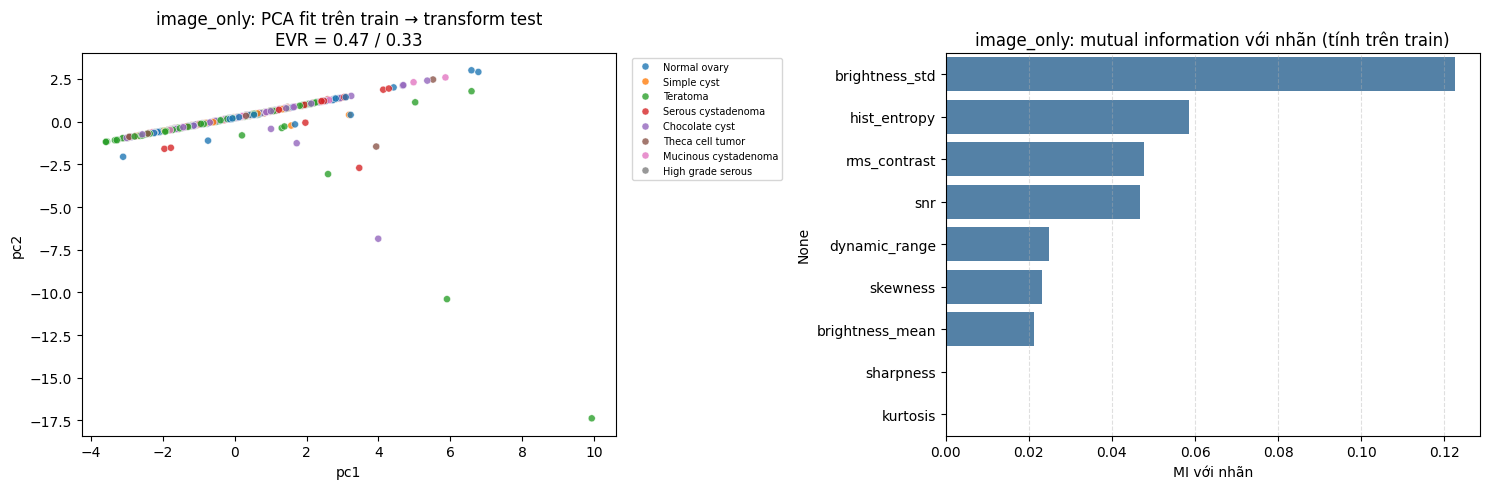

Đặc trưng có MI cao nhất: brightness_std, hist_entropy, rms_contrast, snr, dynamic_range


In [30]:
from functools import partial

import joblib
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

FEAT_SPLIT_COL = "split_paper"
FEAT_SEED = 42

# ---- Nhóm đặc trưng ---------------------------------------------------------
# Chỉ những đặc trưng tính được từ ảnh nguyên, KHÔNG cần mask lúc suy luận.
FEAT_IMAGE_ONLY = [
    "brightness_mean", "brightness_std", "rms_contrast", "michelson_contrast",
    "hist_entropy", "snr", "snr_db", "sharpness",
    "dynamic_range", "intensity_min", "intensity_max", "skewness", "kurtosis",
]
# Đặc trưng phụ thuộc GT mask — CỐ TÌNH không dùng cho mô hình (Task 3 chỉ có nhãn
# global-wise; lúc suy luận không có mask). Liệt kê ở đây để ghi nhận và đối chiếu
# với phần phân tích ở mục 2.6-2.8.
FEAT_MASK_DEPENDENT_NOT_USED = (
    ["tumor_area_px", "tumor_area_ratio", "bbox_h", "bbox_w", "aspect_ratio",
     "circularity", "solidity", "eccentricity", "n_lesions"]
    + ["roi_mean", "roi_std", "roi_skewness", "roi_kurtosis",
       "roi_min", "roi_max", "roi_dynamic_range"]
    + ["glcm_contrast", "glcm_correlation", "glcm_energy", "glcm_homogeneity"]
    + ["lbp_entropy", "lbp_energy"] + [f"lbp_bin_{i}" for i in range(11)]
    + ["gabor_energy_mean", "gabor_energy_std"] + [f"gabor_e_{i}" for i in range(8)]
)
# Metadata kích thước/thiết bị — cố tình KHÔNG đưa vào mô hình (nguy cơ shortcut)
FEAT_EXCLUDED = [
    "img_h", "img_w", "n_pixels", "mask_h", "mask_w",
    "mask_resized", "size_mismatch", "empty_mask", "has_mask",
]
FEAT_VIEWS = {"image_only": FEAT_IMAGE_ONLY}


# ---- Nạp bảng đặc trưng + căn hàng theo cache ảnh ---------------------------
def load_feature_table() -> pd.DataFrame:
    if (
        "feat_df" in globals()
        and isinstance(feat_df, pd.DataFrame)
        and "brightness_mean" in feat_df.columns
    ):
        src = feat_df.copy()
        print("Nguồn đặc trưng: biến feat_df trong bộ nhớ (mục 2.5)")
    else:
        path = OUTPUT_DIR / "mmotu_feature_summary.csv"
        if not path.exists():
            raise FileNotFoundError(f"Thiếu {path} — chạy mục 2.12 trước.")
        src = pd.read_csv(path)
        print("Nguồn đặc trưng:", path)
    src = src[src["subset"] == "OTU_2d"].reset_index(drop=True)
    print(f"  {len(src)} hàng OTU_2d, {src.shape[1]} cột")
    return src


def load_cache_order() -> pd.DataFrame:
    """Thứ tự hàng chuẩn = trục 0 của cache ảnh RGB (mục 3.3)."""
    if "index_df" in globals() and isinstance(index_df, pd.DataFrame) and "image_name" in index_df.columns:
        order = index_df.copy()
        print("Thứ tự hàng: biến index_df của mục 3.3")
    else:
        csv = CACHE_DIR / "otu2d_index.csv"
        if not csv.exists():
            raise FileNotFoundError(f"Thiếu {csv} — chạy mục 3.3 trước.")
        order = pd.read_csv(csv)
        print("Thứ tự hàng:", csv)
    if FEAT_SPLIT_COL not in order.columns:
        splits_path = OUTPUT_DIR / "mmotu_splits.csv"
        if not splits_path.exists():
            raise KeyError(f"Thiếu cột {FEAT_SPLIT_COL} và không thấy {splits_path} — chạy mục 3.1.")
        sp = pd.read_csv(splits_path)
        order = order.merge(sp[["image_name", FEAT_SPLIT_COL]], on="image_name", how="left")
        print("  đã merge cột split từ", splits_path.name)
    return order.reset_index(drop=True)


feat_src = load_feature_table()
feat_order = load_cache_order()

n_dup = int(feat_src["image_name"].duplicated().sum())
if n_dup:
    raise ValueError(f"{n_dup} image_name trùng trong bảng đặc trưng — không căn hàng được.")

feat_tbl = feat_src.set_index("image_name").reindex(feat_order["image_name"])
n_missing = int(feat_tbl["label"].isna().sum())
if n_missing:
    raise ValueError(f"{n_missing} ảnh trong cache không có đặc trưng — chạy lại mục 2.5.")

y_all = feat_order["label"].to_numpy(dtype=np.int64)
if not np.array_equal(y_all, feat_tbl["label"].to_numpy(dtype=np.int64)):
    raise ValueError("Nhãn trong bảng đặc trưng lệch nhãn trong cache index.")
split_all = feat_order[FEAT_SPLIT_COL].astype(str).to_numpy()
feat_names_all = feat_order["image_name"].astype(str).to_numpy()
N = len(feat_tbl)

# ---- Guardrail chống rò rỉ --------------------------------------------------
feat_masks = {s: (split_all == s) for s in ("train", "test")}
if int(sum(m.sum() for m in feat_masks.values())) != N:
    raise ValueError(f"Có hàng không thuộc train/test: {sorted(set(split_all))}")
name_sets = {s: set(feat_names_all[m]) for s, m in feat_masks.items()}
assert name_sets["train"].isdisjoint(name_sets["test"]), "train ∩ test ≠ ∅"
if "images_u8" in globals() and len(images_u8) != N:
    raise ValueError(f"Số hàng đặc trưng ({N}) khác số ảnh cache ({len(images_u8)}).")

print(f"\nN = {N}  |  " + "  ".join(f"{s}={int(m.sum())}" for s, m in feat_masks.items()))
print("image_name của train và test không giao nhau — OK")
print("Loại khỏi mô hình (metadata):", ", ".join(FEAT_EXCLUDED))
print(f"Loại khỏi baseline 3.5 (phụ thuộc GT mask, {len(FEAT_MASK_DEPENDENT_NOT_USED)} cột):",
      ", ".join(FEAT_MASK_DEPENDENT_NOT_USED[:6]), "...")


# ---- Chọn danh sách cột ổn định (quyết định CHỈ từ train) ------------------
def select_stable_columns(X_train, cols, var_thr: float = 1e-8, corr_thr: float = 0.95):
    """Bỏ cột gần hằng số, rồi bỏ cột có |Pearson r| > corr_thr với cột đã giữ."""
    pre = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", RobustScaler())])
    Z = pre.fit_transform(X_train)
    var_ok = Z.var(axis=0) > var_thr
    dropped_var = [c for c, ok in zip(cols, var_ok) if not ok]
    cols_var = [c for c, ok in zip(cols, var_ok) if ok]
    Z = Z[:, var_ok]
    with np.errstate(invalid="ignore", divide="ignore"):
        corr = np.nan_to_num(np.atleast_2d(np.corrcoef(Z, rowvar=False)))
    keep: list[int] = []
    for j in range(len(cols_var)):
        if all(abs(corr[j, k]) <= corr_thr for k in keep):
            keep.append(j)
    keep_set = set(keep)
    dropped_corr = [c for j, c in enumerate(cols_var) if j not in keep_set]
    return [cols_var[j] for j in keep], dropped_var, dropped_corr


def build_feature_pipeline(k="all", seed: int = FEAT_SEED) -> Pipeline:
    """Chỉ dùng estimator chuẩn của sklearn → joblib nạp lại được ở kernel mới."""
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
        ("select", SelectKBest(score_func=partial(mutual_info_classif, random_state=seed), k=k)),
    ])


def pipeline_feature_names(pipe: Pipeline, cols) -> list[str]:
    support = pipe.named_steps["select"].get_support()
    return [str(c) for c, ok in zip(cols, support) if ok]


# ---- Fit trên train, transform val/test ------------------------------------
HANDCRAFT: dict[str, dict] = {}
view_rows = []

for view, cols_req in FEAT_VIEWS.items():
    cols = [c for c in cols_req if c in feat_tbl.columns]
    if len(cols) != len(cols_req):
        print(f"\n[{view}] thiếu cột:", sorted(set(cols_req) - set(cols)))
    X_raw = feat_tbl[cols].to_numpy(dtype=np.float64)
    # SimpleImputer tự bỏ cột toàn NaN → bỏ trước để tên cột không bị lệch
    all_nan = np.isnan(X_raw[feat_masks["train"]]).all(axis=0)
    if all_nan.any():
        print(f"[{view}] bỏ cột toàn NaN trên train:", [cols[i] for i in np.flatnonzero(all_nan)])
        cols = [c for c, bad in zip(cols, all_nan) if not bad]
        X_raw = feat_tbl[cols].to_numpy(dtype=np.float64)

    # Bước 1: chốt danh sách cột từ train
    cols_keep, dropped_var, dropped_corr = select_stable_columns(X_raw[feat_masks["train"]], cols)
    X_sub = feat_tbl[cols_keep].to_numpy(dtype=np.float64)

    # Bước 2: fit pipeline trên train, val/test chỉ transform
    pipe = build_feature_pipeline()
    pipe.fit(X_sub[feat_masks["train"]], y_all[feat_masks["train"]])  # CHỈ train
    X_all = pipe.transform(X_sub)                                     # val/test chỉ transform
    kept = pipeline_feature_names(pipe, cols_keep)

    print(f"\n===== view = {view} (không cần mask) =====")
    print(f"  cột vào: {len(cols)} → sau lọc phương sai: {len(cols) - len(dropped_var)} "
          f"→ sau prune |r|>0.95: {len(cols_keep)} → sau SelectKBest: {len(kept)}")
    if dropped_var:
        print("  bỏ do phương sai ~ 0:", ", ".join(dropped_var))
    if dropped_corr:
        print("  bỏ do tương quan cao:", ", ".join(dropped_corr))
    print("  GIỮ LẠI:", ", ".join(kept))
    print("  Thống kê sau transform, tính trên từng cột rồi lấy trung bình")
    print("  (train phải ~0 vì RobustScaler fit trên train; test lệch khỏi 0):")
    for s, m in feat_masks.items():
        blk = X_all[m]
        print(
            f"    {s:5s} n={int(m.sum()):4d}  "
            f"mean|median cột| = {np.abs(np.median(blk, axis=0)).mean():.4f}  "
            f"mean IQR cột = {np.subtract(*np.percentile(blk, [75, 25], axis=0)).mean():.4f}"
        )

    HANDCRAFT[view] = {
        "X": X_all.astype(np.float32),
        "cols": kept,
        "cols_in": cols_keep,
        "pipeline": pipe,
        "split": split_all,
        "label": y_all,
        "image_name": feat_names_all,
        "masks": feat_masks,
        "needs_mask": False,
    }
    view_rows.append({
        "view": view,
        "n_in": len(cols),
        "n_after_prune": len(cols_keep),
        "n_out": len(kept),
        "needs_gt_mask": False,
        "features": ";".join(kept),
    })

    npz_path = CACHE_DIR / f"otu2d_feat_{view}.npz"
    np.savez_compressed(
        npz_path,
        X_all=X_all.astype(np.float32),
        feature_names=np.array(kept, dtype=object),
        label=y_all,
        split=split_all.astype(str),
        image_name=feat_names_all,
    )
    joblib.dump(
        {"pipeline": pipe, "cols_in": cols_keep, "cols_out": kept, "split_col": FEAT_SPLIT_COL},
        CACHE_DIR / f"feat_pipeline_{view}.joblib",
    )
    print(f"  đã lưu {npz_path.name} ({npz_path.stat().st_size / 1e3:.0f} KB) "
          f"và feat_pipeline_{view}.joblib")

pd.DataFrame(view_rows).to_csv(OUTPUT_DIR / "handcrafted_feature_views.csv", index=False)
print("\nĐã lưu:", OUTPUT_DIR / "handcrafted_feature_views.csv")
print("Biến sẵn sàng cho mục 3.5: HANDCRAFT['image_only']['X'] căn theo thứ tự cache ảnh.")

# ---- Trực quan: PCA fit trên train (khác cell 2.9 fit trên toàn bộ dữ liệu) --
feat_class_names = CLASS_NAMES if "CLASS_NAMES" in globals() else {i: f"Class {i}" for i in range(8)}
pack = HANDCRAFT["image_only"]
X, m = pack["X"], pack["masks"]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pca = PCA(n_components=2, random_state=FEAT_SEED).fit(X[m["train"]])  # CHỈ train
ev = pca.explained_variance_ratio_
xy_test = pca.transform(X[m["test"]])
scat = pd.DataFrame({
    "pc1": xy_test[:, 0],
    "pc2": xy_test[:, 1],
    "class_name": [feat_class_names.get(int(c), str(c)) for c in y_all[m["test"]]],
})
sns.scatterplot(data=scat, x="pc1", y="pc2", hue="class_name", s=26, alpha=0.8, ax=axes[0])
axes[0].set_title(f"image_only: PCA fit trên train → transform test\nEVR = {ev[0]:.2f} / {ev[1]:.2f}")
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)

mi = mutual_info_classif(X[m["train"]], y_all[m["train"]], random_state=FEAT_SEED)
mi_s = pd.Series(mi, index=pack["cols"]).sort_values(ascending=False)
sns.barplot(x=mi_s.values, y=mi_s.index, ax=axes[1], color="steelblue")
axes[1].set_title("image_only: mutual information với nhãn (tính trên train)")
axes[1].set_xlabel("MI với nhãn")
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()
print("Đặc trưng có MI cao nhất:", ", ".join(mi_s.head(5).index))


### Nhận xét

- **Đã trích:** 13 cột cường độ toàn ảnh (view `image_only`) — độ sáng, tương phản, entropy, SNR, độ nét, dải động, skewness, kurtosis.
- **Đã chọn:** danh sách in ở dòng `GIỮ LẠI` sau khi lọc hai bước trên **riêng 1000 ảnh train**: bỏ cột phương sai ~ 0 và bỏ cột có giá trị`|Pearson r| > 0.95` với cột đã giữ. `michelson_contrast` và `intensity_min` bị loại vì gần như mọi ảnh OTU_2d đều có pixel bằng 0 (viền đen máy siêu âm) nên hai chỉ số này là hằng số.
- **Kiểm tra rò rỉ:** assert `image_name` của train và test không giao nhau; bảng sau transform cho thấy `mean|median cột|` của train bằng 0 còn test khác 0 — nếu cả hai đều bằng 0 nghĩa là scaler đã đọc test và bị data leakage.
- Lưu file `otu2d_feat_image_only.npz` dùng cho baseline 3.5 nếu sử dụng kernel mới.

## 3.5 Baseline đặc trưng thủ công (mốc tham chiếu)

Baseline này dùng làm **mốc đối chiếu** với kết quả của ResNet-50 ở mục 5.4 với mục đích 13 cột intensity toàn cục so với ResNet-50 học đặc trưng từ dữ liệu. Đưa vào **một mô hình**: `Multinomial LogisticRegression` trên view `image_only` dùng để ước lượng độ ổn định (mean ± std macro-F1).

**Siêu tham số chốt trước, không tinh chỉnh:** `C=1.0`, `class_weight="balanced"`, `max_iter=2000`, dùng toàn bộ cột ổn định của mục 3.4. Do không có tập val (mục 3.1), mọi siêu tham số phải cố định từ đầu — không được dò bằng test 469.  

Metric: `accuracy` (top-1), `top-2`, `macro-F1`, `macro-AUC` → `runs/results_handcrafted.csv`.


view = image_only  |  d = 9 cột  |  train = 1000  test = 469
Đặc trưng dùng: brightness_mean, brightness_std, rms_contrast, hist_entropy, snr, sharpness, dynamic_range, skewness, kurtosis
Mô hình: LogisticRegression(C=1.0, class_weight='balanced') — cố định

----- 5-fold trên 1000 ảnh train (không đụng test 469) -----
  fold 1: acc=0.2000  macro-F1=0.1823
  fold 2: acc=0.1900  macro-F1=0.1764
  fold 3: acc=0.2350  macro-F1=0.2002
  fold 4: acc=0.2450  macro-F1=0.1931
  fold 5: acc=0.2000  macro-F1=0.1651
  → mean ± std: acc=0.2140  macro-F1=0.1834 ± 0.0123

----- Fit lại trên đủ 1000 ảnh train, chấm test 469 (1 lần) -----
  TEST  top1=0.2537  top2=0.4478  macro-F1=0.2235  macro-AUC=0.6595
                      precision    recall  f1-score   support

      Chocolate cyst      0.436     0.218     0.291       110
  Serous cystadenoma      0.376     0.485     0.424        66
            Teratoma      0.500     0.056     0.100       108
    Theca cell tumor      0.139     0.161     0.149  

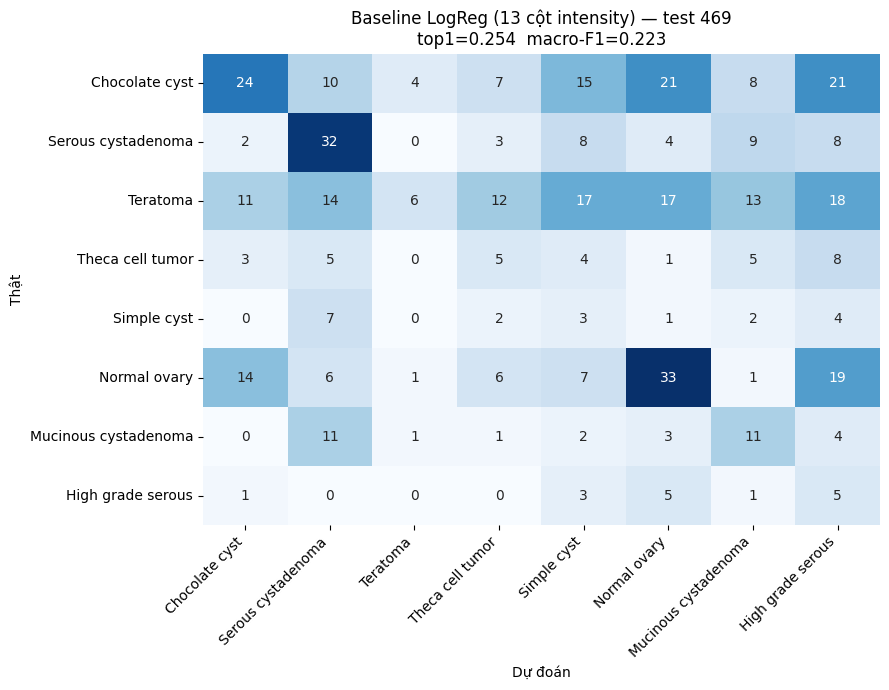


Kết quả baseline:
                       name           input_mode       split  model  n_train  n_test  n_features  cv5_acc_mean  cv5_macro_f1_mean  cv5_macro_f1_std  accuracy  top2_acc  macro_f1  weighted_f1  macro_auc  precision_macro  recall_macro  needs_gt_mask
handcraft_image_only_logreg handcraft_image_only split_paper logreg     1000     469           9         0.214           0.183439          0.012346  0.253731  0.447761  0.223468     0.256851   0.659486         0.271035      0.265468          False

Đã lưu: /content/drive/MyDrive/TL_OvarianTumor_Ultrasound/runs/results_handcrafted.csv
Mọi đặc trưng ở đây tính từ ảnh nguyên, không cần mask → so sánh được với mục 5.4.


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold

if "HANDCRAFT" not in globals():
    raise RuntimeError("Chạy mục 3.4 trước để có HANDCRAFT.")

FEAT_NUM_CLASSES = 8
feat_target_names = [feat_class_names.get(i, f"Class {i}") for i in range(FEAT_NUM_CLASSES)]
np.random.seed(FEAT_SEED)

# Siêu tham số CHỐT TRƯỚC — không có val nên không được dò (mục 3.1)
LOGREG_C = 1.0
LOGREG_MAX_ITER = 2000


# ---- Metric: đúng bộ của mục 5.4 -------------------------------------------
def feat_metrics(proba: np.ndarray, y_true: np.ndarray) -> dict:
    y_pred = proba.argmax(axis=1)
    p, r, _, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    top2 = np.argsort(proba, axis=1)[:, -2:]
    try:
        auc = float(roc_auc_score(
            y_true, proba, multi_class="ovr", average="macro",
            labels=np.arange(FEAT_NUM_CLASSES),
        ))
    except Exception as exc:  # thiếu lớp trong y_true
        print("  (macro-AUC bỏ qua:", exc, ")")
        auc = float("nan")
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "top2_acc": float(np.mean([y_true[i] in top2[i] for i in range(len(y_true))])),
        "macro_auc": auc,
        "precision_macro": float(p),
        "recall_macro": float(r),
        "y_pred": y_pred,
    }


def macro_f1_of(proba: np.ndarray, y_true: np.ndarray) -> float:
    return float(f1_score(y_true, proba.argmax(axis=1), average="macro", zero_division=0))


def expand_proba(classes, proba: np.ndarray) -> np.ndarray:
    """Đưa predict_proba về đủ 8 cột theo chỉ số lớp."""
    full = np.zeros((proba.shape[0], FEAT_NUM_CLASSES), dtype=np.float64)
    full[:, np.asarray(classes, dtype=int)] = proba
    return full


def fit_logreg(Xtr, ytr):
    clf = LogisticRegression(
        C=LOGREG_C, class_weight="balanced",
        max_iter=LOGREG_MAX_ITER, random_state=FEAT_SEED,
    )  # solver lbfgs -> multinomial (mặc định)
    clf.fit(Xtr, ytr)
    return clf


# ---- Bước 1: 5-fold trên 1000 ảnh train để ước lượng độ ổn định ------------
pack = HANDCRAFT["image_only"]
X = pack["X"].astype(np.float64)
m, cols = pack["masks"], pack["cols"]
ytr, yte = y_all[m["train"]], y_all[m["test"]]
Xtr, Xte = X[m["train"]], X[m["test"]]

print("=" * 72)
print(f"view = image_only  |  d = {len(cols)} cột  |  train = {len(ytr)}  test = {len(yte)}")
print("Đặc trưng dùng:", ", ".join(cols))
print(f"Mô hình: LogisticRegression(C={LOGREG_C}, class_weight='balanced') — cố định")

print("\n----- 5-fold trên 1000 ảnh train (không đụng test 469) -----")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=FEAT_SEED)
fold_f1, fold_acc = [], []
for fold, (tr_rel, va_rel) in enumerate(skf.split(Xtr, ytr), start=1):
    clf_f = fit_logreg(Xtr[tr_rel], ytr[tr_rel])
    pv = expand_proba(clf_f.classes_, clf_f.predict_proba(Xtr[va_rel]))
    f1 = macro_f1_of(pv, ytr[va_rel])
    acc = float(accuracy_score(ytr[va_rel], pv.argmax(axis=1)))
    fold_f1.append(f1)
    fold_acc.append(acc)
    print(f"  fold {fold}: acc={acc:.4f}  macro-F1={f1:.4f}")
cv_f1_mean, cv_f1_std = float(np.mean(fold_f1)), float(np.std(fold_f1))
cv_acc_mean = float(np.mean(fold_acc))
print(f"  → mean ± std: acc={cv_acc_mean:.4f}  macro-F1={cv_f1_mean:.4f} ± {cv_f1_std:.4f}")

# ---- Bước 2: fit lại trên đủ 1000 ảnh, chấm test đúng MỘT lần -------------
print("\n----- Fit lại trên đủ 1000 ảnh train, chấm test 469 (1 lần) -----")
clf = fit_logreg(Xtr, ytr)
proba_test = expand_proba(clf.classes_, clf.predict_proba(Xte))
mt = feat_metrics(proba_test, yte)
print(
    f"  TEST  top1={mt['accuracy']:.4f}  top2={mt['top2_acc']:.4f}  "
    f"macro-F1={mt['macro_f1']:.4f}  macro-AUC={mt['macro_auc']:.4f}"
)
print(classification_report(
    yte, mt["y_pred"], labels=list(range(FEAT_NUM_CLASSES)),
    target_names=feat_target_names, digits=3, zero_division=0,
))

ckpt = RUNS_DIR / "handcraft_image_only_logreg.joblib"
joblib.dump({"model": clf, "cols": cols, "C": LOGREG_C}, ckpt)

results_handcrafted = pd.DataFrame([{
    "name": "handcraft_image_only_logreg",
    "input_mode": "handcraft_image_only",
    "split": FEAT_SPLIT_COL,
    "model": "logreg",
    "n_train": int(m["train"].sum()),
    "n_test": int(m["test"].sum()),
    "n_features": int(len(cols)),
    "cv5_acc_mean": cv_acc_mean,
    "cv5_macro_f1_mean": cv_f1_mean,
    "cv5_macro_f1_std": cv_f1_std,
    "accuracy": mt["accuracy"],
    "top2_acc": mt["top2_acc"],
    "macro_f1": mt["macro_f1"],
    "weighted_f1": mt["weighted_f1"],
    "macro_auc": mt["macro_auc"],
    "precision_macro": mt["precision_macro"],
    "recall_macro": mt["recall_macro"],
    "needs_gt_mask": False,
    "checkpoint": str(ckpt),
}])
HANDCRAFT_BASELINE = {
    "image_only": {
        "model": "logreg", "test": mt, "proba_test": proba_test,
        "y_test": yte, "checkpoint": ckpt,
        "cv5_macro_f1_mean": cv_f1_mean, "cv5_macro_f1_std": cv_f1_std,
    }
}

# ---- Confusion matrix ------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(yte, mt["y_pred"], labels=list(range(FEAT_NUM_CLASSES)))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
    xticklabels=feat_target_names, yticklabels=feat_target_names,
)
ax.set_xlabel("Dự đoán")
ax.set_ylabel("Thật")
ax.set_title(f"Baseline LogReg (13 cột intensity) — test 469\n"
             f"top1={mt['accuracy']:.3f}  macro-F1={mt['macro_f1']:.3f}")
ax.tick_params(axis="x", rotation=45)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")
plt.tight_layout()
fig.savefig(RUNS_DIR / "cm_handcrafted.png", dpi=120)
plt.show()

handcraft_path = RUNS_DIR / "results_handcrafted.csv"
results_handcrafted.to_csv(handcraft_path, index=False)
print("\nKết quả baseline:")
print(results_handcrafted.drop(columns=["checkpoint"]).to_string(index=False))
print("\nĐã lưu:", handcraft_path)
print("Mọi đặc trưng ở đây tính từ ảnh nguyên, không cần mask → so sánh được với mục 5.4.")


### Nhận xét

- **Đã dùng:** một mô hình duy nhất — `LogisticRegression(C=1.0, class_weight="balanced")` trên các cột `image_only` đã chọn ở mục 3.4.
- **Độ ổn định:** 5-fold trên 1000 ảnh train cho macro-F1 mean ± std in ở trên. Std nhỏ nghĩa là con số test đáng tin, không phải may rủi của một lần chia.
- **Trật tự quyết định sạch:** `C` được chốt trước khi nhìn dữ liệu, 5-fold chỉ chạy trong tập train và đánh giá tập test 469 một lần. Không có bước nào dùng test để chọn tham số.
- Baseline này chỉ đo 13 cột intensity, không dùng đặc trưng từ mask.

**Kết luận:** Baseline này trả lời câu hỏi "13 đặc trưng cường độ toàn cục cho ra kết quả dự đoán chính xác là bao nhiêu?" — kết quả sẽ thấp hơn ResNet-50 và đó đúng là kỳ vọng. Con số cụ thể sẽ được so sánh với kết quả của ResNet-50 ở mục 5.5 và cho ra kết luận **13 đặc trưng này có thể tách được 8 lớp hay không**.


# 4. Xây dựng mô hình

## 4.1 Bài toán mô hình

Bài toán là **phân loại đơn nhãn, đa lớp** (single-label multi-class). Mô hình là một hàm tham số hóa:

$$
f_\theta: \mathbb{R}^{3 \times 384 \times 384} \rightarrow \mathbb{R}^{8}
$$

nhận một ảnh siêu âm RGB đã chuẩn hóa ở mục 3.2 và trả về vector logit 8 chiều $\mathbf{z} = (z_0, z_1, \ldots, z_7)$. Xác suất lớp thu được qua softmax:

$$
p_k = \frac{\exp(z_k)}{\sum_{j=0}^{7} \exp(z_j)}
$$

$$
\hat{y} = \arg\max_k p_k
$$

trong đó $\theta$ là toàn bộ tham số mạng, $z_k$ là logit lớp $k$, $p_k$ là xác suất lớp $k$ và $\hat{y}$ là nhãn dự đoán.

Đầu vào: ảnh RGB 3 kênh. Train: `Resize(448)×(0.5–2.0)` + `RandomCrop(384)` → 384×384. Test: keep_ratio cạnh dài = 448, pad 448×448 (ResNet GAP nhận cả ảnh, không center crop). Rồi chuẩn hóa mean/std ImageNet.

Đầu ra: một trong 8 lớp bệnh lý đã liệt kê ở mục 1.

Mô hình duy nhất được dùng là **ResNet-50**.


## 4.2 Cơ sở lý thuyết transfer learning

**Định nghĩa.** Một *domain* gồm không gian đặc trưng và phân phối biên $\mathcal{D} = \{\mathcal{X}, P(X)\}$; một *task* gồm không gian nhãn và hàm dự đoán $\mathcal{T} = \{\mathcal{Y}, f(\cdot)\}$. Transfer learning dùng kiến thức từ domain nguồn $\mathcal{D}_s$, task nguồn $\mathcal{T}_s$ để cải thiện học trên domain đích $\mathcal{D}_t$, task đích $\mathcal{T}_t$ khi $\mathcal{D}_s \neq \mathcal{D}_t$ hoặc $\mathcal{T}_s \neq \mathcal{T}_t$ (Pan & Yang, 2010).

| | Nguồn | Đích |
| --- | --- | --- |
| Dữ liệu | ImageNet (~1.28M ảnh RGB) | OTU_2d (1469 ảnh siêu âm, 1253 xám + 216 CDFI màu) |
| Số lớp | 1000 | 8 |
| Đặc điểm | Ảnh màu, tương phản cao | Chủ yếu xám, speckle, biên mờ |

**Vì sao hiệu quả:** CNN học đặc trưng theo tầng: tầng đầu (cạnh, texture) ít phụ thuộc loại ảnh; tầng sâu mang ngữ nghĩa task nguồn. Yosinski et al. (2014): tính chuyển giao giảm theo độ sâu; domain xa ImageNet thì fine-tune tầng sâu thường lợi hơn chỉ thay classifier. Với 1000 ảnh train, train from scratch trên ResNet50 (~23.5M tham số) dễ overfit; khởi tạo ImageNet giảm epoch và phương sai.

**Ba chiến lược**

| Chiến lược | Cách làm | Phù hợp khi |
| --- | --- | --- |
| Feature extraction | Đóng băng backbone, chỉ train head | Dữ liệu đích rất ít, gần ImageNet |
| Fine-tune một phần | Đóng băng tầng đầu, train tầng sâu + head | Ít–vừa mẫu, domain khác |
| Fine-tune toàn bộ | Cập nhật mọi tham số từ khởi tạo pretrained | Có đủ mẫu, domain khác xa nguồn |

Nếu $\theta = \theta_{\text{freeze}} \cup \theta_{\text{train}}$:

$$
\theta_{\text{train}} \leftarrow \theta_{\text{train}} - \eta \nabla_{\theta_{\text{train}}} \mathcal{L}, \qquad \theta_{\text{freeze}} = \text{const}
$$

**Chiến lược chọn: fine-tune toàn bộ.** Không đóng băng tầng nào: nạp trọng số ImageNet rồi train toàn mạng bằng SGD với một mức LR duy nhất (không có LR phân tầng). Siêu âm khác xa ImageNet nên các tầng đầu cũng cần điều chỉnh. Chi tiết lịch huấn luyện ở mục 4.4.

## 4.3 Kiến trúc mô hình

Nhóm dùng **ResNet50** (pretrained ImageNet V2) làm backbone duy nhất, thay lớp phân loại cuối thành 8 lớp OTU_2d. Pooling là **global average pooling** gốc của ResNet, không thay bằng GeM hay attention pooling.

**Luồng tổng quát (đầu vào ảnh RGB 384×384):**

```text
Input (3×384×384)
  → conv1 + bn + relu + maxpool
  → layer1 (256 ch, 96×96)
  → layer2 (512 ch, 48×48)
  → layer3 (1024 ch, 24×24)
  → layer4 (2048 ch, 12×12)
  → global average pool → vector 2048
  → Linear(2048 → 8) → logit 8 lớp
```

### 4.3.1 Cấu hình ResNet50 (ảnh 384×384)

| Tầng | Cấu hình | Kích thước đầu ra | Số tham số |
| --- | --- | --- | --- |
| Đầu vào | 3 kênh | 3 × 384 × 384 | 0 |
| `conv1` | 7×7, 64, stride 2 | 64 × 192 × 192 | 9,408 |
| `bn1` + ReLU | | 64 × 192 × 192 | 128 |
| `maxpool` | 3×3, stride 2 | 64 × 96 × 96 | 0 |
| `layer1` | 3 bottleneck, 256 ch | 256 × 96 × 96 | 215,808 |
| `layer2` | 4 bottleneck, 512 ch | 512 × 48 × 48 | 1,219,584 |
| `layer3` | 6 bottleneck, 1024 ch | 1024 × 24 × 24 | 7,098,368 |
| `layer4` | 3 bottleneck, 2048 ch | 2048 × 12 × 12 | 14,964,736 |
| `avgpool` | global average pooling | 2048 | 0 |
| `fc` (thay thế lớp này cho phù hợp bài toán) | Linear(2048→8) | 8 | 16,392 |
| **Tổng** | | | **23,524,424** |

Feature map 12×12 (thay vì 7×7 ở 224×224) giữ chi tiết mịn hơn trên siêu âm. `layer3` + `layer4` chiếm ~93.8% tham số.

### 4.3.2 Điều chỉnh cho OTU_2d

- **Ảnh RGB** đọc trực tiếp từ file — giữ thông tin Doppler màu của 216 ảnh CDFI, đồng thời khớp đúng 3 kênh mà trọng số ImageNet mong đợi.
- **Chuẩn hóa** mean `[0.485, 0.456, 0.406]`, std `[0.229, 0.224, 0.225]`.
- **Head:** `Linear(2048, 8)` thay `fc` gốc 1000 lớp — đúng ResNet-50 gốc, không Dropout.
- **Weight:** `ResNet50_Weights.IMAGENET1K_V2`.
- **Không dùng:** GeM / attention pooling, backbone khác, ensemble, TTA — ngoài phạm vi đồ án.

Các cell tiếp theo: sơ đồ khối (matplotlib), bảng `torchsummary` từng lớp, thống kê tham số theo stage, và kích thước tensor qua từng tầng.


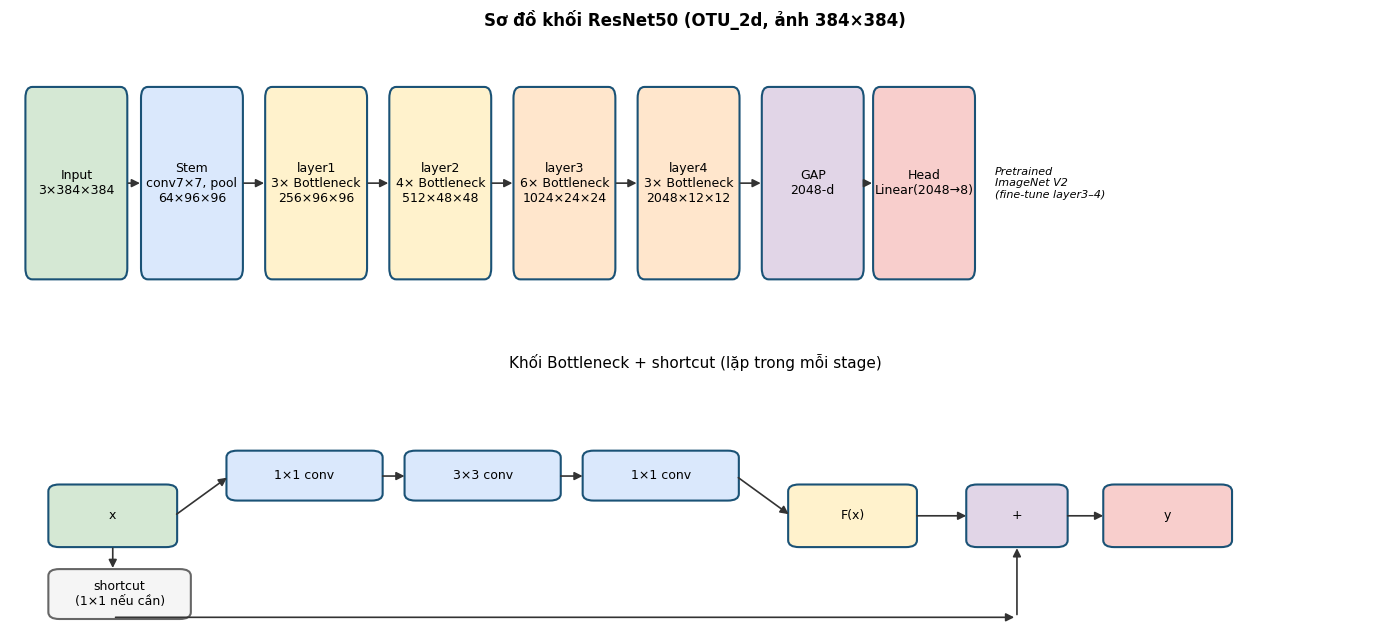

In [32]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch


def _box(ax, xy, w, h, text, fc="#E8F4FD", ec="#1a5276"):
    x, y = xy
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.08",
        linewidth=1.5, edgecolor=ec, facecolor=fc,
    )
    ax.add_patch(patch)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=9)


def _arrow(ax, x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1), (x2, y2),
            arrowstyle="-|>", mutation_scale=12, linewidth=1.2, color="#333",
        )
    )


fig, axes = plt.subplots(2, 1, figsize=(14, 6.5), gridspec_kw={"height_ratios": [1.2, 1]})

ax = axes[0]
ax.set_xlim(0, 16)
ax.set_ylim(0, 2.2)
ax.axis("off")
ax.set_title("Sơ đồ khối ResNet50 (OTU_2d, ảnh 384×384)", fontsize=12, fontweight="bold")

blocks = [
    (0.2, "Input\n3×384×384", "#D5E8D4"),
    (1.55, "Stem\nconv7×7, pool\n64×96×96", "#DAE8FC"),
    (3.0, "layer1\n3× Bottleneck\n256×96×96", "#FFF2CC"),
    (4.45, "layer2\n4× Bottleneck\n512×48×48", "#FFF2CC"),
    (5.9, "layer3\n6× Bottleneck\n1024×24×24", "#FFE6CC"),
    (7.35, "layer4\n3× Bottleneck\n2048×12×12", "#FFE6CC"),
    (8.8, "GAP\n2048-d", "#E1D5E7"),
    (10.1, "Head\nLinear(2048→8)", "#F8CECC"),
]
w, h = 1.15, 1.35
y0 = 0.45
for x, label, color in blocks:
    _box(ax, (x, y0), w, h, label, fc=color)
for i in range(len(blocks) - 1):
    _arrow(ax, blocks[i][0] + w, y0 + h / 2, blocks[i + 1][0], y0 + h / 2)
ax.text(11.5, y0 + h / 2, "Pretrained\nImageNet V2\n(fine-tune layer3–4)", fontsize=8, va="center", style="italic")

ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 3)
ax2.axis("off")
ax2.set_title("Khối Bottleneck + shortcut (lặp trong mỗi stage)", fontsize=11)
_box(ax2, (0.3, 1.0), 0.9, 0.7, "x", fc="#D5E8D4")
_box(ax2, (1.6, 1.55), 1.1, 0.55, "1×1 conv", fc="#DAE8FC")
_box(ax2, (2.9, 1.55), 1.1, 0.55, "3×3 conv", fc="#DAE8FC")
_box(ax2, (4.2, 1.55), 1.1, 0.55, "1×1 conv", fc="#DAE8FC")
_box(ax2, (5.7, 1.0), 0.9, 0.7, "F(x)", fc="#FFF2CC")
_box(ax2, (7.0, 1.0), 0.7, 0.7, "+", fc="#E1D5E7")
_box(ax2, (8.0, 1.0), 0.9, 0.7, "y", fc="#F8CECC")
_arrow(ax2, 1.2, 1.35, 1.6, 1.82)
_arrow(ax2, 2.7, 1.82, 2.9, 1.82)
_arrow(ax2, 4.0, 1.82, 4.2, 1.82)
_arrow(ax2, 5.3, 1.82, 5.7, 1.35)
_arrow(ax2, 6.6, 1.35, 7.0, 1.35)
_arrow(ax2, 7.7, 1.35, 8.0, 1.35)
_box(ax2, (0.3, 0.15), 1.0, 0.55, "shortcut\n(1×1 nếu cần)", fc="#F5F5F5", ec="#666")
_arrow(ax2, 0.75, 1.0, 0.75, 0.7)
_arrow(ax2, 0.75, 0.15, 7.35, 0.15)
_arrow(ax2, 7.35, 0.15, 7.35, 1.0)

plt.tight_layout()
plt.show()


In [33]:
# Bảng chi tiết từng lớp (torchsummary) — không phải sơ đồ khối hình vẽ
import torch
import torch.nn as nn
from torchsummary import summary
from torchvision.models import resnet50, ResNet50_Weights

NUM_CLASSES = 8
IMG_SIZE = 384


def build_resnet50(num_classes=NUM_CLASSES):
    """ResNet50 ImageNet V2, head Linear(2048, 8) — không Dropout."""
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


device = "cuda" if torch.cuda.is_available() else "cpu"
model = build_resnet50().to(device)

print("Thiết bị:", device)
summary(model, input_size=(3, IMG_SIZE, IMG_SIZE), batch_size=-1, device=device)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 142MB/s]


Thiết bị: cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 192, 192]           9,408
       BatchNorm2d-2         [-1, 64, 192, 192]             128
              ReLU-3         [-1, 64, 192, 192]               0
         MaxPool2d-4           [-1, 64, 96, 96]               0
            Conv2d-5           [-1, 64, 96, 96]           4,096
       BatchNorm2d-6           [-1, 64, 96, 96]             128
              ReLU-7           [-1, 64, 96, 96]               0
            Conv2d-8           [-1, 64, 96, 96]          36,864
       BatchNorm2d-9           [-1, 64, 96, 96]             128
             ReLU-10           [-1, 64, 96, 96]               0
           Conv2d-11          [-1, 256, 96, 96]          16,384
      BatchNorm2d-12          [-1, 256, 96, 96]             512
           Conv2d-13          [-1, 256, 96, 96]          16,384
      BatchNorm2d-14    

In [34]:
import pandas as pd

STAGES = ["conv1", "bn1", "layer1", "layer2", "layer3", "layer4", "fc"]
rows = []
for stage in STAGES:
    module = getattr(model, stage)
    rows.append({"Thành phần": stage, "Số tham số": sum(p.numel() for p in module.parameters())})

param_df = pd.DataFrame(rows)
param_df["Tỷ lệ (%)"] = (100 * param_df["Số tham số"] / param_df["Số tham số"].sum()).round(2)
print(param_df.to_string(index=False))
print(f"\nTổng tham số: {int(param_df['Số tham số'].sum()):,}")
deep = param_df["Thành phần"].isin(["layer3", "layer4"])
print(f"layer3 + layer4 (fine-tune giai đoạn 2): {int(param_df.loc[deep, 'Số tham số'].sum()):,}")

Thành phần  Số tham số  Tỷ lệ (%)
     conv1        9408       0.04
       bn1         128       0.00
    layer1      215808       0.92
    layer2     1219584       5.18
    layer3     7098368      30.17
    layer4    14964736      63.61
        fc       16392       0.07

Tổng tham số: 23,524,424
layer3 + layer4 (fine-tune giai đoạn 2): 22,063,104


In [35]:
model.eval()
x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)

with torch.no_grad():
    print(f"{'input':10s} {tuple(x.shape)}")
    x = model.maxpool(model.relu(model.bn1(model.conv1(x))))
    print(f"{'stem':10s} {tuple(x.shape)}")
    for stage in ["layer1", "layer2", "layer3", "layer4"]:
        x = getattr(model, stage)(x)
        print(f"{stage:10s} {tuple(x.shape)}")
    x = torch.flatten(model.avgpool(x), 1)
    print(f"{'avgpool':10s} {tuple(x.shape)}")
    print(f"{'fc':10s} {tuple(model.fc(x).shape)}")

input      (1, 3, 384, 384)
stem       (1, 64, 96, 96)
layer1     (1, 256, 96, 96)
layer2     (1, 512, 48, 48)
layer3     (1, 1024, 24, 24)
layer4     (1, 2048, 12, 12)
avgpool    (1, 2048)
fc         (1, 8)


## 4.4 Lịch huấn luyện: SGD + poly LR decay

Một cấu hình duy nhất, không chia pha:

| Thành phần | Giá trị |
| --- | --- |
| Khởi tạo | ImageNet-pretrained |
| Tham số được train | **toàn bộ mạng** |
| Optimizer | SGD |
| Momentum | 0.9 |
| Weight decay | 0.0005 |
| LR ban đầu | 0.01 |
| LR decay | `poly`, power 0.9 |
| Loss | Cross-entropy |

**Poly LR decay.** Learning rate giảm theo số iteration đã chạy, không theo epoch:

$$
\eta_t = \eta_0 \left(1 - \frac{t}{T}\right)^{0.9}
$$

với $t$ là iteration hiện tại, $T$ là tổng số iteration của toàn bộ quá trình train. Với 1000 ảnh và batch 32 thì mỗi epoch có 32 iteration; 60 epoch cho $T \approx 1920$. LR bắt đầu ở 0.01 và giảm gần như tuyến tính về 0 — power 0.9 làm đường cong hơi lồi lên so với đường thẳng, nên phần đầu giảm chậm hơn một chút.

**BatchNorm.** Vì train toàn mạng, mọi BatchNorm đều ở mode `train` và cập nhật `running_mean` / `running_var` theo dữ liệu siêu âm. Batch 32 đủ lớn để thống kê BN ổn định.

**Không early-stopping.** Không có tập val (mục 3.1), nên số epoch là hằng số chốt trước và checkpoint lưu ở epoch cuối.



Tham số theo stage (tất cả đều được train):
 stage     params   pct  n_batchnorm
 conv1      9,408  0.0%            0
   bn1        128  0.0%            1
layer1    215,808  0.9%           10
layer2  1,219,584  5.2%           13
layer3  7,098,368 30.2%           19
layer4 14,964,736 63.6%           10
    fc     16,392  0.1%            0

Tổng tham số        : 23,524,424
Tham số được train  : 23,524,424  (100%)
Số lớp BatchNorm    : 53 — tất cả ở mode train, cập nhật running stats bình thường


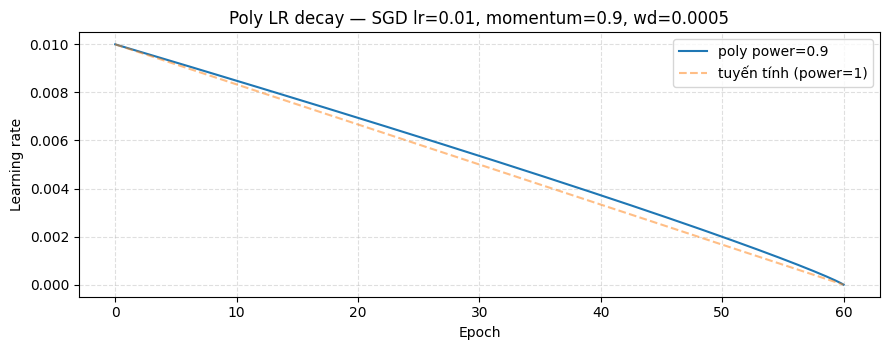

iters/epoch = 32   tổng iteration T = 1920
  epoch  0: lr = 0.010000
  epoch 15: lr = 0.007719
  epoch 30: lr = 0.005359
  epoch 45: lr = 0.002872
  epoch 59: lr = 0.000251


In [36]:
import matplotlib.pyplot as plt
import torch.nn as nn

# Hằng số huấn luyện
LR_BASE = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
POLY_POWER = 0.9
EPOCHS_PAPER = 60


def poly_lr_factor(it: int, max_iters: int, power: float = POLY_POWER) -> float:
    """eta_t / eta_0 = (1 - t/T)^power."""
    return max(0.0, 1.0 - it / max(1, max_iters)) ** power


def n_trainable(model) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def n_bn(module) -> int:
    return sum(1 for m in module.modules() if isinstance(m, nn.BatchNorm2d))


# ---- Kiểm tra: train toàn mạng, không đóng băng gì -------------------------
demo = build_resnet50()
demo.train()
total = sum(p.numel() for p in demo.parameters())
frozen = [n for n, p in demo.named_parameters() if not p.requires_grad]
assert not frozen, f"Có tham số bị đóng băng: {frozen[:5]}"

print("Tham số theo stage (tất cả đều được train):")
rows = []
for name in ["conv1", "bn1", "layer1", "layer2", "layer3", "layer4", "fc"]:
    mod = getattr(demo, name)
    n_p = sum(p.numel() for p in mod.parameters())
    rows.append({"stage": name, "params": n_p, "pct": 100 * n_p / total, "n_batchnorm": n_bn(mod)})
print(pd.DataFrame(rows).to_string(index=False, formatters={"pct": "{:.1f}%".format, "params": "{:,}".format}))
print(f"\nTổng tham số        : {total:,}")
print(f"Tham số được train  : {n_trainable(demo):,}  ({100 * n_trainable(demo) / total:.0f}%)")
print(f"Số lớp BatchNorm    : {n_bn(demo)} — tất cả ở mode train, cập nhật running stats bình thường")
del demo

# ---- Đường cong poly LR ----------------------------------------------------
n_train_imgs, batch_size = 1000, 32
iters_per_epoch = int(np.ceil(n_train_imgs / batch_size))
max_iters = EPOCHS_PAPER * iters_per_epoch
its = np.arange(max_iters + 1)
lrs = LR_BASE * np.array([poly_lr_factor(int(t), max_iters) for t in its])

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(its / iters_per_epoch, lrs, label=f"poly power={POLY_POWER}")
ax.plot(its / iters_per_epoch, LR_BASE * (1 - its / max_iters), "--", alpha=0.5, label="tuyến tính (power=1)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning rate")
ax.set_title(f"Poly LR decay — SGD lr={LR_BASE}, momentum={MOMENTUM}, wd={WEIGHT_DECAY}")
ax.grid(linestyle="--", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

print(f"iters/epoch = {iters_per_epoch}   tổng iteration T = {max_iters}")
for ep in [0, 15, 30, 45, 59]:
    t = ep * iters_per_epoch
    print(f"  epoch {ep:2d}: lr = {LR_BASE * poly_lr_factor(t, max_iters):.6f}")


# 5. Huấn luyện và Đánh giá

Một mô hình, một lần train, một lần đánh giá test.
| Thành phần | Cấu hình |
| --- | --- |
| Mô hình | ResNet-50 + GAP, ImageNet-pretrained, head `Linear(2048, 8)` |
| Train | 1000 ảnh `split_paper == "train"` |
| Test | 469 ảnh `split_paper == "test"` |
| Augment | Train: `Resize(448)×(0.5–2.0)` + `RandomCrop(384)` + Flip. Test: letterbox 448, giữ cả ảnh, pad viền |
| Optimizer | SGD lr 0.01, momentum 0.9, weight decay 5e-4 |
| Scheduler | poly power 0.9, bước theo **iteration** |
| Loss | `CrossEntropyLoss` thuần (không dùng label smoothing, weight=class_weight) |
| Epoch | **60, cố định** — không early-stopping, không chọn best |
| Checkpoint | epoch cuối, `runs/resnet50_paper_last.pt` |

**Metric:** top-1 accuracy, top-2 accuracy, thêm macro-F1 và macro-AUC để nhìn các lớp hiếm.

**Không sử dụng:**

| Kỹ thuật | Lý do |
| --- | --- |
| GeM / Attention pooling, backbone khác | Chỉ dùng ResNet-50 với GAP gốc |
| K-fold chọn kiến trúc | Chỉ có một cấu hình, không cần chọn |
| Ghép đặc trưng thủ công (concat CSV, fusion) | Mô hình chỉ học từ ảnh |
| TTA (lật + xoay, trung bình logits) | Suy luận một lần trên mỗi ảnh test |
| `WeightedRandomSampler`, label smoothing, focal loss, EMA, SWA, mixup | Giữ nguyên phân bố lớp và cross-entropy thuần (xem mục 2.2) |

Mục 5 tự nạp cache của mục 3.3. Cần chạy 4.3 và 4.4 trước để có `build_resnet50` và các hằng số LR.


## 5.1 Dataset / DataLoader

**Pipeline ảnh** (không dùng center crop kiểu ImageNet):

| Thành phần | Giá trị |
| --- | --- |
| Train | `Resize(448)×(0.5–2.0)` → `RandomCrop(384)` → Flip |
| Test | letterbox 448×448: `keep_ratio` cạnh dài = 448, **không crop giữa**, pad viền |


Pad vuông 448 lúc test chỉ để ghép batch (ResNet cần cùng H×W); nội dung ảnh vẫn giữ theo tỷ lệ cạnh dài = 448, không cắt.

In [37]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from sklearn.utils.class_weight import compute_class_weight

if "CACHE_DIR" not in globals():
    DRIVE_PROJECT = Path("/content/drive/MyDrive/TL_OvarianTumor_Ultrasound")
    if not DRIVE_PROJECT.exists():
        DRIVE_PROJECT = Path(".").resolve()
    CACHE_DIR = DRIVE_PROJECT / "cache"
    RUNS_DIR = DRIVE_PROJECT / "runs"
    OUTPUT_DIR = DRIVE_PROJECT / "outputs"
for _d in (CACHE_DIR, RUNS_DIR, OUTPUT_DIR):
    _d.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {
    0: "Chocolate cyst",
    1: "Serous cystadenoma",
    2: "Teratoma",
    3: "Theca cell tumor",
    4: "Simple cyst",
    5: "Normal ovary",
    6: "Mucinous cystadenoma",
    7: "High grade serous",
}
NUM_CLASSES = 8
MINORITY_CLASSES = {3, 4, 6, 7}   # lớp hiếm, accuracy thường thấp hơn
IMG_SIZE = 384                    # RandomCrop lúc train (mmotu.py crop_size)
IMG_SCALE = 448                   # mmotu.py img_scale
RATIO_RANGE = (0.5, 2.0)          # mmotu.py ratio_range
SEED = 42

# ---- Cấu hình huấn luyện -------------------------------------------------
BATCH_SIZE = 32
LR_BASE = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
POLY_POWER = 0.9
EPOCHS_PAPER = 60       # chốt trước, không early-stopping (xem mục 3.1)

PRIMARY_SPLIT = "split_paper"
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
NUM_WORKERS = 0 if os.name == "nt" else 2


def _cache_paths():
    return CACHE_DIR / "otu2d_rgb_orig.pkl", CACHE_DIR / "otu2d_index.csv"


def attach_splits(index_df: pd.DataFrame) -> pd.DataFrame:
    """Gắn split_paper nếu cache CSV cũ chưa có cột."""
    out = index_df.copy()
    splits_path = OUTPUT_DIR / "mmotu_splits.csv"
    need = ["split_official", PRIMARY_SPLIT]
    missing = [c for c in need if c not in out.columns]
    if missing and splits_path.exists():
        sp = pd.read_csv(splits_path)
        keep = ["image_name"] + [c for c in missing if c in sp.columns]
        out = out.merge(sp[keep], on="image_name", how="left")
        print("Đã merge cột split từ", splits_path.name, "→", keep[1:])
    if PRIMARY_SPLIT not in out.columns:
        if "split_official" not in out.columns:
            raise KeyError(f"Thiếu {PRIMARY_SPLIT} và split_official — chạy mục 3.1.")
        print(f"Tạo {PRIMARY_SPLIT} từ split_official: train = train_cls.txt, test = val_cls.txt.")
        is_test = out["split_official"].astype(str).str.lower().isin(["val", "test"])
        out[PRIMARY_SPLIT] = np.where(is_test, "test", "train")
    return out


_CACHE_MEM = {}


def get_cache():
    if "full" in _CACHE_MEM:
        return _CACHE_MEM["full"]
    pkl, csv = _cache_paths()
    ram = globals().get("images_u8")
    ram_ok = isinstance(ram, list) and len(ram) > 0 and getattr(ram[0], "ndim", 0) == 3
    if ram_ok:
        images = ram
        if csv.exists():
            index = attach_splits(pd.read_csv(csv))
        elif "index_df" in globals() and isinstance(index_df, pd.DataFrame):
            index = attach_splits(index_df.copy())
        else:
            raise FileNotFoundError(f"Có ảnh trong RAM nhưng thiếu {csv} — chạy mục 3.3.")
        if len(index) != len(images):
            raise ValueError(f"RAM {len(images)} ảnh nhưng index {len(index)} hàng — chạy lại mục 3.3.")
        labels = index["label"].to_numpy(dtype=np.int64)
        _CACHE_MEM["full"] = {"images": images, "index": index, "labels": labels, "pkl": pkl}
        print(f"Cache: RAM {len(images)} ảnh (không đọc lại {pkl.name})")
        if PRIMARY_SPLIT in index.columns:
            print(index[PRIMARY_SPLIT].value_counts())
        return _CACHE_MEM["full"]
    if not pkl.exists() or not csv.exists():
        hint = f"Thiếu cache ảnh gốc:\n  {pkl}\n  {csv}\nChạy mục 3.3."
        raise FileNotFoundError(hint)
    import pickle
    with pkl.open("rb") as f:
        images = pickle.load(f)
    index = attach_splits(pd.read_csv(csv))
    assert isinstance(images, list), type(images)
    assert len(index) == len(images), (len(index), len(images))
    assert images[0].ndim == 3 and images[0].shape[-1] == 3, images[0].shape
    labels = index["label"].to_numpy(dtype=np.int64)
    _CACHE_MEM["full"] = {"images": images, "index": index, "labels": labels, "pkl": pkl}
    hs = [im.shape[0] for im in images]
    ws = [im.shape[1] for im in images]
    print(f"Cache: {pkl.name} N={len(images)}  H {min(hs)}–{max(hs)}  W {min(ws)}–{max(ws)}")
    if PRIMARY_SPLIT in index.columns:
        print(index[PRIMARY_SPLIT].value_counts())
    return _CACHE_MEM["full"]


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ---- Augment: mmotu.py của tác giả ---------------------------------------
# train: Resize(img_scale=(448,448), ratio_range=(0.5,2.0), keep_ratio)
#        → RandomCrop(384) → RandomFlip
# test : Resize keep_ratio img_scale=(448,448), không crop giữa.
# mmcv.imrescale(scale=(S,S)): cạnh dài → S.


def _resize_hw(img: torch.Tensor, size_hw) -> torch.Tensor:
    return TF.resize(
        img, list(size_hw),
        interpolation=TF.InterpolationMode.BILINEAR, antialias=True,
    )


def _keep_ratio_long_edge(img: torch.Tensor, box: int) -> torch.Tensor:
    """Giữ tỉ lệ, cạnh dài = box (mmcv.imrescale với scale=(box, box))."""
    h, w = img.shape[-2:]
    scale = box / max(h, w, 1)
    new_h = max(1, int(round(h * scale)))
    new_w = max(1, int(round(w * scale)))
    return _resize_hw(img, (new_h, new_w))


def random_resize(img: torch.Tensor, ratio_range=RATIO_RANGE, img_scale=IMG_SCALE) -> torch.Tensor:
    """Resize base 448 × ratio ∈ [0.5, 2.0], keep_ratio — không nhân H×W gốc."""
    ratio = float(torch.empty(1).uniform_(*ratio_range))
    box = max(1, int(round(img_scale * ratio)))
    return _keep_ratio_long_edge(img, box)


def pad_if_needed(img: torch.Tensor, size: int) -> torch.Tensor:
    h, w = img.shape[-2:]
    pad_h, pad_w = max(0, size - h), max(0, size - w)
    if pad_h == 0 and pad_w == 0:
        return img
    left, right = pad_w // 2, pad_w - pad_w // 2
    top, bottom = pad_h // 2, pad_h - pad_h // 2
    return TF.pad(img, [left, top, right, bottom], fill=0.0)


def random_crop(img: torch.Tensor, size: int) -> torch.Tensor:
    img = pad_if_needed(img, size)
    h, w = img.shape[-2:]
    top = int(torch.randint(0, h - size + 1, (1,)))
    left = int(torch.randint(0, w - size + 1, (1,)))
    return img[..., top : top + size, left : left + size]


def random_resize_and_crop(img: torch.Tensor, size: int = IMG_SIZE) -> torch.Tensor:
    return random_crop(random_resize(img), size)


def resize_letterbox(img: torch.Tensor, size: int = IMG_SCALE) -> torch.Tensor:
    """Test mmotu.py: keep_ratio cạnh dài = 448, pad vuông để ghép batch. Không center crop."""
    return pad_if_needed(_keep_ratio_long_edge(img, size), size)


def augment_train_tensor(img: torch.Tensor, size: int = IMG_SIZE) -> torch.Tensor:
    """Resize(448)×(0.5–2.0) + RandomCrop(384) + RandomHorizontalFlip(0.5)."""
    img = random_resize_and_crop(img, size=size)
    if torch.rand(1).item() < 0.5:
        img = img.flip(-1)
    return img


class OTU2dCacheDataset(Dataset):
    """RGB gốc → train crop 384 hoặc test letterbox 448, theo mmotu.py."""

    def __init__(
        self,
        images,
        labels,
        indices,
        augment=False,
        size=IMG_SIZE,
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
        return_index=False,
    ):
        self.images = images
        self.labels = labels
        self.indices = np.asarray(indices, dtype=np.int64)
        self.augment = augment
        self.size = size
        self.mean = mean
        self.std = std
        self.return_index = return_index

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = int(self.indices[i])
        # Train: crop 384. Test: letterbox 448 (mmotu.py, không center crop).
        x = torch.from_numpy(np.ascontiguousarray(self.images[idx]))
        x = x.permute(2, 0, 1).float().div_(255.0)
        if self.augment:
            x = augment_train_tensor(x, size=self.size)
        else:
            x = resize_letterbox(x, size=IMG_SCALE)
        x = TF.normalize(x, self.mean, self.std)
        y = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        if self.return_index:
            return x, y, idx
        return x, y


def split_indices(index_df: pd.DataFrame | None = None) -> dict:
    """Trả về chỉ số của 2 tập theo split_paper: train 1000, test 469."""
    if index_df is None:
        index_df = get_cache()["index"]
    if PRIMARY_SPLIT not in index_df.columns:
        raise KeyError(f"index thiếu cột {PRIMARY_SPLIT} — chạy mục 3.1.")
    return {
        s: index_df.index[index_df[PRIMARY_SPLIT].astype(str) == s].to_numpy()
        for s in ("train", "test")
    }


def make_loaders(batch_size: int = None, seed: int = SEED):
    """Hai loader duy nhất: train (1000, shuffle, augment) và test (469, không augment)."""
    pack = get_cache()
    images, index_df, labels_all = pack["images"], pack["index"], pack["labels"]
    parts = split_indices(index_df)
    bs = BATCH_SIZE if batch_size is None else batch_size
    for split, idx in parts.items():
        print(f"  {PRIMARY_SPLIT} {split:5s}: {len(idx)}")

    y_train = labels_all[parts["train"]]
    cw = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_train)
    print("  class_weight (CHỈ tham khảo, không dùng trong loss — mục 2.2):",
          {int(c): round(float(w), 2) for c, w in enumerate(cw)})

    train_ds = OTU2dCacheDataset(images, labels_all, parts["train"], augment=True)
    test_ds = OTU2dCacheDataset(images, labels_all, parts["test"], augment=False)
    pin = torch.cuda.is_available()
    g = torch.Generator()
    g.manual_seed(seed)
    loaders = {
        "train": DataLoader(
            train_ds, batch_size=bs, shuffle=True, generator=g,
            num_workers=NUM_WORKERS, pin_memory=pin, drop_last=False,
        ),
        "test": DataLoader(
            test_ds, batch_size=bs, shuffle=False,
            num_workers=NUM_WORKERS, pin_memory=pin,
        ),
    }
    meta = {
        "cw": cw, "parts": parts, "images": images,
        "index": index_df, "labels": labels_all,
        "iters_per_epoch": len(loaders["train"]),
    }
    return loaders, meta


cache_full = get_cache()
index_df = cache_full["index"]
images_u8 = cache_full["images"]
labels_all = cache_full["labels"]

_parts = split_indices(index_df)
assert len(_parts["train"]) == 1000, f"train phải 1000, đang {len(_parts['train'])}"
assert len(_parts["test"]) == 469, f"test phải 469, đang {len(_parts['test'])}"

x_aug, y0 = OTU2dCacheDataset(images_u8, labels_all, [0], augment=True)[0]
x_ev, _ = OTU2dCacheDataset(images_u8, labels_all, [0], augment=False)[0]
print(f"\nTrain sample (augment): {tuple(x_aug.shape)} {x_aug.dtype}  label={int(y0)}")
print(f"Test  sample (letterbox {IMG_SCALE}, mmotu.py): {tuple(x_ev.shape)} {x_ev.dtype}")
print(f"{PRIMARY_SPLIT} counts:\n{index_df[PRIMARY_SPLIT].value_counts()}")
print(f"\nIteration/epoch = {int(np.ceil(1000 / BATCH_SIZE))}  ->  "
      f"T = {EPOCHS_PAPER * int(np.ceil(1000 / BATCH_SIZE))} iteration cho poly LR")


Cache: RAM 1469 ảnh (không đọc lại otu2d_rgb_orig.pkl)
split_paper
train    1000
test      469
Name: count, dtype: int64

Train sample (augment): (3, 384, 384) torch.float32  label=4
Test  sample (letterbox 448, mmotu.py): (3, 448, 448) torch.float32
split_paper counts:
split_paper
train    1000
test      469
Name: count, dtype: int64

Iteration/epoch = 32  ->  T = 1920 iteration cho poly LR


## 5.2 Vòng lặp huấn luyện

Các hàm của engine huấn luyện:

| Hàm | Ý nghĩa |
| --- | --- |
| `build_resnet50()` | ResNet-50 ImageNet V2, GAP gốc, head `Linear(2048, 8)` |
| `make_optimizer()` | `SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)` — toàn mạng, một nhóm LR |
| `make_poly_scheduler()` | `LambdaLR` với $(1 - t/T)^{0.9}$, `step()` sau **mỗi iteration** |
| `run_train_epoch()` | Mô hình 1 epoch với `BATCH_SIZE = 32` cho 1000 ảnh, dùng AMP (Automatic Mixed Precision) để tối ưu tốc độ tính toán, poly LR được gọi sau mỗi batch |
| `collect_logits()` | Suy luận thuần trên test, không tăng cường dữ liệu khi test **TTA (Test-Time Augmentation)**|
| `metrics_from_logits()` | gồm các thông số top-1, top-2, macro-F1, macro-AUC |
| `train_experiment()` | Chạy đủ 60 epoch, ghi `train_history_*.csv` và checkpoint mỗi epoch (ghi đè) |

Checkpoint ghi đè sau mỗi epoch nên file `*_last.pt` luôn là epoch mới nhất đã hoàn tất — nếu Colab ngắt giữa đường thì vẫn còn kết quả, và không có bước nào "chọn epoch tốt nhất" bằng test để tránh bị data leakage.


In [38]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from torchvision.models import resnet50, ResNet50_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
print("device:", device, "  AMP:", use_amp)
if device.type != "cuda":
    print("Cảnh báo: đang train CPU — trên Colab chọn Runtime → T4 GPU.")


# ---- Mô hình: ResNet-50 + GAP, head 8 lớp ----------------------------------
def build_resnet50(num_classes=NUM_CLASSES):
    """ResNet50 ImageNet V2, giữ nguyên GAP, thay fc bằng Linear(2048, 8)."""
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


# ---- Metric: top-1, top-2 + macro-F1, macro-AUC ---------------------------
def metrics_from_logits(logits, y_true) -> dict:
    logits_t = logits.detach().cpu() if torch.is_tensor(logits) else torch.as_tensor(logits)
    y = np.asarray(y_true)
    probs = torch.softmax(logits_t, dim=1).numpy()
    y_pred = probs.argmax(1)
    top2 = logits_t.topk(2, dim=1).indices.numpy()
    try:
        macro_auc = float(roc_auc_score(y, probs, multi_class="ovr", average="macro"))
    except ValueError:
        macro_auc = float("nan")
    return {
        "acc": float(accuracy_score(y, y_pred)),
        "top2_acc": float((top2 == y.reshape(-1, 1)).any(axis=1).mean()),
        "macro_f1": float(f1_score(y, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y, y_pred, average="weighted", zero_division=0)),
        "macro_auc": macro_auc,
        "y_true": y,
        "y_pred": y_pred,
        "logits": logits_t.numpy(),
        "probs": probs,
    }


# ---- Optimizer + poly LR --------------------------------------------------
def make_optimizer(model, lr=LR_BASE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY):
    """SGD trên TOÀN BỘ tham số — không đóng băng và không chia nhóm LR."""
    return torch.optim.SGD(
        model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay,
    )


def make_poly_scheduler(optimizer, max_iters: int, power=POLY_POWER):
    """lr_t = lr_0 * (1 - t/T)^power, bước theo từng iteration."""
    return torch.optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=lambda it: max(0.0, 1.0 - it / max(1, max_iters)) ** power,
    )


def run_train_epoch(model, loader, criterion, optimizer, scaler, scheduler) -> dict:
    model.train()
    total_loss, n_seen = 0.0, 0
    ys, logit_chunks = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()  # poly LR: mỗi iteration một bước
        total_loss += float(loss.item()) * y.size(0)
        n_seen += y.size(0)
        ys.append(y.detach().cpu())
        logit_chunks.append(logits.detach().float().cpu())
    out = metrics_from_logits(torch.cat(logit_chunks), torch.cat(ys).numpy())
    out["loss"] = total_loss / max(n_seen, 1)
    return out


@torch.no_grad()
def collect_logits(model, loader):
    """Suy luận thuần, không TTA."""
    model.eval()
    ys, chunks = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(x)
        ys.append(y.cpu())
        chunks.append(logits.float().cpu())
    return torch.cat(chunks), torch.cat(ys).numpy()


def load_checkpoint(model, path):
    try:
        obj = torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        obj = torch.load(path, map_location=device)
    state = obj["model"] if isinstance(obj, dict) and "model" in obj else obj
    model.load_state_dict(state, strict=True)
    return obj


# ---- Vòng huấn luyện: một pha, số epoch cố định ----------------------------
def train_experiment(cfg: dict) -> dict:
    cfg = {**dict(
        name="resnet50_paper",
        epochs=EPOCHS_PAPER,
        lr=LR_BASE,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY,
        poly_power=POLY_POWER,
        batch_size=BATCH_SIZE,
        seed=SEED,
    ), **cfg}
    set_seed(cfg["seed"])
    loaders, meta = make_loaders(batch_size=cfg["batch_size"], seed=cfg["seed"])

    model = build_resnet50().to(device)
    criterion = nn.CrossEntropyLoss()   # thuần, không label smoothing, không class weight
    optimizer = make_optimizer(model, cfg["lr"], cfg["momentum"], cfg["weight_decay"])
    iters_per_epoch = len(loaders["train"])
    max_iters = cfg["epochs"] * iters_per_epoch
    scheduler = make_poly_scheduler(optimizer, max_iters, cfg["poly_power"])
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    ckpt_path = RUNS_DIR / f"{cfg['name']}_last.pt"
    hist_path = RUNS_DIR / f"train_history_{cfg['name']}.csv"
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n=== {cfg['name']} ===")
    print(f"  SGD lr={cfg['lr']}  momentum={cfg['momentum']}  weight_decay={cfg['weight_decay']}")
    print(f"  poly power={cfg['poly_power']}  epochs={cfg['epochs']}  "
          f"iters/epoch={iters_per_epoch}  T={max_iters}")
    print(f"  tham số train={n_params:,} (toàn mạng)  loss=CrossEntropyLoss")
    print("  Không val, không early-stopping: checkpoint lưu ở epoch cuối.")

    history = []
    for epoch in range(1, cfg["epochs"] + 1):
        tr = run_train_epoch(model, loaders["train"], criterion, optimizer, scaler, scheduler)
        lr_now = optimizer.param_groups[0]["lr"]
        history.append({
            "epoch": epoch,
            "train_loss": tr["loss"],
            "train_acc": tr["acc"],
            "train_macro_f1": tr["macro_f1"],
            "lr": lr_now,
        })
        pd.DataFrame(history).to_csv(hist_path, index=False)
        # Ghi checkpoint mỗi epoch (ghi đè) → luôn là epoch mới nhất đã hoàn tất
        torch.save({"model": model.state_dict(), "epoch": epoch, "cfg": cfg}, ckpt_path)
        if epoch % 5 == 0 or epoch in (1, cfg["epochs"]):
            print(f"  ep {epoch:02d}/{cfg['epochs']}  train_loss={tr['loss']:.4f}  "
                  f"train_acc={tr['acc']:.3f}  train_F1={tr['macro_f1']:.3f}  lr={lr_now:.6f}")

    print(f"  Xong {cfg['epochs']} epoch. Checkpoint: {ckpt_path.name}")
    return {
        "history": pd.DataFrame(history),
        "ckpt": ckpt_path,
        "loaders": loaders,
        "meta": meta,
        "n_epochs": cfg["epochs"],
        "cfg": cfg,
    }


print("\nSẵn sàng: build_resnet50, train_experiment, collect_logits, metrics_from_logits.")


device: cuda   AMP: True

Sẵn sàng: build_resnet50, train_experiment, collect_logits, metrics_from_logits.


## 5.3 Huấn luyện ResNet-50

Một run duy nhất: `resnet50_paper`. Train trên 1000 ảnh, 60 epoch cố định. Test 469 ảnh **không chồng bệnh nhân** với train và không được dùng ở bước này.

`FORCE_RETRAIN=False` sẽ nạp lại checkpoint nếu đã có; đặt `FORCE_RETRAIN=True` để train lại từ đầu.

Thời gian tham khảo trên Colab T4: khoảng 40–60 giây/epoch với batch 32 ở 384×384, tức 40–60 phút cho 60 epoch.


In [39]:
FORCE_RETRAIN = True

experiment_runs = {}


def run_or_load(cfg, force=FORCE_RETRAIN):
    name = cfg["name"]
    ckpt_path = RUNS_DIR / f"{name}_last.pt"
    hist_path = RUNS_DIR / f"train_history_{name}.csv"
    if (not force) and ckpt_path.exists() and hist_path.exists():
        print(f"Nạp checkpoint có sẵn: {ckpt_path.name} (đặt FORCE_RETRAIN=True để train lại)")
        loaders, meta = make_loaders(batch_size=cfg.get("batch_size", BATCH_SIZE),
                                     seed=cfg.get("seed", SEED))
        hist = pd.read_csv(hist_path)
        rec = {
            "history": hist,
            "ckpt": ckpt_path,
            "loaders": loaders,
            "meta": meta,
            "n_epochs": int(hist["epoch"].max()),
            "cfg": cfg,
        }
        experiment_runs[name] = rec
        return rec
    rec = train_experiment(cfg)
    experiment_runs[name] = rec
    return rec


PAPER_CFG = dict(
    name="resnet50_paper",
    epochs=EPOCHS_PAPER,
    lr=LR_BASE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    poly_power=POLY_POWER,
    batch_size=BATCH_SIZE,
    seed=SEED,
)

print("=" * 72)
print("BẮT ĐẦU", PAPER_CFG["name"])
for k, v in PAPER_CFG.items():
    print(f"  {k:14s}= {v}")
print("=" * 72)

run = run_or_load(PAPER_CFG)

hist = run["history"]
print(f"\nĐã train {run['n_epochs']} epoch.")
print("5 epoch cuối:")
print(hist.tail(5).to_string(index=False))
print(f"\nCheckpoint: {run['ckpt']}")
print("Test 469 chưa được chấm — sang mục 5.4.")


BẮT ĐẦU resnet50_paper
  name          = resnet50_paper
  epochs        = 60
  lr            = 0.01
  momentum      = 0.9
  weight_decay  = 0.0005
  poly_power    = 0.9
  batch_size    = 32
  seed          = 42
  split_paper train: 1000
  split_paper test : 469
  class_weight (CHỈ tham khảo, không dùng trong loss — mục 2.2): {0: 0.55, 1: 0.82, 2: 0.55, 3: 2.19, 4: 2.66, 5: 0.69, 6: 1.76, 7: 3.29}

=== resnet50_paper ===
  SGD lr=0.01  momentum=0.9  weight_decay=0.0005
  poly power=0.9  epochs=60  iters/epoch=32  T=1920
  tham số train=23,524,424 (toàn mạng)  loss=CrossEntropyLoss
  Không val, không early-stopping: checkpoint lưu ở epoch cuối.
  ep 01/60  train_loss=1.9116  train_acc=0.253  train_F1=0.125  lr=0.009850
  ep 05/60  train_loss=1.3333  train_acc=0.537  train_F1=0.301  lr=0.009247
  ep 10/60  train_loss=0.8518  train_acc=0.722  train_F1=0.597  lr=0.008487
  ep 15/60  train_loss=0.4842  train_acc=0.834  train_F1=0.787  lr=0.007719
  ep 20/60  train_loss=0.3538  train_acc=0.88

## 5.4 Đánh giá trên test 469

Thực hiện đánh giá trên tập test, các kết quả cần để so sánh:

1. **top-1 và top-2 accuracy** — top-2 có ích trong thực tế vì đưa ra hai lớp ứng viên để hỗ trợ chẩn đoán.
2. **Confusion matrix 8 lớp**.
3. **ROC one-vs-rest 8 đường + AUC từng lớp**.
4. **Đường cong train** (loss, accuracy, learning rate) — không có đường val.

Thêm macro-F1 và macro-AUC để nhìn rõ 4 lớp hiếm, vì accuracy bị chi phối bởi các lớp nhiều mẫu.

Kết quả ghi ra `runs/results_resnet50.csv`, `runs/per_class_resnet50_paper.csv` và `runs/results_comparison.csv`.


Nạp checkpoint resnet50_paper_last.pt (epoch 60)
  split_paper train: 1000
  split_paper test : 469
  class_weight (CHỈ tham khảo, không dùng trong loss — mục 2.2): {0: 0.55, 1: 0.82, 2: 0.55, 3: 2.19, 4: 2.66, 5: 0.69, 6: 1.76, 7: 3.29}
Test tensor: (3, 448, 448)  (mmotu.py: letterbox 448, không center crop)

resnet50_paper — TEST 469 ảnh (official val_cls.txt, 76 bệnh nhân)
  top-1 accuracy : 0.7761
  top-2 accuracy : 0.8891
  macro-F1       : 0.7023
  weighted-F1    : 0.7735
  macro-AUC      : 0.9327

                      precision    recall  f1-score   support

      Chocolate cyst      0.868     0.836     0.852       110
  Serous cystadenoma      0.637     0.773     0.699        66
            Teratoma      0.850     0.843     0.847       108
    Theca cell tumor      0.739     0.548     0.630        31
         Simple cyst      0.533     0.421     0.471        19
        Normal ovary      0.773     0.862     0.815        87
Mucinous cystadenoma      0.697     0.697     0.697    

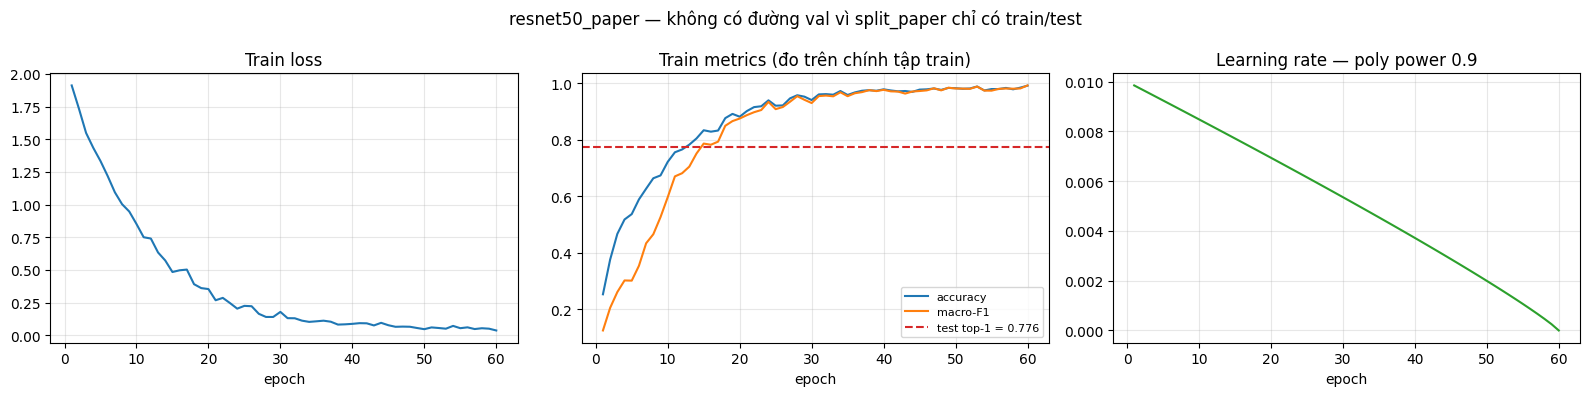

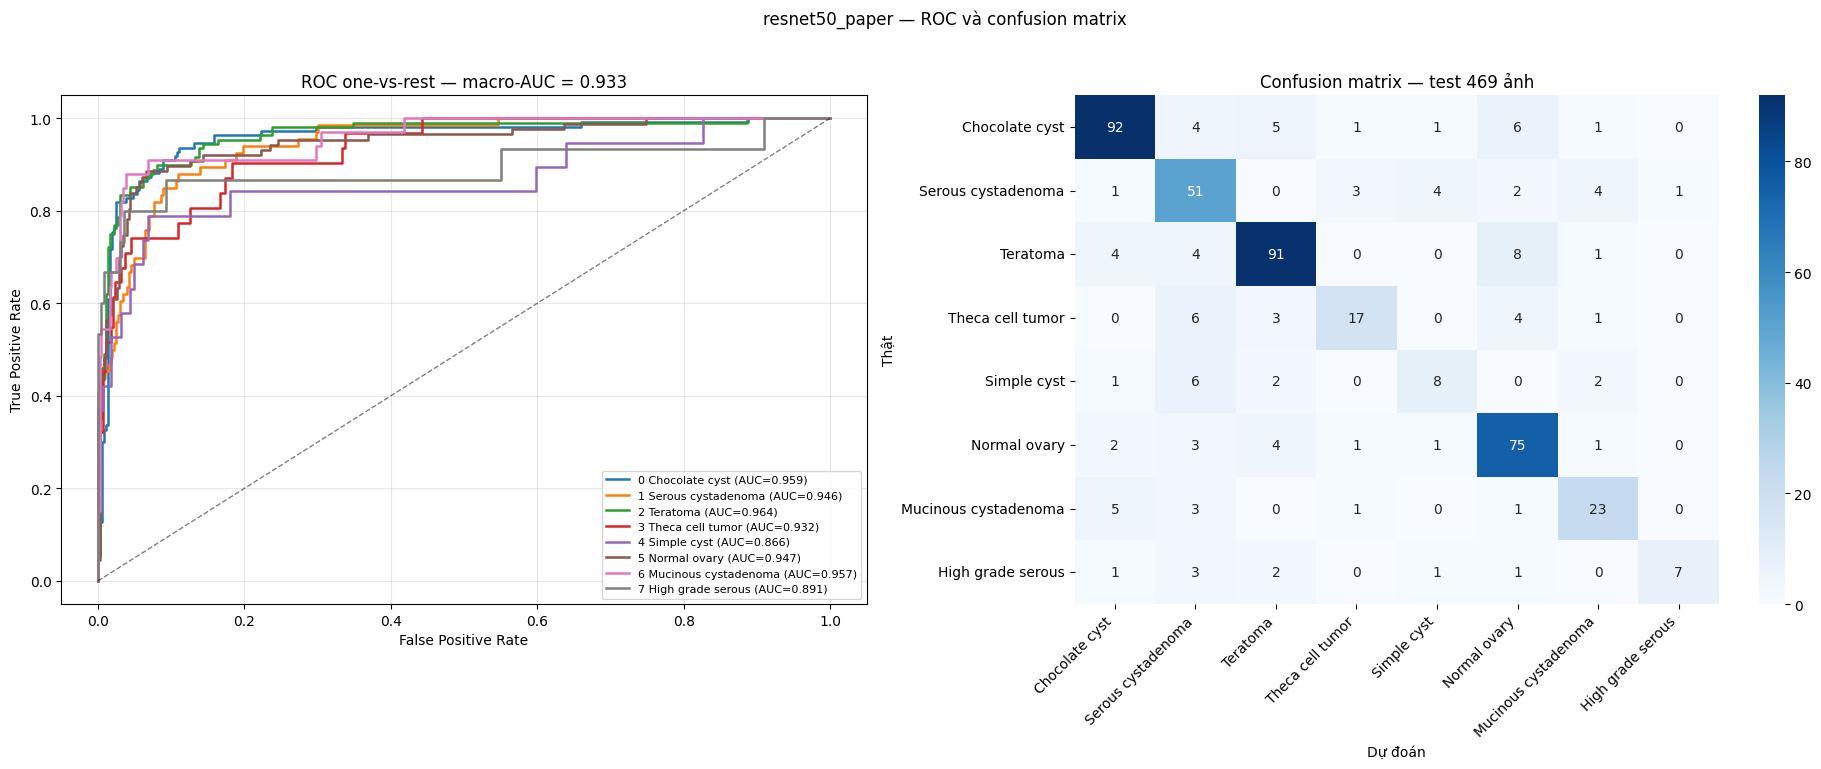


Hiệu năng theo lớp (nhiều mẫu 0,1,2,5 vs ít mẫu 3,4,6,7):
 label           class_name  n_test  recall   auc nhom_so_mau
     0       Chocolate cyst     110   0.836 0.959   nhiều mẫu
     1   Serous cystadenoma      66   0.773 0.946   nhiều mẫu
     2             Teratoma     108   0.843 0.964   nhiều mẫu
     3     Theca cell tumor      31   0.548 0.932      ít mẫu
     4          Simple cyst      19   0.421 0.866      ít mẫu
     5         Normal ovary      87   0.862 0.947   nhiều mẫu
     6 Mucinous cystadenoma      33   0.697 0.957      ít mẫu
     7    High grade serous      15   0.467 0.891      ít mẫu

Recall trung bình — lớp nhiều mẫu (0,1,2,5): 0.828
Recall trung bình — lớp ít mẫu   (3,4,6,7): 0.533

Bảng kết quả:
                                             0
name                            resnet50_paper
backbone                              resnet50
pooling                                    gap
split                              split_paper
n_train                        

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import auc, roc_curve
from sklearn.preprocessing import label_binarize

target_names = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]
rec = experiment_runs["resnet50_paper"]
cfg = rec["cfg"]
name = cfg["name"]

# ---- Chấm test đúng MỘT lần ------------------------------------------------
model = build_resnet50().to(device)
ckpt = load_checkpoint(model, rec["ckpt"])
print(f"Nạp checkpoint {rec['ckpt'].name} (epoch {ckpt.get('epoch', '?')})")

# Tạo lại loader từ class hiện tại (đừng dùng rec['loaders'] lúc train — có thể là transform cũ).
loaders, _ = make_loaders(
    batch_size=cfg.get("batch_size", BATCH_SIZE),
    seed=cfg.get("seed", SEED),
)
x0, _ = loaders["test"].dataset[0]
print(f"Test tensor: {tuple(x0.shape)}  (mmotu.py: letterbox 448, không center crop)")
logits, y_true = collect_logits(model, loaders["test"])
m = metrics_from_logits(logits, y_true)

print("\n" + "=" * 72)
print(f"{name} — TEST {len(y_true)} ảnh (official val_cls.txt, 76 bệnh nhân)")
print("=" * 72)
print(f"  top-1 accuracy : {m['acc']:.4f}")
print(f"  top-2 accuracy : {m['top2_acc']:.4f}")
print(f"  macro-F1       : {m['macro_f1']:.4f}")
print(f"  weighted-F1    : {m['weighted_f1']:.4f}")
print(f"  macro-AUC      : {m['macro_auc']:.4f}")
print()
print(classification_report(
    m["y_true"], m["y_pred"], labels=list(range(NUM_CLASSES)),
    target_names=target_names, digits=3, zero_division=0,
))

# ---- Đường cong huấn luyện (không có val — xem mục 3.1) -------------------
hist = rec["history"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(hist["epoch"], hist["train_loss"], color="tab:blue")
axes[0].set_title("Train loss")
axes[0].set_xlabel("epoch")
axes[1].plot(hist["epoch"], hist["train_acc"], label="accuracy")
axes[1].plot(hist["epoch"], hist["train_macro_f1"], label="macro-F1")
axes[1].axhline(m["acc"], color="tab:red", ls="--", label=f"test top-1 = {m['acc']:.3f}")
axes[1].set_title("Train metrics (đo trên chính tập train)")
axes[1].set_xlabel("epoch")
axes[1].legend(fontsize=8)
axes[2].plot(hist["epoch"], hist["lr"], color="tab:green")
axes[2].set_title(f"Learning rate — poly power {cfg.get('poly_power', POLY_POWER)}")
axes[2].set_xlabel("epoch")
for ax in axes:
    ax.grid(alpha=0.3)
plt.suptitle(f"{name} — không có đường val vì split_paper chỉ có train/test")
plt.tight_layout()
fig.savefig(RUNS_DIR / f"curves_{name}.png", dpi=120)
plt.show()

# ---- ROC one-vs-rest + confusion matrix ----------------------------------
y_bin = label_binarize(m["y_true"], classes=list(range(NUM_CLASSES)))
fig, axes = plt.subplots(1, 2, figsize=(19, 7.5))

auc_per_class = {}
for k in range(NUM_CLASSES):
    if y_bin[:, k].sum() == 0:
        auc_per_class[k] = float("nan")
        continue
    fpr, tpr, _ = roc_curve(y_bin[:, k], m["probs"][:, k])
    auc_k = float(auc(fpr, tpr))
    auc_per_class[k] = auc_k
    axes[0].plot(fpr, tpr, lw=1.8, label=f"{k} {target_names[k]} (AUC={auc_k:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title(f"ROC one-vs-rest — macro-AUC = {m['macro_auc']:.3f}")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].grid(alpha=0.3)

cm = confusion_matrix(m["y_true"], m["y_pred"], labels=list(range(NUM_CLASSES)))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
    xticklabels=target_names, yticklabels=target_names,
)
axes[1].set_xlabel("Dự đoán")
axes[1].set_ylabel("Thật")
axes[1].set_title(f"Confusion matrix — test {len(y_true)} ảnh")
axes[1].tick_params(axis="x", rotation=45)
for lbl in axes[1].get_xticklabels():
    lbl.set_ha("right")
plt.suptitle(f"{name} — ROC và confusion matrix", y=1.02)
plt.tight_layout()
fig.savefig(RUNS_DIR / f"roc_cm_{name}.png", dpi=120)
plt.show()

# ---- Bảng theo lớp: nhóm nhiều mẫu vs ít mẫu ------------------------------
support = cm.sum(axis=1)
per_class = pd.DataFrame({
    "label": range(NUM_CLASSES),
    "class_name": target_names,
    "n_test": support,
    "recall": np.divide(cm.diagonal(), np.clip(support, 1, None)),
    "auc": [auc_per_class[k] for k in range(NUM_CLASSES)],
    "nhom_so_mau": ["nhiều mẫu" if k in (0, 1, 2, 5) else "ít mẫu" for k in range(NUM_CLASSES)],
})
print("\nHiệu năng theo lớp (nhiều mẫu 0,1,2,5 vs ít mẫu 3,4,6,7):")
print(per_class.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("\nRecall trung bình — lớp nhiều mẫu (0,1,2,5): "
      f"{per_class.loc[per_class['nhom_so_mau'] == 'nhiều mẫu', 'recall'].mean():.3f}")
print("Recall trung bình — lớp ít mẫu   (3,4,6,7): "
      f"{per_class.loc[per_class['nhom_so_mau'] == 'ít mẫu', 'recall'].mean():.3f}")
per_class.to_csv(RUNS_DIR / f"per_class_{name}.csv", index=False)

# ---- Bảng kết quả một dòng ------------------------------------------------
p_macro, r_macro, _, _ = precision_recall_fscore_support(
    m["y_true"], m["y_pred"], average="macro", zero_division=0,
)
results_resnet50 = pd.DataFrame([{
    "name": name,
    "backbone": "resnet50",
    "pooling": "gap",
    "split": PRIMARY_SPLIT,
    "n_train": int(len(rec["meta"]["parts"]["train"])),
    "n_test": int(len(rec["meta"]["parts"]["test"])),
    "optimizer": f"SGD lr={cfg['lr']} mom={cfg['momentum']} wd={cfg['weight_decay']}",
    "scheduler": f"poly power={cfg['poly_power']}",
    "epochs": int(rec["n_epochs"]),
    "accuracy": m["acc"],
    "top2_acc": m["top2_acc"],
    "macro_f1": m["macro_f1"],
    "weighted_f1": m["weighted_f1"],
    "macro_auc": m["macro_auc"],
    "precision_macro": p_macro,
    "recall_macro": r_macro,
    "checkpoint": str(rec["ckpt"]),
}])
results_path = RUNS_DIR / "results_resnet50.csv"
results_resnet50.to_csv(results_path, index=False)
print("\nBảng kết quả:")
print(results_resnet50.drop(columns=["checkpoint"]).T.to_string())
print("\nĐã lưu", results_path)

rec["test_metrics"] = m
rec["per_class"] = per_class

# ---- Đặt cạnh baseline đặc trưng thủ công (mục 3.5) -----------------------
if "results_handcrafted" in globals():
    cmp_tbl = pd.DataFrame([
        {"mô hình": "LogReg — 13 đặc trưng intensity (mục 3.5)",
         "top1": float(results_handcrafted["accuracy"].iloc[0]),
         "top2": float(results_handcrafted["top2_acc"].iloc[0]),
         "macro_f1": float(results_handcrafted["macro_f1"].iloc[0])},
        {"mô hình": "ResNet-50 — học đặc trưng từ ảnh (mục 5)",
         "top1": m["acc"], "top2": m["top2_acc"], "macro_f1": m["macro_f1"]},
    ])
    print("\nSo sánh trên cùng test 469 ảnh:")
    print(cmp_tbl.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    cmp_tbl.to_csv(RUNS_DIR / "results_comparison.csv", index=False)


## 5.5 Nhận xét

Dùng các output của các file `runs/results_resnet50.csv`, `runs/per_class_resnet50_paper.csv` và `runs/results_comparison.csv`.

# So sánh các metric

- **Lớp nhiều mẫu (0, 1, 2, 5):** recall trung bình là `0.828` so với **lớp ít mẫu (3, 4, 6, 7):** recall trung bình là `0.533`. Nguyên nhân dẫn đến giá trị macro-F1 `0.702` < weighted-F1 `0.773` với:
  - macro-F1 là tính trung bình đều cho 8 lớp giá trị F1, mỗi lớp được coi quan trọng như nhau. 
  - weighted-F1 tính trung bình có trọng số theo số mẫu thật của từng lớp, nên lớp càng đông càng ảnh hưởng nhiều. 
  > Cho thấy mô hình thiên vị các lớp có nhiều mẫu với tỷ lệ dự đoán cao hơn nhưng tỷ lệ chênh lệch ít và accuracy = `0.776` (tỷ lệ chính xác khi dự đoán) gần với weighted-F1 có nghĩa là mô hình đánh giá các lớp ít mẫu tốt hơn thực tế.
- **Theo biểu đồ ROC và Confusion matrix:** 
  - Xét TH ác tính High grade serous: Có `precision 0.875` nhưng `recall 0.467`cho thấy mô hình chỉ gán nhãn ác tính đúng cho 7 ca và bỏ sót 8 trên 15 ca ung thư. Độ nhạy (Sensitivity) = 0.467 và dộ đặc hiệu (Specificity) là 0.9978 cho thấy mô hình rất "dè dặt" khi dự đoán ác tính. Khi dự đoán ác tình thì gần như đúng (precision 7/8), nhưng bỏ sót hơn một nửa. Trong y tế, đây là sự đánh đổi sai hướng, vì bỏ sót ung thư nguy hiểm hơn nhiều so với báo động nhầm.
  - 2 lớp **Serous cystadenoma và Normal ovary** thường bị các lớp khác dự đoán nhầm. Serous cystadenoma được mô hình dự đoán *80* lần trong khi thực tế chỉ có *66* mẫu và Normal ovary được dự đoán *97* lần so với *87* mẫu thật
    - High grade serous (3) bị nhầm thành Serous cystadenoma do cả 2 cùng thuộc dòng u thanh dịch.
    - Teratoma (8) và Chocolate cyst (6) bị nhầm thành Normal ovary. Đây là kiểu nhầm đáng lo trong lâm sàng, vì nó nghĩa là có tổn thương nhưng bị bảo là bình thường.
- **ResNet-50 vs đặc trưng thủ công:** top-1 `0.7761` so với `0.2537` của LogReg trên 13 cột intensity. Khoảng cách này là bằng chứng định lượng cho nhận xét ở mục 2.9: đặc trưng thủ công toàn cục không tách được 8 lớp, phải để CNN tự học đặc trưng.
- **Overfitting:** không có đường val để đo trực tiếp, nên đánh giá gián tiếp qua khoảng cách train–test. Kết luận: **mô hình overfit rõ rệt**.
  - 5 epoch cuối (56–60): `train_acc` 0.979–0.992, `train_loss` 0.037–0.061. Mô hình gần như thuộc lòng tập train.
  - Test top-1 = 0.7761, thấp hơn `train_acc` epoch 60 (0.992) **21.6 điểm**. Với macro-F1 khoảng cách còn lớn hơn: 0.993 (train) so với 0.702 (test) - 29 điểm, vì các lớp ít mẫu tổng quát hoá kém nhất.
  - `train_acc` đo trên ảnh đã augment (random resize + crop + flip), vốn khó hơn ảnh gốc, nên khoảng cách thật có thể còn lớn hơn 21.6 điểm.
  - Train loss đã xuống dưới 0.1 từ khoảng epoch 40 và `train_acc` gần như đi ngang từ đó. Nửa cuối quá trình train chủ yếu làm mô hình khớp chặt hơn với tập train chứ không cải thiện khả năng tổng quát.
  - Nguyên nhân: khoảng 23.5M tham số được fine-tune toàn bộ trên chỉ 1000 ảnh, không dropout, không label smoothing, augment nhẹ. Hướng giảm: label smoothing, dropout trước `fc`, augment mạnh hơn, hoặc giảm số epoch (chọn bằng k-fold trên tập train).

**Kết luận 5.3–5.4:** ResNet-50 fine-tune toàn mạng bằng SGD + poly LR trên 1000 ảnh raw vượt xa baseline intensity thủ công.

# 6. Kết luận

Điền số liệu từ `runs/results_resnet50.csv`, `runs/per_class_resnet50_paper.csv`, `runs/results_comparison.csv`.

## Kết quả chính

- **Giao thức:** train 1000 ảnh, test 469 ảnh patient-disjoint, ảnh raw RGB, ResNet-50 ImageNet fine-tune toàn mạng, SGD 0.01 + momentum 0.9 + weight decay 5e-4, poly LR power 0.9, 60 epoch cố định, cross-entropy thuần.
- **Kết quả:** top-1 `0.7761` và top-2 `0.8891`.
- **Baseline đối chiếu:** `LogisticRegression` trên 13 đặc trưng cường độ đạt top-1 `0.2537` — khoảng cách với ResNet-50 cho thấy giá trị của việc để mạng tự học đặc trưng thay vì thiết kế tay.

## Lớp còn nhầm

Bốn lớp ít mẫu — Theca cell tumor (3), Simple cyst (4), Mucinous cystadenoma (6), High grade serous (7) — có recall thấp hơn nhóm 0, 1, 2, 5. Nguyên nhân chính là số mẫu train chênh lệch. Số liệu cụ thể ở `per_class_resnet50_paper.csv`.

## Hạn chế

- **Không có tập validation.** Hệ quả của việc bám đúng split bài báo: số epoch (60) và mọi siêu tham số phải chốt trước, không có cách kiểm chứng chúng là lựa chọn tốt nhất mà không đụng vào test. Bài báo không công bố các siêu tham số cũng như các biểu đồ khi train, khiến việc so sánh trở nên khó khăn. Kết quả **Resnet-50 theo bài báo** là `top-1 = 0.8017` so với kết quả `top-1 = 0.776` tỷ lệ chênh lệch là `0.0257`
- **Bài báo không công bố đủ chi tiết** cho Task 3: không có số epoch, batch size, hay cấu hình augment chính xác. Phần này nhóm phải tự chốt.
- **Mô hình bị overfitting:** được ghi ở mục 5.5 cho thấy mô hình tái tạo thực hiện bị overfitting. **Nhưng** không đánh giá mô hình của bài báo là overfitting do thiếu các số liệu quan trọng.
- Không có `patient_id` công khai nên không thể tự chia lại theo bệnh nhân; chỉ biên train/test gốc là patient-disjoint.
- Tập nhỏ (1469 ảnh), 8 lớp lệch, lớp 7 rất ít mẫu. Chỉ siêu âm 2D.
- Chỉ một seed, chưa đo được phương sai giữa các lần chạy.

## Hướng phát triển

Các đề xuất dưới đây xếp theo mức độ nhắm đúng vào hạn chế đã phát hiện ở mục 5.4–5.5:

| # | Vấn đề | Giải pháp | Lý do cụ thể |
| --- | --- | --- | --- |
| 1 | Recall lớp hiếm thấp dù AUC cao | **Logit adjustment** lúc suy luận: $\hat{y} = \arg\max_k (z_k - \tau \log \pi_k)$, với $\pi_k$ là tỉ lệ lớp $k$ trong tập train và $\tau = 1$ | Lỗi nằm ở bước quyết định: mô hình học prior nghiêng về lớp nhiều mẫu. Không cần train lại, không cần tập val ($\tau = 1$ chốt theo lý thuyết, không dò trên test) |
| 2 | Mất cân bằng lớp khi train | Cross-entropy có trọng số lớp, `WeightedRandomSampler`, focal loss hoặc logit-adjusted loss | Tăng tín hiệu gradient cho lớp 3, 4, 6, 7 |
| 3 | Overfitting (train 0.992, test 0.776) | Label smoothing 0.1, dropout trước `fc`, thêm augment xoay ±15° và thay đổi độ sáng/tương phản nhẹ, hoặc giảm số epoch | Train loss dưới 0.1 từ khoảng epoch 40 |

**Dự đoán:** các đề xuất trên có thể làm giảm accuracy, weight-F1 nhưng bù lại giá trị của marco-F1 có thể tăng với recall tăng do tín hiệu của các lớp ít mẫu được tăng.

**Hướng mở rộng dài hạn:**

- Nếu xin được `patient_id`: chia lại theo nhóm bệnh nhân để có val hợp lệ, từ đó dò được số epoch và siêu tham số mà không rò rỉ.
- Thử thêm các backbone khác (VGG-16, DenseNet-121, EfficientNet).
- Học đa nhiệm (segmentation + recognition) đúng hướng bài báo, thay vì phụ thuộc mask có sẵn.
